# Fase 2: Modelado No Supervisado

* Clustering de escala productiva
* Clustering de caracterización de dinámica temporal

In [ ]:
import matplotlib.pyplot as plt
import os

# ── Carpeta de salida ─────────────────────────────────────────────────────────
OUT_DIR = "figures_clustering"
os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(name):
    """Guarda la figura activa en figures_clustering/ como PDF vectorial 600 dpi."""
    plt.savefig(os.path.join(OUT_DIR, f"{name}.pdf"),
                format="pdf", dpi=600, bbox_inches="tight")

: 

## Escala de referencia (Cuartiles)

In [14]:
# Determinar escala productiva por cuartiles (referencia base antes de clustering)

import pandas as pd
import os

# ------------------------------------------------------------------------------
# 1. Cargar dataset de features
# ------------------------------------------------------------------------------

features_file = os.path.join("data", "transitorios_deptos_15_final_features.csv")
df_features = pd.read_csv(features_file, encoding="utf-8-sig")

print("Dataset de features cargado:")
print(f"  Archivo: {features_file}")
print(f"  Pares (filas): {len(df_features):,}")
print()

# ------------------------------------------------------------------------------
# 2. Calcular cuartiles de producción total por par
# ------------------------------------------------------------------------------

# Cuartiles de la distribución de produccion_promedio
quartiles = df_features["produccion_promedio"].quantile([0.25, 0.50, 0.75])

q1 = quartiles.loc[0.25]
q2 = quartiles.loc[0.50]
q3 = quartiles.loc[0.75]

print("Cuartiles de producción promedio por par:")
print(f"  Q1 (25%): {q1:,.2f}")
print(f"  Q2 (50% - mediana): {q2:,.2f}")
print(f"  Q3 (75%): {q3:,.2f}")
print()

# ------------------------------------------------------------------------------
# 3. Definir categorías de escala productiva por cuartiles
# ------------------------------------------------------------------------------

# Definimos 4 categorías:
#  - Q1_baja:      produccion_promedio <= Q1
#  - Q2_media-baja: (Q1, Q2]
#  - Q3_media-alta: (Q2, Q3]
#  - Q4_gran_escala: > Q3

bins = [-float("inf"), q1, q2, q3, float("inf")]
labels = ["Q1_baja", "Q2_media-baja", "Q3_media-alta", "Q4_gran_escala"]

df_features["escala_cuartiles_prod"] = pd.cut(
    df_features["produccion_promedio"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Bandera binaria para "gran escala" según cuartil superior (Q4)
df_features["es_gran_escala_cuartil"] = (
    df_features["escala_cuartiles_prod"] == "Q4_gran_escala"
).astype(int)

# ------------------------------------------------------------------------------
# 4. Resumen de la clasificación por cuartiles
# ------------------------------------------------------------------------------

print("Distribución de pares por categoría de escala (cuartiles de producción promedio):")
print(df_features["escala_cuartiles_prod"].value_counts().sort_index())
print()

print("Proporción de pares por categoría (%):")
print((df_features["escala_cuartiles_prod"].value_counts(normalize=True).sort_index() * 100).round(2))
print()

print("Número de pares en 'gran escala' (Q4):")
n_gran_escala = df_features["es_gran_escala_cuartil"].sum()
print(f"  Pares gran escala (Q4): {n_gran_escala} ({n_gran_escala / len(df_features) * 100:.2f} %)")
print()

# ------------------------------------------------------------------------------
# 5. Guardar dataset actualizado con escala por cuartiles
# ------------------------------------------------------------------------------

output_file = os.path.join("data", "transitorios_deptos_15_final_features_cuartiles.csv")
df_features.to_csv(output_file, index=False, encoding="utf-8-sig")

print("Archivo con clasificación por cuartiles guardado:")
print(f"  {output_file}")


Dataset de features cargado:
  Archivo: data\transitorios_deptos_15_final_features.csv
  Pares (filas): 490

Cuartiles de producción promedio por par:
  Q1 (25%): 139.86
  Q2 (50% - mediana): 776.47
  Q3 (75%): 4,056.90

Distribución de pares por categoría de escala (cuartiles de producción promedio):
escala_cuartiles_prod
Q1_baja           123
Q2_media-baja     122
Q3_media-alta     122
Q4_gran_escala    123
Name: count, dtype: int64

Proporción de pares por categoría (%):
escala_cuartiles_prod
Q1_baja           25.1
Q2_media-baja     24.9
Q3_media-alta     24.9
Q4_gran_escala    25.1
Name: proportion, dtype: float64

Número de pares en 'gran escala' (Q4):
  Pares gran escala (Q4): 123 (25.10 %)

Archivo con clasificación por cuartiles guardado:
  data\transitorios_deptos_15_final_features_cuartiles.csv


## Clustering de escala productiva

En este notebook se encuentra la implementación del Clustering final para escala productiva. Ejercicios de comparación entre cantidad de configuraciones, estandarización o transformación de features fueron realizados en pruebas de concepto/exploración previamente hasta llegar a este modelado. Por esta razón, no se encuentran documentados ni codificados aquí. Esto permite tener el notebook limpio para fines del proyecto de investigación en cuestión. En caso de querer replicarse, estudiarse y/o analizarse, tener en cuenta el documento final o artículo investigativo, donde se indica lo realizado.

In [15]:
# ==============================================================================
# CLUSTERING CON 5 FEATURES - SIN TRANSFORMACIÓN
# ==============================================================================

import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ------------------------------------------------------------------------------
# 1. Cargar datos
# ------------------------------------------------------------------------------

features_file = os.path.join("data", "transitorios_deptos_15_final_features_cuartiles.csv")
df_features = pd.read_csv(features_file, encoding="utf-8-sig")

print("CLUSTERING CON 5 FEATURES - SIN TRANSFORMACIÓN")
print("=" * 80)
print(f"Pares totales: {len(df_features):,}\n")

# ------------------------------------------------------------------------------
# 2. Seleccionar features
# ------------------------------------------------------------------------------

features_escala = [
    "produccion_promedio",      # magnitud productiva
    "area_sembrada_promedio",   # escala física
    "n_periodos",               # persistencia/solidez temporal
    "hhi_tiempo_produccion",    # concentración temporal
    "hhi_espacial_cultivo",     # concentración espacial
]

print("Features seleccionadas:")
for i, f in enumerate(features_escala, 1):
    print(f"  {i}. {f}")

X = df_features[features_escala].values

print(f"\nDimensiones: {X.shape[0]} pares × {X.shape[1]} features")

# ------------------------------------------------------------------------------
# 3. Estadísticas descriptivas
# ------------------------------------------------------------------------------

print("\n\nESTADÍSTICAS DESCRIPTIVAS")
print("-" * 80)
print(df_features[features_escala].describe().round(2))

CLUSTERING CON 5 FEATURES - SIN TRANSFORMACIÓN
Pares totales: 490

Features seleccionadas:
  1. produccion_promedio
  2. area_sembrada_promedio
  3. n_periodos
  4. hhi_tiempo_produccion
  5. hhi_espacial_cultivo

Dimensiones: 490 pares × 5 features


ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------
       produccion_promedio  area_sembrada_promedio  n_periodos  \
count               490.00                  490.00      490.00   
mean              10990.11                 1817.75       30.77   
std               49685.45                 6361.05        6.18   
min                   1.43                    0.83       15.00   
25%                 139.86                   21.42       27.25   
50%                 776.47                  109.93       35.00   
75%                4056.90                  584.32       35.00   
max              709922.83                75772.73       35.00   

       hhi_tiempo_produccion  hhi_espacial_cul

BÚSQUEDA DE NÚMERO DE CLUSTERS (K)
k = 2: Inercia = 2.67e+11, Silhouette = 0.9684
k = 3: Inercia = 1.53e+11, Silhouette = 0.8879
k = 4: Inercia = 6.53e+10, Silhouette = 0.8882
k = 5: Inercia = 3.59e+10, Silhouette = 0.8739
k = 6: Inercia = 2.56e+10, Silhouette = 0.8573
k = 7: Inercia = 1.96e+10, Silhouette = 0.8463
k = 8: Inercia = 1.46e+10, Silhouette = 0.8422
k = 9: Inercia = 1.09e+10, Silhouette = 0.7509
k = 10: Inercia = 8.99e+09, Silhouette = 0.7333

RESUMEN - Top 3 por Silhouette:
  1. k = 2: 0.9684
  2. k = 4: 0.8882
  3. k = 3: 0.8879


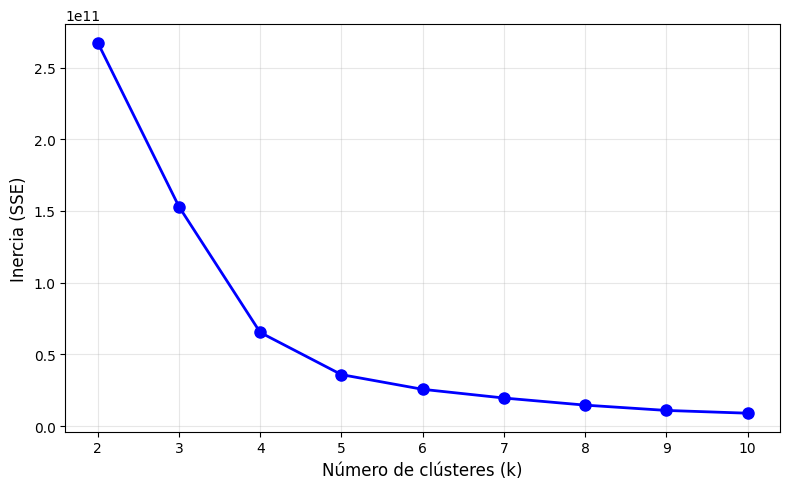

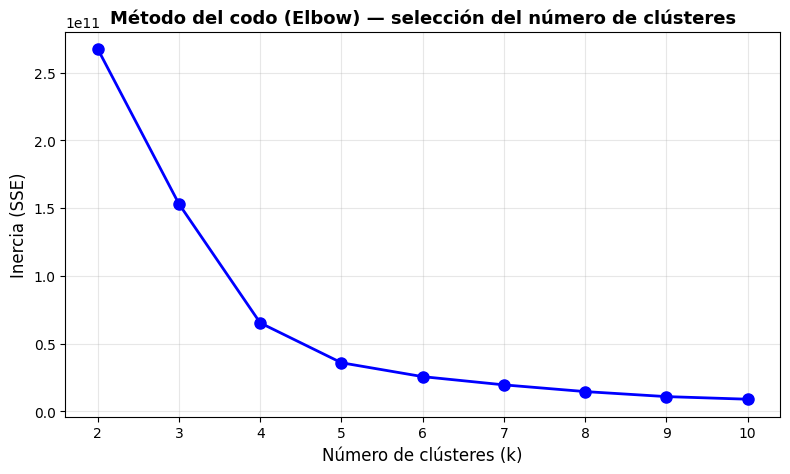

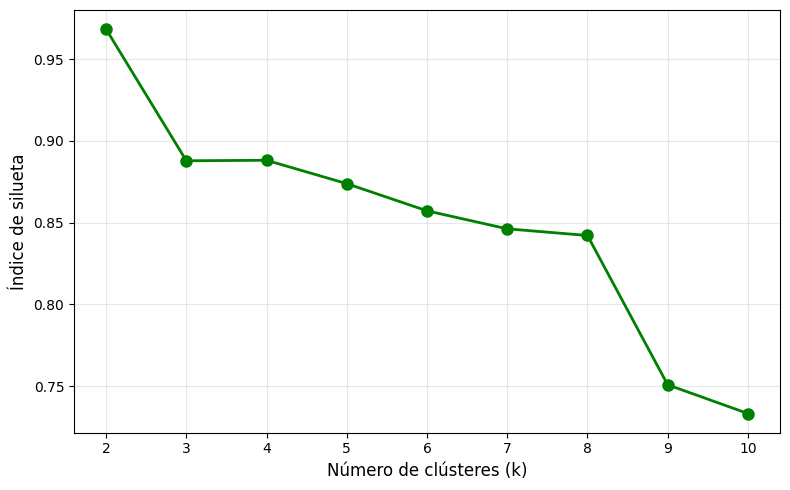

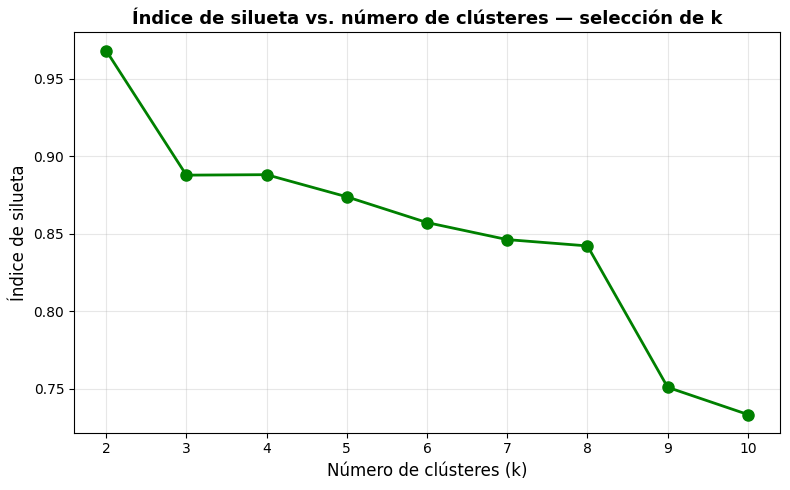

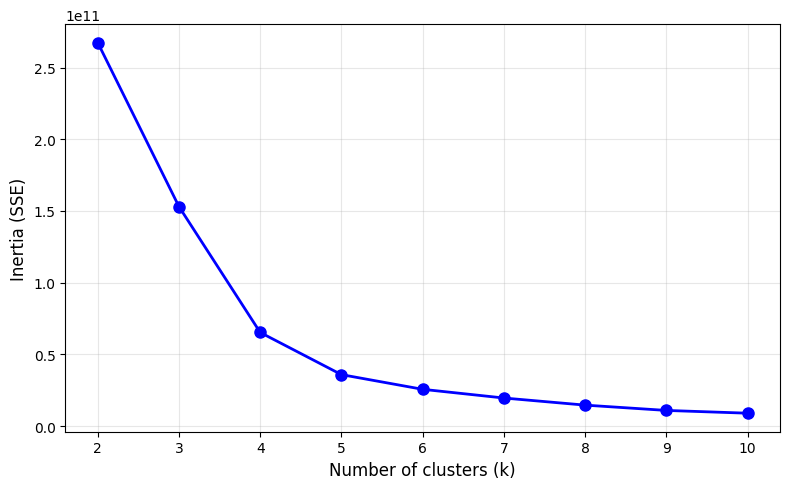

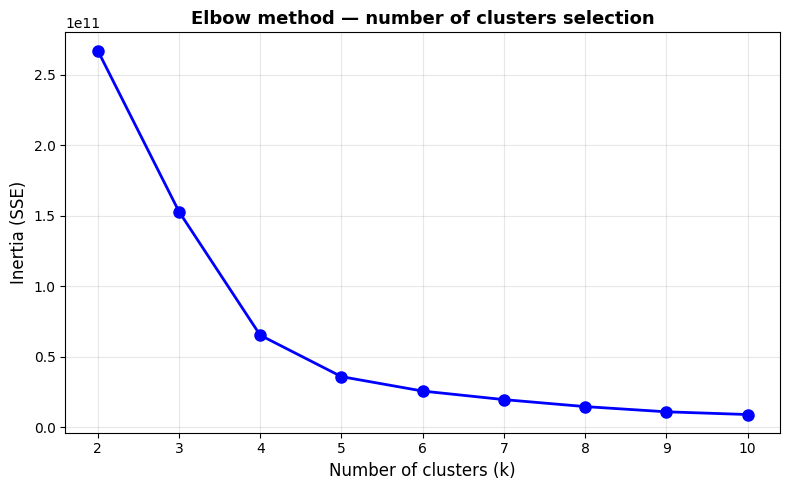

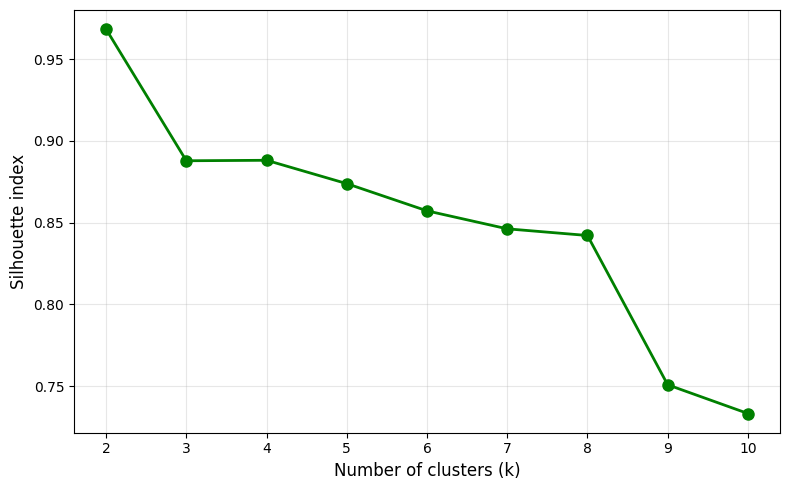

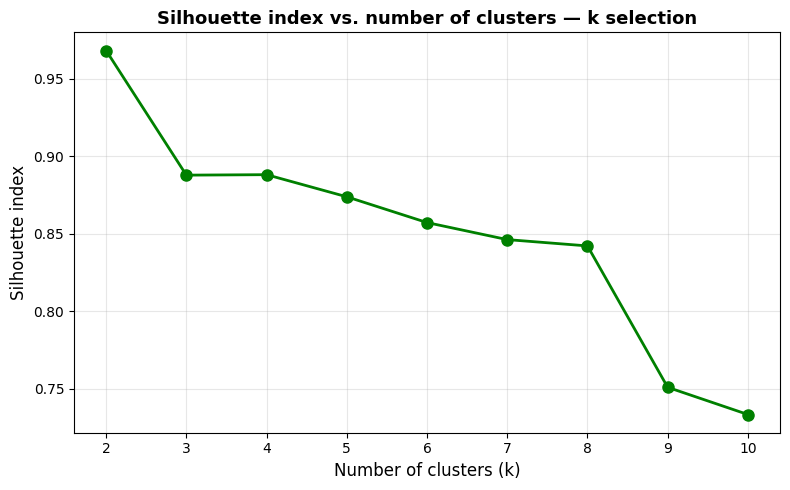

✓ 8 figuras guardadas en 'figures_clustering/'
  codo_elbow_k_es.pdf / codo_elbow_k_title_es.pdf
  silhouette_k_en.pdf  / silhouette_k_title_en.pdf  ...


In [16]:
# ==============================================================================
# BÚSQUEDA DE K ÓPTIMO - CODO Y SILHOUETTE
# ==============================================================================

print("BÚSQUEDA DE NÚMERO DE CLUSTERS (K)")
print("=" * 80)

k_range    = range(2, 11)
inertias   = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    sil = silhouette_score(X, kmeans.labels_)
    silhouettes.append(sil)
    print(f"k = {k}: Inercia = {kmeans.inertia_:.2e}, Silhouette = {sil:.4f}")

print("\n" + "=" * 80)
print("RESUMEN - Top 3 por Silhouette:")
ranking = sorted(zip(k_range, silhouettes), key=lambda x: x[1], reverse=True)[:3]
for i, (k, s) in enumerate(ranking, 1):
    print(f"  {i}. k = {k}: {s:.4f}")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS_CODO = {
    'es': {
        'xlabel': 'Número de clústeres (k)',
        'ylabel': 'Inercia (SSE)',
        'title':  'Método del codo (Elbow) — selección del número de clústeres',
    },
    'en': {
        'xlabel': 'Number of clusters (k)',
        'ylabel': 'Inertia (SSE)',
        'title':  'Elbow method — number of clusters selection',
    },
}

LABELS_SIL = {
    'es': {
        'xlabel': 'Número de clústeres (k)',
        'ylabel': 'Índice de silueta',
        'title':  'Índice de silueta vs. número de clústeres — selección de k',
    },
    'en': {
        'xlabel': 'Number of clusters (k)',
        'ylabel': 'Silhouette index',
        'title':  'Silhouette index vs. number of clusters — k selection',
    },
}

BASE_CODO = "codo_elbow_k"
BASE_SIL  = "silhouette_k"

# ── Función figura A: codo ────────────────────────────────────────────────────
def plot_codo(xlabel, ylabel, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(list(k_range))
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Función figura B: silhouette ──────────────────────────────────────────────
def plot_silhouette_k(xlabel, ylabel, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(list(k_range), silhouettes, 'go-', linewidth=2, markersize=8)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(list(k_range))
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Generar las 8 figuras (2 tipos × 2 idiomas × 2 variantes) ────────────────
total = 0
for lang in ['es', 'en']:
    lc = LABELS_CODO[lang]
    ls = LABELS_SIL[lang]

    plot_codo(lc['xlabel'], lc['ylabel'])
    save_fig(f"{BASE_CODO}_{lang}")
    plt.show()

    plot_codo(lc['xlabel'], lc['ylabel'], title=lc['title'])
    save_fig(f"{BASE_CODO}_title_{lang}")
    plt.show()

    plot_silhouette_k(ls['xlabel'], ls['ylabel'])
    save_fig(f"{BASE_SIL}_{lang}")
    plt.show()

    plot_silhouette_k(ls['xlabel'], ls['ylabel'], title=ls['title'])
    save_fig(f"{BASE_SIL}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_CODO}_es.pdf / {BASE_CODO}_title_es.pdf")
print(f"  {BASE_SIL}_en.pdf  / {BASE_SIL}_title_en.pdf  ...")

ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

Varianza explicada por componente:
Componente    Var. explicada  Var. acumulada
---------------------------------------------
PC1                   99.28%          99.28%
PC2                    0.72%         100.00%
PC3                    0.00%         100.00%
PC4                    0.00%         100.00%
PC5                    0.00%         100.00%


LOADINGS (contribución de features a componentes)
--------------------------------------------------------------------------------
                          PC1    PC2    PC3   PC4    PC5
produccion_promedio     0.995 -0.095 -0.000 -0.00  0.000
area_sembrada_promedio  0.095  0.995 -0.000  0.00  0.000
n_periodos              0.000  0.000  1.000  0.01  0.005
hhi_tiempo_produccion  -0.000 -0.000 -0.004 -0.02  1.000
hhi_espacial_cultivo   -0.000 -0.000 -0.011  1.00  0.019

k=3: Silhouette = 0.8879


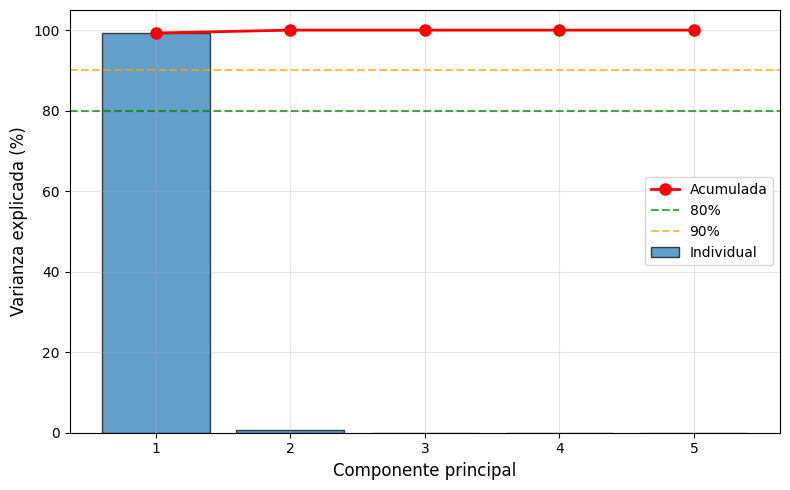

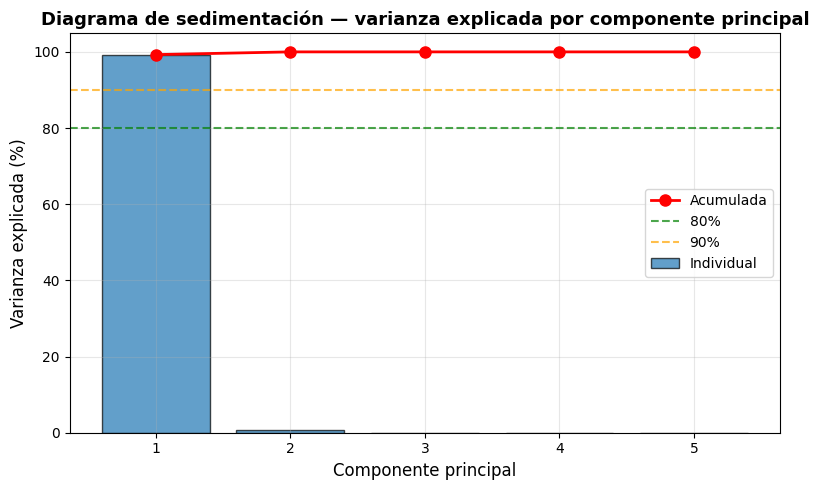

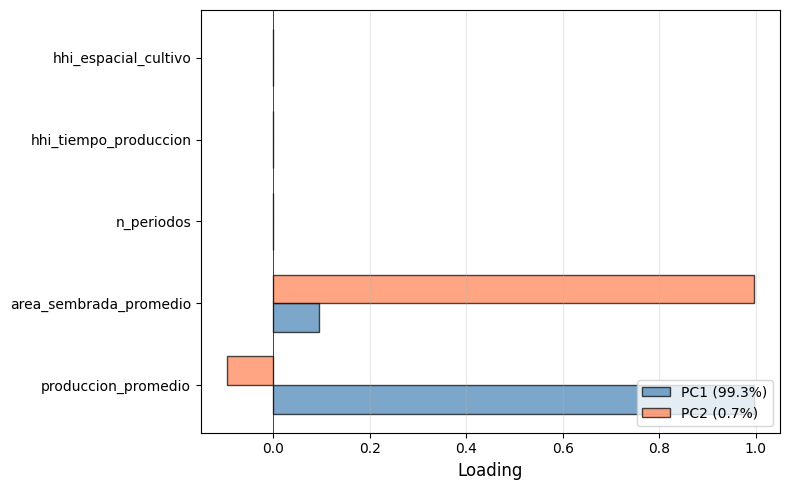

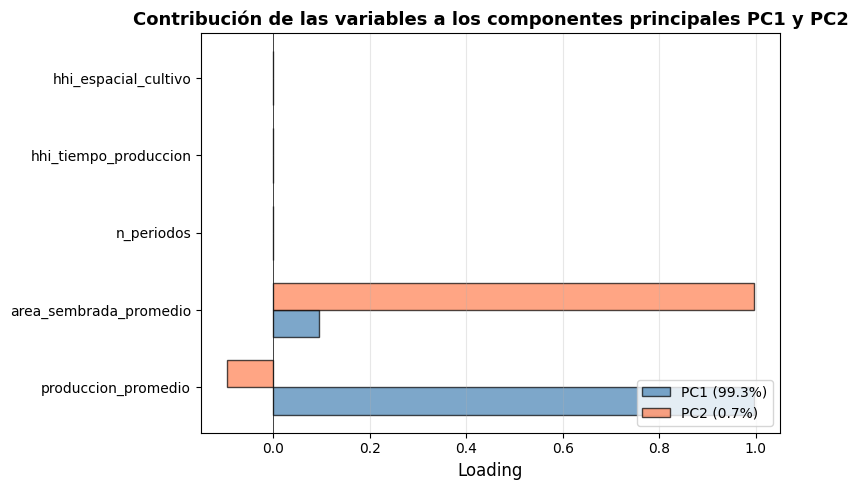

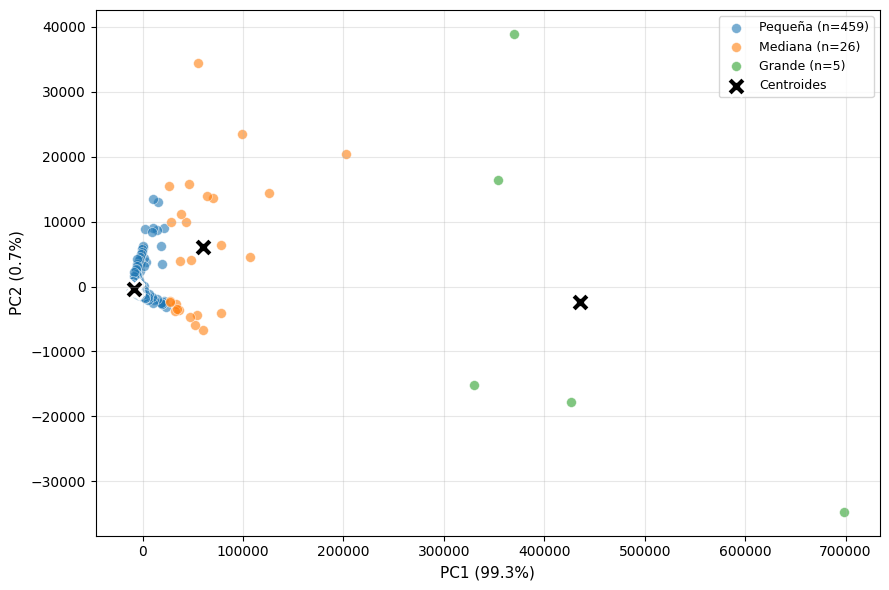

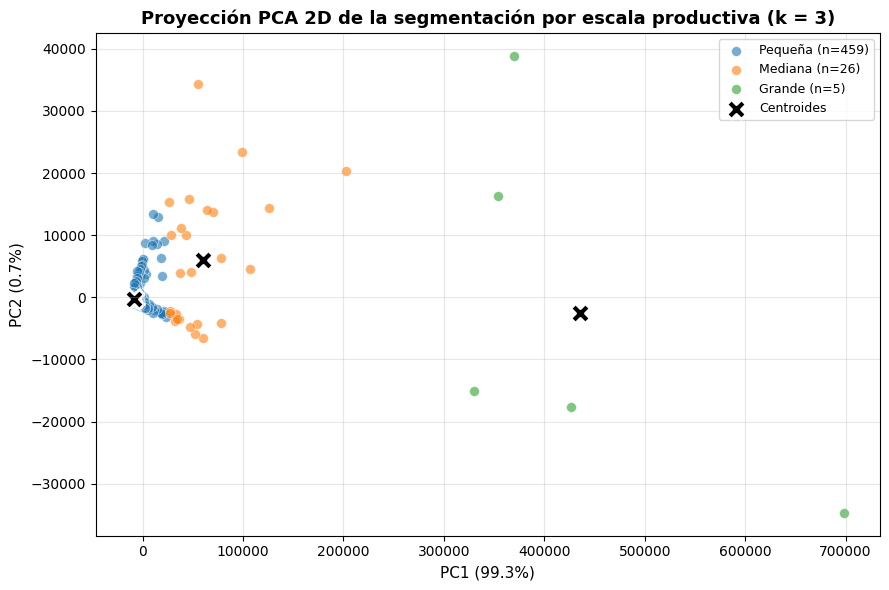

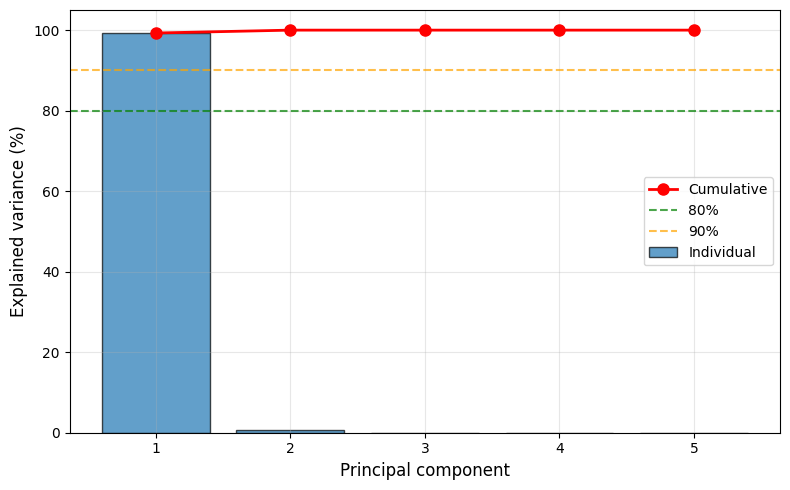

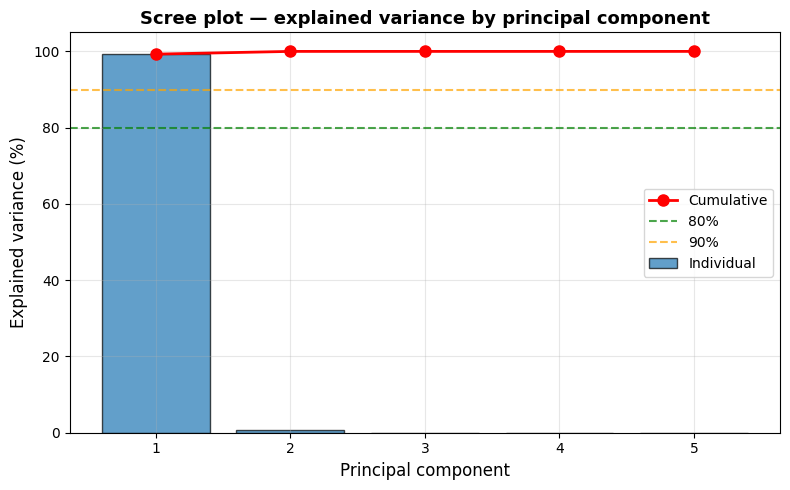

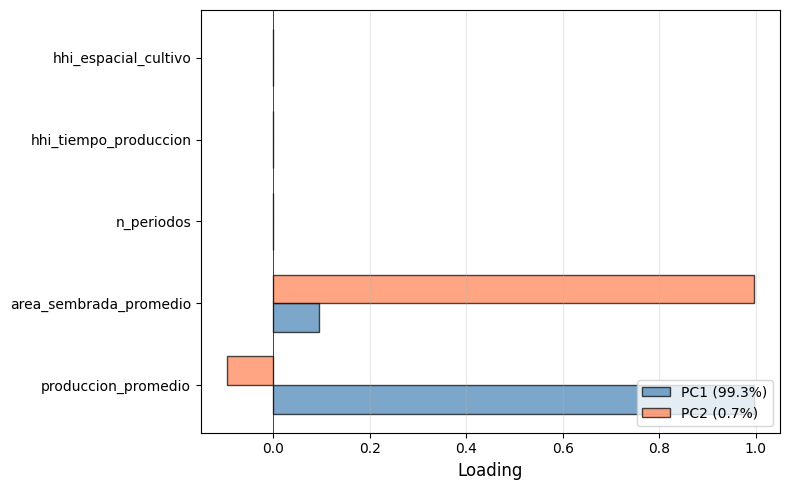

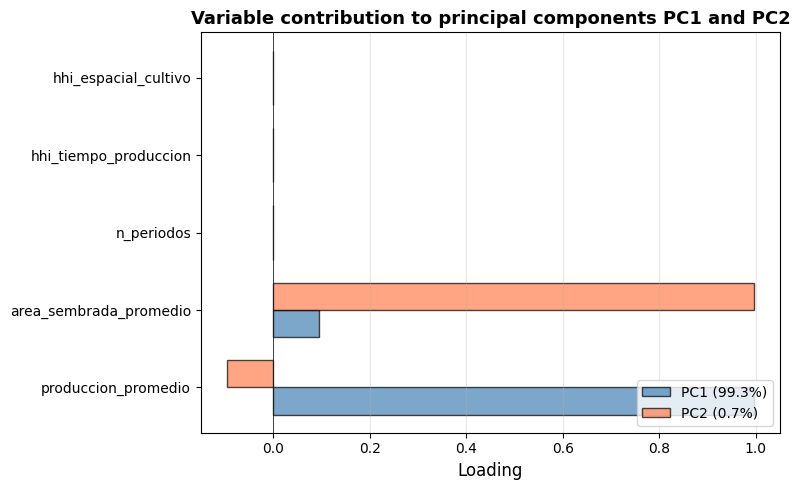

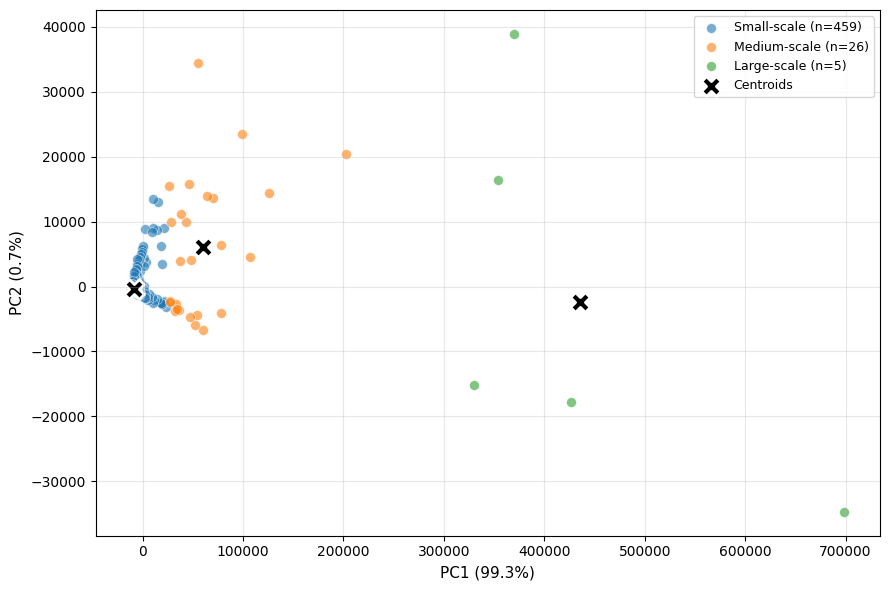

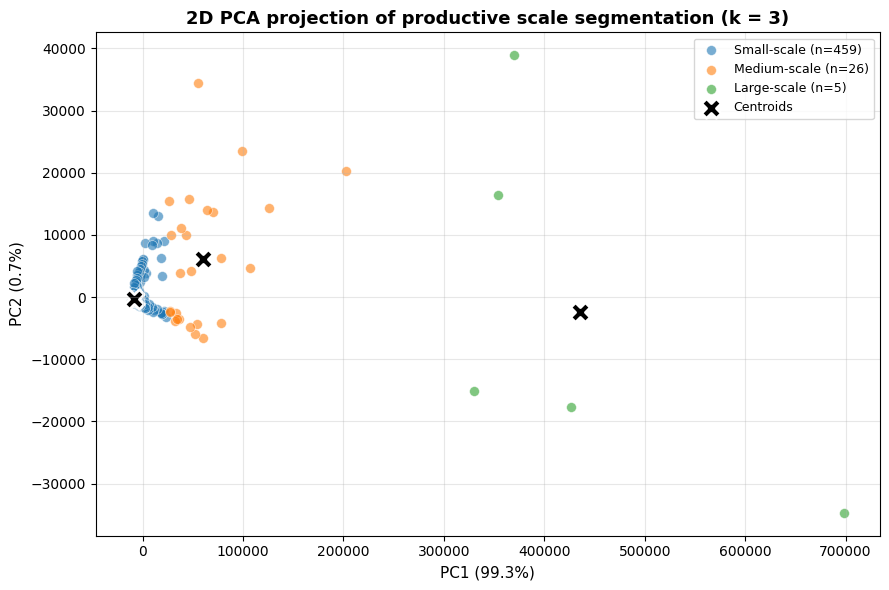

✓ 12 figuras guardadas en 'figures_clustering/'
  pca_scree_plot, pca_loadings_pc1_pc2, pca_2d_k3
  Cada uno con variantes _es, _en, _title_es, _title_en


In [18]:
# ==============================================================================
# PCA Y VISUALIZACIÓN 2D
# ==============================================================================

print("ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)")
print("=" * 80)

pca   = PCA()
X_pca = pca.fit_transform(X)

var_explicada = pca.explained_variance_ratio_
var_acumulada = np.cumsum(var_explicada)

print("\nVarianza explicada por componente:")
print(f"{'Componente':<12} {'Var. explicada':>15} {'Var. acumulada':>15}")
print("-" * 45)
for i, (ve, va) in enumerate(zip(var_explicada, var_acumulada), 1):
    print(f"PC{i:<10} {ve*100:>14.2f}% {va*100:>14.2f}%")

loadings_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(features_escala))],
    index=features_escala
)
print("\n\nLOADINGS (contribución de features a componentes)")
print("-" * 80)
print(loadings_df.round(3))

# ── Preparar datos ────────────────────────────────────────────────────────────
loadings_pc1 = pca.components_[0]
loadings_pc2 = pca.components_[1]
y_pos        = np.arange(len(features_escala))
width        = 0.35
colors_cm    = plt.cm.tab10(np.linspace(0, 1, 10))

km3     = KMeans(n_clusters=3, random_state=42, n_init=10)
labels3 = km3.fit_predict(X)
sil3    = silhouette_score(X, labels3)
orden3  = np.argsort(km3.cluster_centers_[:, 0])
lmap3   = {old: new for new, old in enumerate(orden3)}
l_ord3  = np.array([lmap3[l] for l in labels3])
c_pca3  = pca.transform(km3.cluster_centers_)[orden3]

# Etiquetas por idioma
etiq3 = {
    'es': {0: "Pequeña",     1: "Mediana",       2: "Grande"},
    'en': {0: "Small-scale", 1: "Medium-scale",  2: "Large-scale"},
}

print(f"\nk=3: Silhouette = {sil3:.4f}")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS_SCREE = {
    'es': {
        'xlabel':    'Componente principal',
        'ylabel':    'Varianza explicada (%)',
        'label_ind': 'Individual',
        'label_acum':'Acumulada',
        'title':     'Diagrama de sedimentación — varianza explicada por componente principal',
    },
    'en': {
        'xlabel':    'Principal component',
        'ylabel':    'Explained variance (%)',
        'label_ind': 'Individual',
        'label_acum':'Cumulative',
        'title':     'Scree plot — explained variance by principal component',
    },
}

LABELS_LOAD = {
    'es': {
        'xlabel': 'Loading',
        'title':  'Contribución de las variables a los componentes principales PC1 y PC2',
    },
    'en': {
        'xlabel': 'Loading',
        'title':  'Variable contribution to principal components PC1 and PC2',
    },
}

LABELS_PCA3 = {
    'es': {
        'xlabel_tpl': 'PC1 ({:.1f}%)',
        'ylabel_tpl': 'PC2 ({:.1f}%)',
        'label_cent': 'Centroides',
        'title':      'Proyección PCA 2D de la segmentación por escala productiva (k = 3)',
    },
    'en': {
        'xlabel_tpl': 'PC1 ({:.1f}%)',
        'ylabel_tpl': 'PC2 ({:.1f}%)',
        'label_cent': 'Centroids',
        'title':      '2D PCA projection of productive scale segmentation (k = 3)',
    },
}

BASE_SCREE = "pca_scree_plot"
BASE_LOAD  = "pca_loadings_pc1_pc2"
BASE_PCA3  = "pca_2d_k3"

# ── Función Scree plot ────────────────────────────────────────────────────────
def plot_scree(xlabel, ylabel, label_ind, label_acum, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(range(1, len(var_explicada)+1), var_explicada*100,
           alpha=0.7, edgecolor='black', label=label_ind)
    ax.plot(range(1, len(var_explicada)+1), var_acumulada*100,
            'ro-', linewidth=2, markersize=8, label=label_acum)
    ax.axhline(y=80, color='green',  linestyle='--', alpha=0.7, label='80%')
    ax.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90%')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xticks(range(1, len(var_explicada)+1))
    ax.legend(loc='right')
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Función Loadings ──────────────────────────────────────────────────────────
def plot_loadings(xlabel, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(y_pos - width/2, loadings_pc1, width,
            label=f'PC1 ({var_explicada[0]*100:.1f}%)',
            color='steelblue', edgecolor='black', alpha=0.7)
    ax.barh(y_pos + width/2, loadings_pc2, width,
            label=f'PC2 ({var_explicada[1]*100:.1f}%)',
            color='coral', edgecolor='black', alpha=0.7)
    ax.axvline(x=0, color='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features_escala)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, axis='x')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Función PCA 2D k=3 ────────────────────────────────────────────────────────
def plot_pca2d_k3(xlabel_tpl, ylabel_tpl, label_cent, lang, title=None):
    conteos = [np.sum(l_ord3 == i) for i in range(3)]
    etiq    = etiq3[lang]
    fig, ax = plt.subplots(figsize=(9, 6))
    for i in range(3):
        mask = l_ord3 == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[colors_cm[i]], label=f'{etiq[i]} (n={conteos[i]})',
                   alpha=0.6, edgecolors='w', linewidth=0.5, s=50)
    ax.scatter(c_pca3[:, 0], c_pca3[:, 1],
               c='black', marker='X', s=200,
               edgecolors='white', linewidth=2, label=label_cent)
    ax.set_xlabel(xlabel_tpl.format(var_explicada[0]*100), fontsize=11)
    ax.set_ylabel(ylabel_tpl.format(var_explicada[1]*100), fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Generar las 12 figuras (3 tipos × 2 idiomas × 2 variantes) ───────────────
total = 0
for lang in ['es', 'en']:
    ls = LABELS_SCREE[lang]
    ll = LABELS_LOAD[lang]
    lp = LABELS_PCA3[lang]

    plot_scree(ls['xlabel'], ls['ylabel'], ls['label_ind'], ls['label_acum'])
    save_fig(f"{BASE_SCREE}_{lang}")
    plt.show()
    plot_scree(ls['xlabel'], ls['ylabel'], ls['label_ind'], ls['label_acum'], title=ls['title'])
    save_fig(f"{BASE_SCREE}_title_{lang}")
    plt.show()

    plot_loadings(ll['xlabel'])
    save_fig(f"{BASE_LOAD}_{lang}")
    plt.show()
    plot_loadings(ll['xlabel'], title=ll['title'])
    save_fig(f"{BASE_LOAD}_title_{lang}")
    plt.show()

    plot_pca2d_k3(lp['xlabel_tpl'], lp['ylabel_tpl'], lp['label_cent'], lang)
    save_fig(f"{BASE_PCA3}_{lang}")
    plt.show()
    plot_pca2d_k3(lp['xlabel_tpl'], lp['ylabel_tpl'], lp['label_cent'], lang, title=lp['title'])
    save_fig(f"{BASE_PCA3}_title_{lang}")
    plt.show()

    total += 6

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_SCREE}, {BASE_LOAD}, {BASE_PCA3}")
print(f"  Cada uno con variantes _es, _en, _title_es, _title_en")

ESTADÍSTICAS POR CLUSTER — k=3
Cluster            N pares     Sil. min   Sil. media     Sil. max
----------------------------------------------------------------------
Pequeña                459        0.178        0.922        0.959
Mediana                 26       -0.050        0.346        0.547
Grande                   5        0.474        0.553        0.640

Pares con silhouette negativo: 3 (0.6%)
Silhouette promedio global: 0.8879


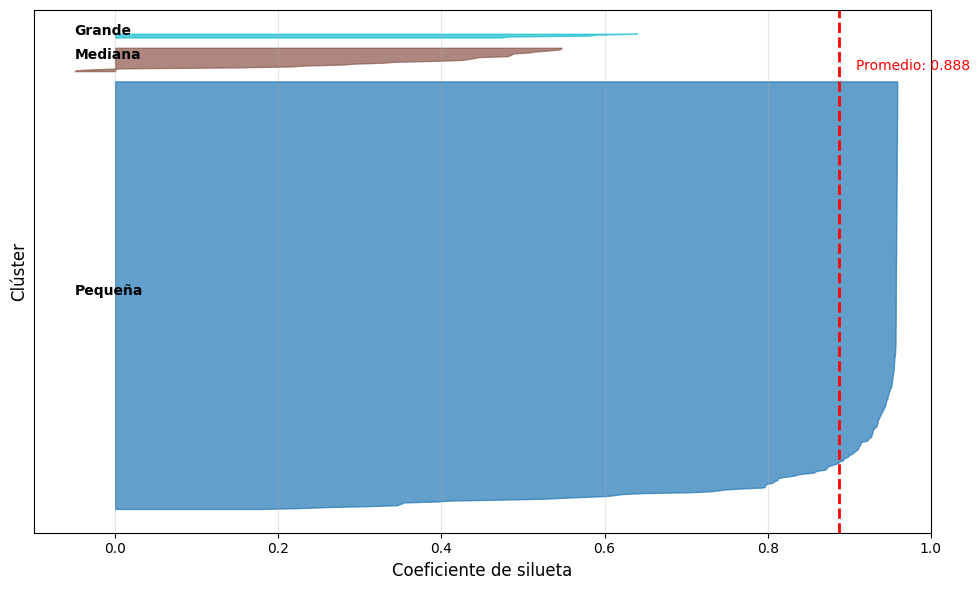

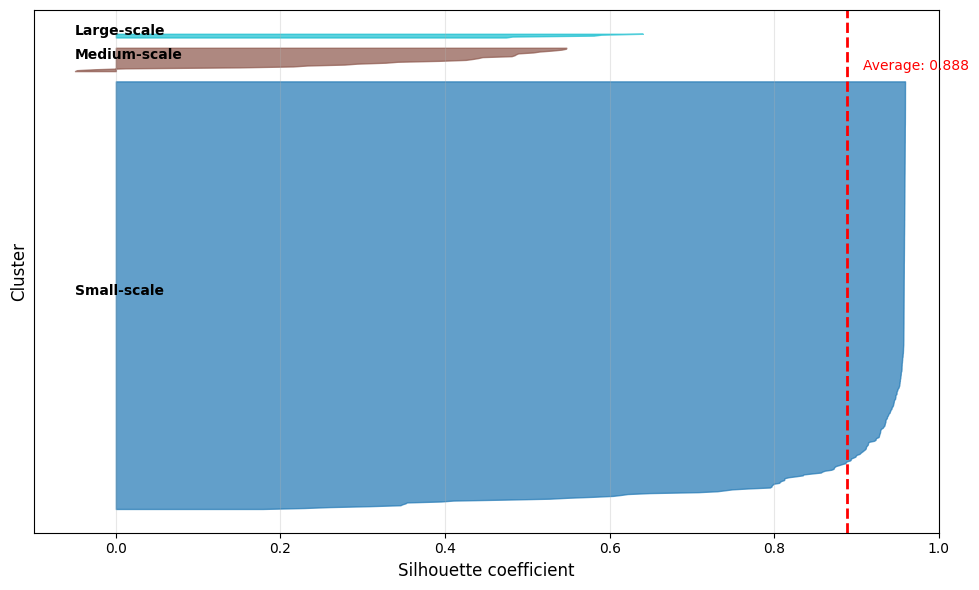

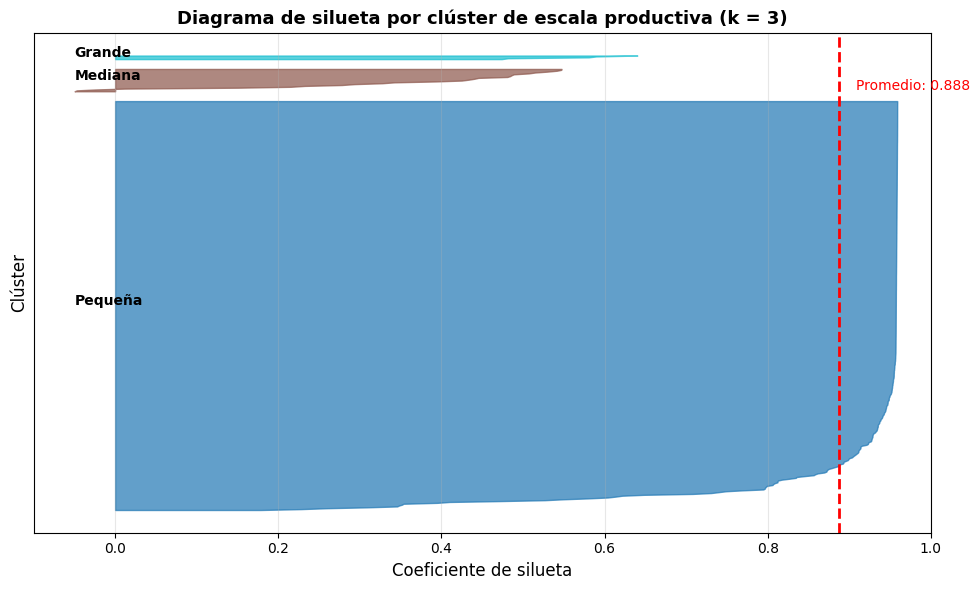

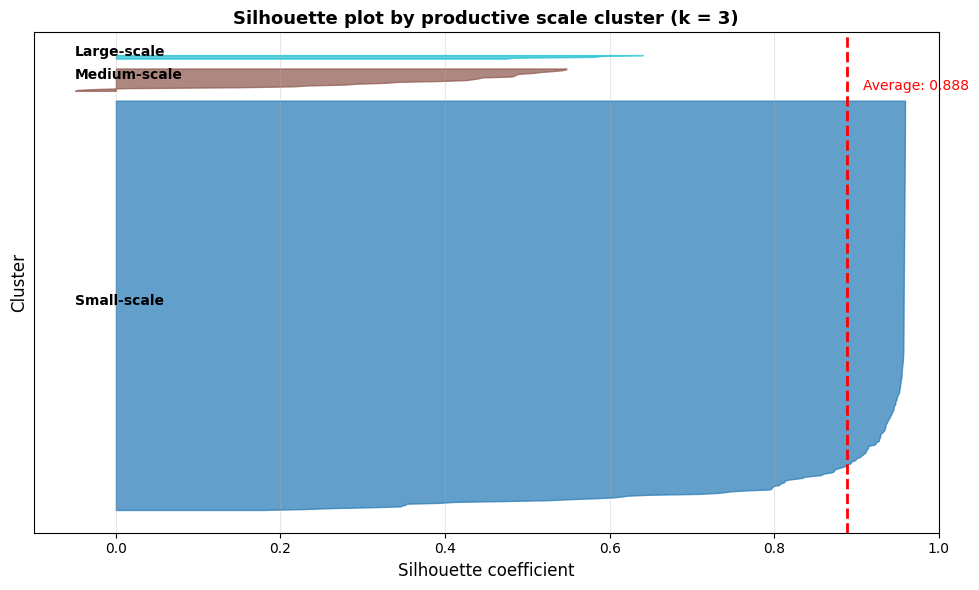

✓ 4 versiones guardadas en 'figures_clustering/':
   silhouette_plot_k3_es.pdf
   silhouette_plot_k3_en.pdf
   silhouette_plot_k3_title_es.pdf
   silhouette_plot_k3_title_en.pdf


In [19]:
# ==============================================================================
# SILHOUETTE PLOT DETALLADO — k=3
# ==============================================================================

from sklearn.metrics import silhouette_samples
from matplotlib import cm

# ── Datos ─────────────────────────────────────────────────────────────────────
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

orden      = np.argsort(kmeans.cluster_centers_[:, 0])
lmap       = {old: new for new, old in enumerate(orden)}
labels_ord = np.array([lmap[l] for l in labels])

sil_vals   = silhouette_samples(X, labels)
sil_avg    = silhouette_score(X, labels)

etiq3 = {
    'es': {0: "Pequeña",     1: "Mediana",      2: "Grande"},
    'en': {0: "Small-scale", 1: "Medium-scale", 2: "Large-scale"},
}
colors_plot = cm.tab10(np.linspace(0, 1, k))

# ── Resumen en consola ────────────────────────────────────────────────────────
print(f"ESTADÍSTICAS POR CLUSTER — k={k}")
print("=" * 70)
print(f"{'Cluster':<15} {'N pares':>10} {'Sil. min':>12} {'Sil. media':>12} {'Sil. max':>12}")
print("-" * 70)
for i in range(k):
    lbl_orig = orden[i]
    cl_sil   = sil_vals[labels == lbl_orig]
    print(f"{etiq3['es'][i]:<15} {len(cl_sil):>10} "
          f"{cl_sil.min():>12.3f} {cl_sil.mean():>12.3f} {cl_sil.max():>12.3f}")
n_neg = (sil_vals < 0).sum()
print(f"\nPares con silhouette negativo: {n_neg} ({n_neg/len(sil_vals)*100:.1f}%)")
print(f"Silhouette promedio global: {sil_avg:.4f}")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel':    'Coeficiente de silueta',
        'ylabel':    'Clúster',
        'label_avg': f'Promedio: {sil_avg:.3f}',
        'title':     'Diagrama de silueta por clúster de escala productiva (k = 3)',
    },
    'en': {
        'xlabel':    'Silhouette coefficient',
        'ylabel':    'Cluster',
        'label_avg': f'Average: {sil_avg:.3f}',
        'title':     'Silhouette plot by productive scale cluster (k = 3)',
    },
}
BASE = "silhouette_plot_k3"

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_silhouette_k3(xlabel, ylabel, label_avg, lang, title=None):
    etiq = etiq3[lang]
    fig, ax = plt.subplots(figsize=(10, 6))
    y_lower = 10
    for i in range(k):
        lbl_orig = orden[i]
        cl_sil   = np.sort(sil_vals[labels == lbl_orig])
        y_upper  = y_lower + len(cl_sil)
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cl_sil,
                         facecolor=colors_plot[i], edgecolor=colors_plot[i], alpha=0.7)
        ax.text(-0.05, y_lower + 0.5 * len(cl_sil),
                etiq[i], fontsize=10, fontweight='bold')
        y_lower = y_upper + 10
    ax.axvline(x=sil_avg, color='red', linestyle='--', linewidth=2)
    ax.text(sil_avg + 0.02, y_lower - 50, label_avg, fontsize=10, color='red')
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlim([-0.1, 1.0])
    ax.set_yticks([])
    ax.grid(True, axis='x', alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── 1. Sin título — español ───────────────────────────────────────────────────
plot_silhouette_k3(**{kk: v for kk, v in LABELS['es'].items() if kk != 'title'},
                   lang='es')
save_fig(f"{BASE}_es")
plt.show()

# ── 2. Sin título — inglés ────────────────────────────────────────────────────
plot_silhouette_k3(**{kk: v for kk, v in LABELS['en'].items() if kk != 'title'},
                   lang='en')
save_fig(f"{BASE}_en")
plt.show()

# ── 3. Con título — español ───────────────────────────────────────────────────
plot_silhouette_k3(**LABELS['es'], lang='es')
save_fig(f"{BASE}_title_es")
plt.show()

# ── 4. Con título — inglés ────────────────────────────────────────────────────
plot_silhouette_k3(**LABELS['en'], lang='en')
save_fig(f"{BASE}_title_en")
plt.show()

print(f"✓ 4 versiones guardadas en '{OUT_DIR}/':")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

In [20]:
# ==============================================================================
# DETALLE DE LOS PARES "GRANDE" PARA k=3
# ==============================================================================

print("DETALLE DE LOS PARES 'GRANDE' (k=3)")
print("=" * 80)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Ordenar clusters
centroids = kmeans.cluster_centers_
orden = np.argsort(centroids[:, 0])
label_map = {old: new for new, old in enumerate(orden)}
labels_ord = np.array([label_map[l] for l in labels])

# Agregar etiquetas al dataframe
df_features['cluster_5feat'] = labels_ord
etiquetas = {0: "Pequeña", 1: "Mediana", 2: "Grande"}
df_features['escala_5feat'] = df_features['cluster_5feat'].map(etiquetas)

# Mostrar distribución
print("\nDistribución por escala:")
print(df_features['escala_5feat'].value_counts().sort_index())

# Pares "Grande"
print("\n\nPARES CLASIFICADOS COMO 'GRANDE':")
print("-" * 100)

grandes = df_features[df_features['escala_5feat'] == 'Grande'][
    ['departamento', 'cultivo', 'produccion_promedio', 'area_sembrada_promedio', 
     'n_periodos', 'hhi_tiempo_produccion', 'hhi_espacial_cultivo']
].sort_values('produccion_promedio', ascending=False)

print(f"{'Departamento':<18} {'Cultivo':<15} {'Prod. prom.':>12} {'Área prom.':>12} {'N per.':>8} {'HHI temp':>10} {'HHI esp':>10}")
print("-" * 100)
for _, row in grandes.iterrows():
    print(f"{row['departamento']:<18} {row['cultivo']:<15} {row['produccion_promedio']:>12,.0f} {row['area_sembrada_promedio']:>12,.0f} {row['n_periodos']:>8} {row['hhi_tiempo_produccion']:>10.3f} {row['hhi_espacial_cultivo']:>10.3f}")

print(f"\nTotal pares 'Grande': {len(grandes)}")

DETALLE DE LOS PARES 'GRANDE' (k=3)

Distribución por escala:
escala_5feat
Grande       5
Mediana     26
Pequeña    459
Name: count, dtype: int64


PARES CLASIFICADOS COMO 'GRANDE':
----------------------------------------------------------------------------------------------------
Departamento       Cultivo          Prod. prom.   Área prom.   N per.   HHI temp    HHI esp
----------------------------------------------------------------------------------------------------
cundinamarca       papa                 709,923       33,907       35      0.029      0.277
boyaca             papa                 437,039       24,817       35      0.029      0.277
casanare           arroz                375,135       75,773       35      0.050      0.152
tolima             arroz                362,109       51,911       35      0.029      0.152
narino             papa                 341,163       18,275       35      0.030      0.277

Total pares 'Grande': 5


In [21]:
# ==============================================================================
# ADICIONAR CATEGORÍA DE SEGMENTACIÓN AL DATASET
# ==============================================================================

import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans

# ------------------------------------------------------------------------------
# 1. Cargar dataset de features
# ------------------------------------------------------------------------------

features_file = os.path.join("data", "transitorios_deptos_15_final_features_cuartiles.csv")
df_features = pd.read_csv(features_file, encoding="utf-8-sig")

print("ADICIONAR SEGMENTACIÓN DE ESCALA PRODUCTIVA")
print("=" * 80)
print(f"Dataset cargado: {len(df_features):,} pares\n")

# ------------------------------------------------------------------------------
# 2. Definir features y aplicar clustering final
# ------------------------------------------------------------------------------

features_escala = [
    "produccion_promedio",
    "area_sembrada_promedio",
    "n_periodos",
    "hhi_tiempo_produccion",
    "hhi_espacial_cultivo",
]

X = df_features[features_escala].values

# Clustering k=3 sin transformación
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# ------------------------------------------------------------------------------
# 3. Ordenar clusters por producción promedio (pequeña -> mediana -> grande)
# ------------------------------------------------------------------------------

centroids = kmeans.cluster_centers_
orden = np.argsort(centroids[:, 0])  # Ordenar por producción (primera feature)
label_map = {old: new for new, old in enumerate(orden)}
labels_ord = np.array([label_map[l] for l in labels])

# ------------------------------------------------------------------------------
# 4. Asignar etiquetas de escala
# ------------------------------------------------------------------------------

etiquetas_escala = {0: "Pequeña", 1: "Mediana", 2: "Grande"}
df_features['cluster_escala'] = labels_ord
df_features['escala_productiva'] = df_features['cluster_escala'].map(etiquetas_escala)

# ------------------------------------------------------------------------------
# 5. Verificar distribución
# ------------------------------------------------------------------------------

print("DISTRIBUCIÓN DE LA SEGMENTACIÓN")
print("-" * 80)
print(df_features['escala_productiva'].value_counts().sort_index())
print()

# Estadísticas por escala
print("\nESTADÍSTICAS POR ESCALA")
print("-" * 80)

for escala in ["Pequeña", "Mediana", "Grande"]:
    grupo = df_features[df_features['escala_productiva'] == escala]
    print(f"\n{escala} (n={len(grupo)}):")
    print(f"  Producción promedio - mín: {grupo['produccion_promedio'].min():,.0f}, "
          f"máx: {grupo['produccion_promedio'].max():,.0f}, "
          f"media: {grupo['produccion_promedio'].mean():,.0f}")

# ------------------------------------------------------------------------------
# 6. Guardar dataset actualizado
# ------------------------------------------------------------------------------

output_file = os.path.join("data", "transitorios_deptos_15_final_features_segmentado.csv")
df_features.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\n\n" + "=" * 80)
print("DATASET GUARDADO")
print("=" * 80)
print(f"Archivo: {output_file}")
print(f"Columnas agregadas: 'cluster_escala', 'escala_productiva'")
print(f"Total columnas: {len(df_features.columns)}")

ADICIONAR SEGMENTACIÓN DE ESCALA PRODUCTIVA
Dataset cargado: 490 pares

DISTRIBUCIÓN DE LA SEGMENTACIÓN
--------------------------------------------------------------------------------
escala_productiva
Grande       5
Mediana     26
Pequeña    459
Name: count, dtype: int64


ESTADÍSTICAS POR ESCALA
--------------------------------------------------------------------------------

Pequeña (n=459):
  Producción promedio - mín: 1, máx: 34,846, media: 2,926

Mediana (n=26):
  Producción promedio - mín: 35,926, máx: 210,754, media: 69,874

Grande (n=5):
  Producción promedio - mín: 341,163, máx: 709,923, media: 445,074


DATASET GUARDADO
Archivo: data\transitorios_deptos_15_final_features_segmentado.csv
Columnas agregadas: 'cluster_escala', 'escala_productiva'
Total columnas: 40


In [22]:
# ==============================================================================
# ROBUSTEZ DEL CLUSTERING: JERÁRQUICO, GMM Y ARI
# ==============================================================================

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

features_file = os.path.join("data", "transitorios_deptos_15_final_features_cuartiles.csv")
df_features = pd.read_csv(features_file, encoding="utf-8-sig")

feature_cols = ['produccion_promedio', 'area_sembrada_promedio', 'n_periodos',
                'hhi_tiempo_produccion', 'hhi_espacial_cultivo']

X = df_features[feature_cols].values

# K-Means original
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
labels_kmeans = kmeans.fit_predict(X)
sil_kmeans = silhouette_score(X, labels_kmeans)

# Jerárquico
hierarch = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hier = hierarch.fit_predict(X)
sil_hier = silhouette_score(X, labels_hier)

# GMM
gmm = GaussianMixture(n_components=3, random_state=42, n_init=10)
gmm.fit(X)
labels_gmm = gmm.predict(X)
sil_gmm = silhouette_score(X, labels_gmm)

# ARI entre métodos
ari_kmeans_hier = adjusted_rand_score(labels_kmeans, labels_hier)
ari_kmeans_gmm  = adjusted_rand_score(labels_kmeans, labels_gmm)
ari_hier_gmm    = adjusted_rand_score(labels_hier, labels_gmm)

print("=" * 65)
print("COMPARACIÓN DE MÉTODOS DE CLUSTERING (k=3)")
print("=" * 65)
print(f"\n{'Método':<25} {'Silhouette':>10} {'Cluster sizes (desc)':>25}")
print("-" * 65)
for lbl, name in [(labels_kmeans,'K-Means (original)'),
                  (labels_hier,  'Jerárquico (Ward)'),
                  (labels_gmm,   'GMM')]:
    sil = silhouette_score(X, lbl)
    counts = sorted(np.bincount(lbl), reverse=True)
    print(f"{name:<25} {sil:>10.3f} {str(counts):>25}")

print(f"\nARI entre métodos:")
print(f"  K-Means vs Jerárquico : {ari_kmeans_hier:.4f}")
print(f"  K-Means vs GMM        : {ari_kmeans_gmm:.4f}")
print(f"  Jerárquico vs GMM     : {ari_hier_gmm:.4f}")

# Sensibilidad a normalización
print("\n" + "=" * 65)
print("SENSIBILIDAD A ESQUEMAS DE NORMALIZACIÓN")
print("=" * 65)

X_log = np.log1p(X)
km_log = KMeans(n_clusters=3, random_state=42, n_init=50).fit_predict(X_log)
ari_log = adjusted_rand_score(labels_kmeans, km_log)
counts_log = sorted(np.bincount(km_log), reverse=True)
sil_log = silhouette_score(X_log, km_log)

X_std = StandardScaler().fit_transform(X)
km_std = KMeans(n_clusters=3, random_state=42, n_init=50).fit_predict(X_std)
ari_std = adjusted_rand_score(labels_kmeans, km_std)
counts_std = sorted(np.bincount(km_std), reverse=True)
sil_std = silhouette_score(X_std, km_std)

print(f"\n{'Esquema':<25} {'Silhouette':>10} {'ARI vs original':>16} {'Cluster sizes':>15}")
print("-" * 70)
c0 = sorted(np.bincount(labels_kmeans), reverse=True)
print(f"{'Original':<25} {sil_kmeans:>10.3f} {'—':>16} {str(c0):>15}")
print(f"{'Log1p':<25} {sil_log:>10.3f} {ari_log:>16.4f} {str(counts_log):>15}")
print(f"{'StandardScaler':<25} {sil_std:>10.3f} {ari_std:>16.4f} {str(counts_std):>15}")

# Pares gran escala por método
print("\n" + "=" * 65)
print("PARES IDENTIFICADOS COMO GRAN ESCALA POR CADA MÉTODO")
print("=" * 65)

df_check = df_features[['departamento', 'cultivo', 'produccion_promedio']].copy()
df_check['kmeans'] = labels_kmeans
df_check['hier']   = labels_hier
df_check['gmm']    = labels_gmm

for method, col in [('K-Means', 'kmeans'), ('Jerárquico', 'hier'), ('GMM', 'gmm')]:
    cluster_means = df_check.groupby(col)['produccion_promedio'].mean()
    large_cluster = cluster_means.idxmax()
    large_pairs = df_check[df_check[col] == large_cluster][['departamento','cultivo','produccion_promedio']]
    print(f"\n{method} — Cluster gran escala ({len(large_pairs)} pares):")
    print(large_pairs.sort_values('produccion_promedio', ascending=False).to_string(index=False))

COMPARACIÓN DE MÉTODOS DE CLUSTERING (k=3)

Método                    Silhouette      Cluster sizes (desc)
-----------------------------------------------------------------
K-Means (original)             0.888              [459, 26, 5]
Jerárquico (Ward)              0.865              [441, 44, 5]
GMM                           -0.073            [243, 215, 32]

ARI entre métodos:
  K-Means vs Jerárquico : 0.7284
  K-Means vs GMM        : -0.0014
  Jerárquico vs GMM     : 0.0031

SENSIBILIDAD A ESQUEMAS DE NORMALIZACIÓN

Esquema                   Silhouette  ARI vs original   Cluster sizes
----------------------------------------------------------------------
Original                       0.888                —    [459, 26, 5]
Log1p                          0.472           0.0789 [221, 167, 102]
StandardScaler                 0.508           0.0526   [373, 108, 9]

PARES IDENTIFICADOS COMO GRAN ESCALA POR CADA MÉTODO

K-Means — Cluster gran escala (5 pares):
departamento cultivo  produc

In [23]:
# ==============================================================================
# CREAR LISTA ORDENADA PARA ANEXO DE PROYECTO (EXCEL)
# ==============================================================================

import pandas as pd
import os

print("GENERACIÓN DE ANEXO - LISTA DE PARES SEGMENTADOS")
print("=" * 80)

features_file = os.path.join("data", "transitorios_deptos_15_final_features_segmentado.csv")
df_features = pd.read_csv(features_file, encoding="utf-8-sig")

# ------------------------------------------------------------------------------
# 1. Seleccionar columnas relevantes para el anexo
# ------------------------------------------------------------------------------

columnas_anexo = [
    'departamento',
    'cultivo',
    'escala_productiva',
    'produccion_promedio',
    'area_sembrada_promedio',
    'area_cosechada_promedio',
    'rendimiento_promedio',
    'n_periodos',
    'anio_inicio',
    'anio_fin'
]

df_anexo = df_features[columnas_anexo].copy()

# ------------------------------------------------------------------------------
# 2. Ordenar: primero por escala (Grande > Mediana > Pequeña), luego por producción
# ------------------------------------------------------------------------------

# Crear columna auxiliar para ordenamiento
orden_escala = {'Grande': 1, 'Mediana': 2, 'Pequeña': 3}
df_anexo['orden_escala'] = df_anexo['escala_productiva'].map(orden_escala)

# Ordenar
df_anexo = df_anexo.sort_values(
    by=['orden_escala', 'produccion_promedio'],
    ascending=[True, False]
).reset_index(drop=True)

# Agregar número de fila (para referencia en el anexo)
df_anexo.insert(0, 'N°', range(1, len(df_anexo) + 1))

# Eliminar columna auxiliar
df_anexo = df_anexo.drop(columns=['orden_escala'])

# ------------------------------------------------------------------------------
# 3. Renombrar columnas para presentación
# ------------------------------------------------------------------------------

df_anexo = df_anexo.rename(columns={
    'departamento': 'Departamento',
    'cultivo': 'Cultivo',
    'escala_productiva': 'Escala productiva',
    'produccion_promedio': 'Producción promedio (ton)',
    'area_sembrada_promedio': 'Área sembrada promedio (ha)',
    'area_cosechada_promedio': 'Área cosechada promedio (ha)',
    'rendimiento_promedio': 'Rendimiento promedio (ton/ha)',
    'n_periodos': 'N° periodos',
    'anio_inicio': 'Año inicio',
    'anio_fin': 'Año fin'
})

# ------------------------------------------------------------------------------
# 4. Formatear valores numéricos
# ------------------------------------------------------------------------------

df_anexo['Producción promedio (ton)'] = df_anexo['Producción promedio (ton)'].round(2)
df_anexo['Área sembrada promedio (ha)'] = df_anexo['Área sembrada promedio (ha)'].round(2)
df_anexo['Área cosechada promedio (ha)'] = df_anexo['Área cosechada promedio (ha)'].round(2)
df_anexo['Rendimiento promedio (ton/ha)'] = df_anexo['Rendimiento promedio (ton/ha)'].round(2)

# ------------------------------------------------------------------------------
# 5. Vista previa
# ------------------------------------------------------------------------------

print("\nVista previa - Primeros 10 registros (Gran escala + inicio Mediana):")
print("-" * 100)
print(df_anexo.head(10).to_string(index=False))

print("\n\nResumen por escala:")
print(df_anexo['Escala productiva'].value_counts().sort_index())

# ------------------------------------------------------------------------------
# 6. Guardar en Excel con formato
# ------------------------------------------------------------------------------

output_folder = "outputs"
os.makedirs(output_folder, exist_ok=True)

excel_file = os.path.join(output_folder, "Anexo_Segmentacion_Escala_Productiva.xlsx")

# Crear Excel con formato usando openpyxl
with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    
    # Hoja 1: Lista completa
    df_anexo.to_excel(writer, sheet_name='Lista completa', index=False)
    
    # Hoja 2: Solo Gran escala
    df_grande = df_anexo[df_anexo['Escala productiva'] == 'Grande']
    df_grande.to_excel(writer, sheet_name='Gran escala', index=False)
    
    # Hoja 3: Solo Mediana escala
    df_mediana = df_anexo[df_anexo['Escala productiva'] == 'Mediana']
    df_mediana.to_excel(writer, sheet_name='Mediana escala', index=False)
    
    # Hoja 4: Solo Pequeña escala
    df_pequena = df_anexo[df_anexo['Escala productiva'] == 'Pequeña']
    df_pequena.to_excel(writer, sheet_name='Pequeña escala', index=False)
    
    # Hoja 5: Resumen estadístico
    resumen = df_features.groupby('escala_productiva').agg({
        'produccion_promedio': ['count', 'min', 'max', 'mean'],
        'area_sembrada_promedio': ['min', 'max', 'mean'],
        'area_cosechada_promedio': ['min', 'max', 'mean'],
        'n_periodos': ['min', 'max', 'mean']
    }).round(2)
    resumen.columns = ['N pares', 'Prod. mín', 'Prod. máx', 'Prod. media',
                       'Área S. mín', 'Área S. máx', 'Área S. media',
                        'Área C. mín', 'Área C. máx', 'Área C. media',
                       'Periodos mín', 'Periodos máx', 'Periodos media']
    resumen = resumen.reset_index()
    resumen = resumen.rename(columns={'escala_productiva': 'Escala'})
    
    # Ordenar resumen
    orden_resumen = {'Grande': 1, 'Mediana': 2, 'Pequeña': 3}
    resumen['orden'] = resumen['Escala'].map(orden_resumen)
    resumen = resumen.sort_values('orden').drop(columns=['orden'])
    
    resumen.to_excel(writer, sheet_name='Resumen estadístico', index=False)

print("\n\n" + "=" * 80)
print("ARCHIVO EXCEL GENERADO")
print("=" * 80)
print(f"Archivo: {excel_file}")
print(f"\nHojas incluidas:")
print(f"  1. Lista completa ({len(df_anexo)} pares)")
print(f"  2. Gran escala ({len(df_grande)} pares)")
print(f"  3. Mediana escala ({len(df_mediana)} pares)")
print(f"  4. Pequeña escala ({len(df_pequena)} pares)")
print(f"  5. Resumen estadístico")

# ------------------------------------------------------------------------------
# 7. Mostrar pares de gran escala 
# ------------------------------------------------------------------------------

print("\n\n" + "=" * 80)
print("PARES DE GRAN ESCALA")
print("=" * 80)
print(df_grande.to_string(index=False))

GENERACIÓN DE ANEXO - LISTA DE PARES SEGMENTADOS

Vista previa - Primeros 10 registros (Gran escala + inicio Mediana):
----------------------------------------------------------------------------------------------------
 N° Departamento Cultivo Escala productiva  Producción promedio (ton)  Área sembrada promedio (ha)  Área cosechada promedio (ha)  Rendimiento promedio (ton/ha)  N° periodos  Año inicio  Año fin
  1 cundinamarca    papa            Grande                  709922.83                     33907.14                      32088.58                          22.00           35        2007     2024
  2       boyaca    papa            Grande                  437039.39                     24816.73                      23315.09                          18.67           35        2007     2024
  3     casanare   arroz            Grande                  375134.74                     75772.73                      70298.85                           5.45           35        2007     2024
  4 

Puntos de corte (cuartiles):
  Q1 (25%): 139.86 ton
  Q2 (50%): 776.47 ton
  Q3 (75%): 4,056.90 ton

Distribución por cuartiles:
escala_cuartiles_prod
Q1_baja           123
Q2_media-baja     122
Q3_media-alta     122
Q4_gran_escala    123
Name: count, dtype: int64


CLASIFICACIÓN POR CLUSTERING (K-Means, k=3)
--------------------------------------------------------------------------------
Pequeña: 1.43 - 34,846.25 ton
Mediana: 35,925.69 - 210,753.66 ton
Grande: 341,163.44 - 709,922.83 ton

Puntos de corte (clustering):
  Pequeña-Mediana: ~35,385.97 ton
  Mediana-Grande:  ~275,958.55 ton

Distribución por clustering:
escala_productiva
Grande       5
Mediana     26
Pequeña    459
Name: count, dtype: int64


TABLA CRUZADA: CUARTILES VS CLUSTERING
--------------------------------------------------------------------------------
escala_cuartiles_prod  Q1_baja  Q2_media-baja  Q3_media-alta  Q4_gran_escala  \
escala_productiva                                                              
Grand

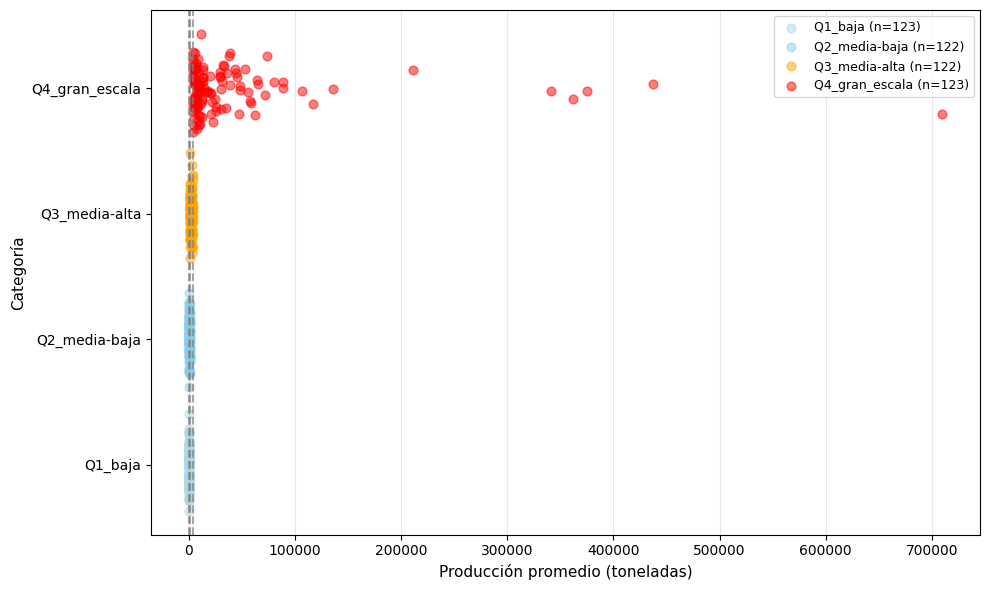

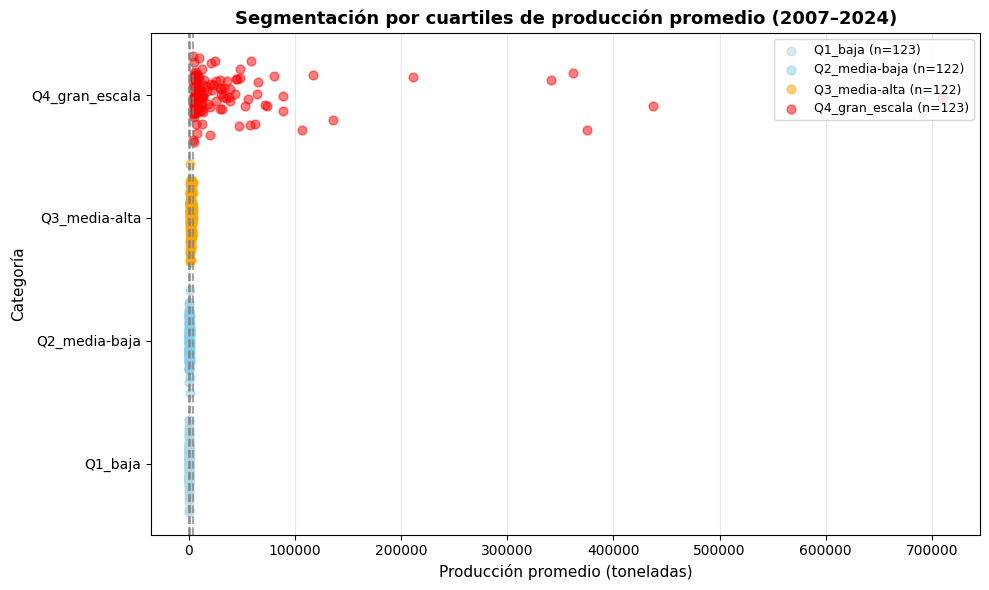

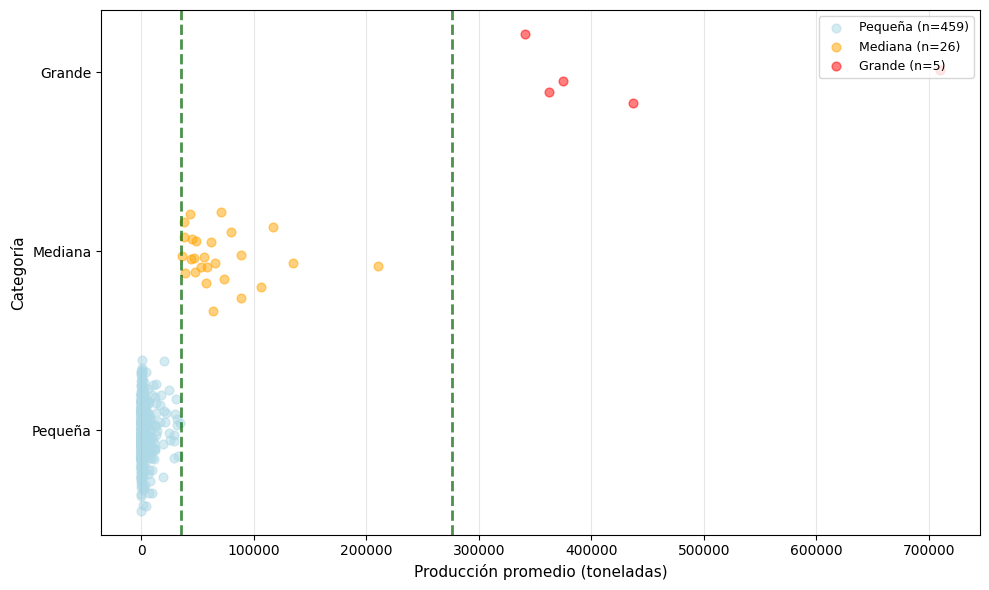

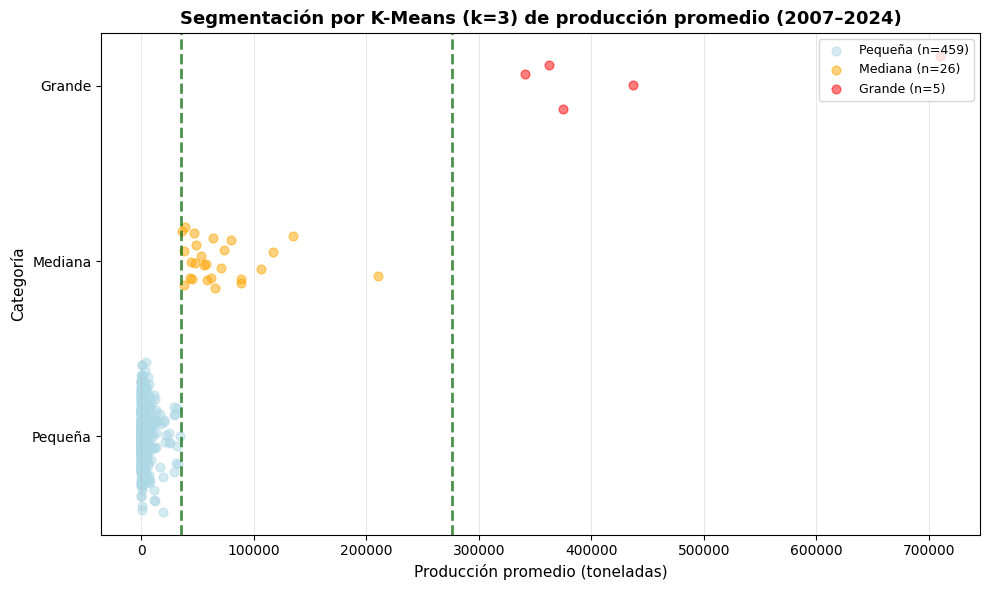

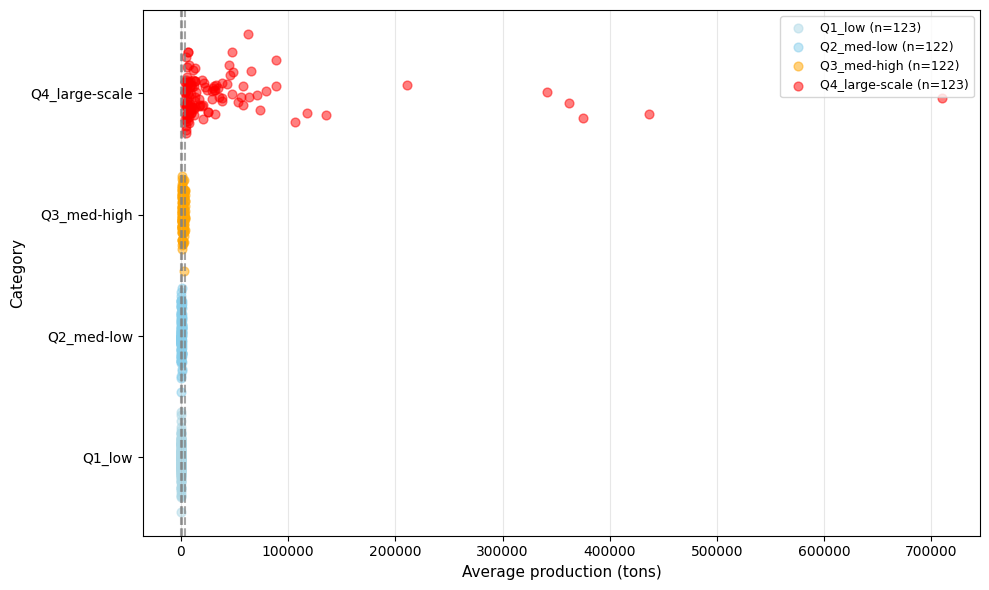

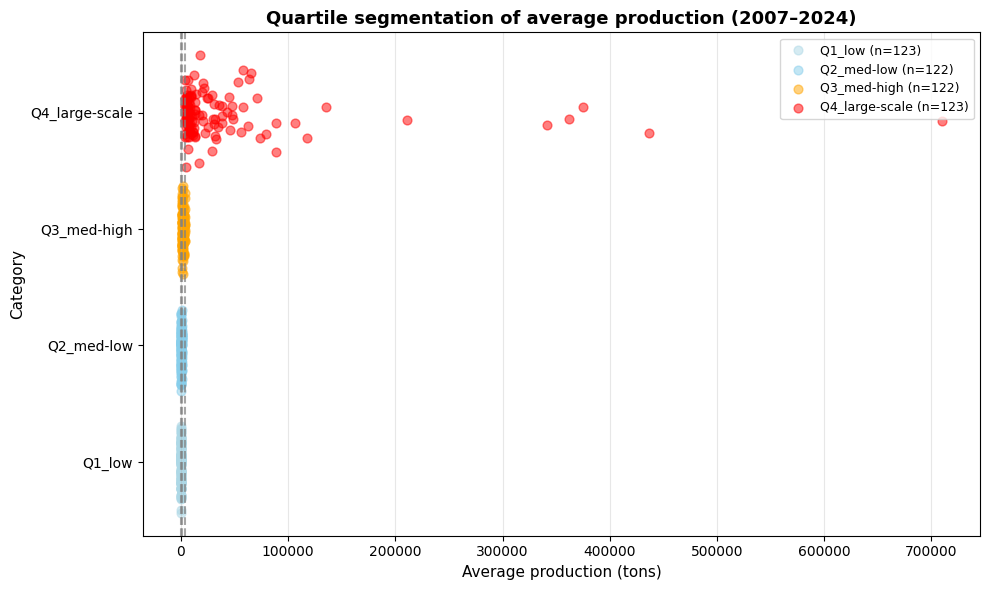

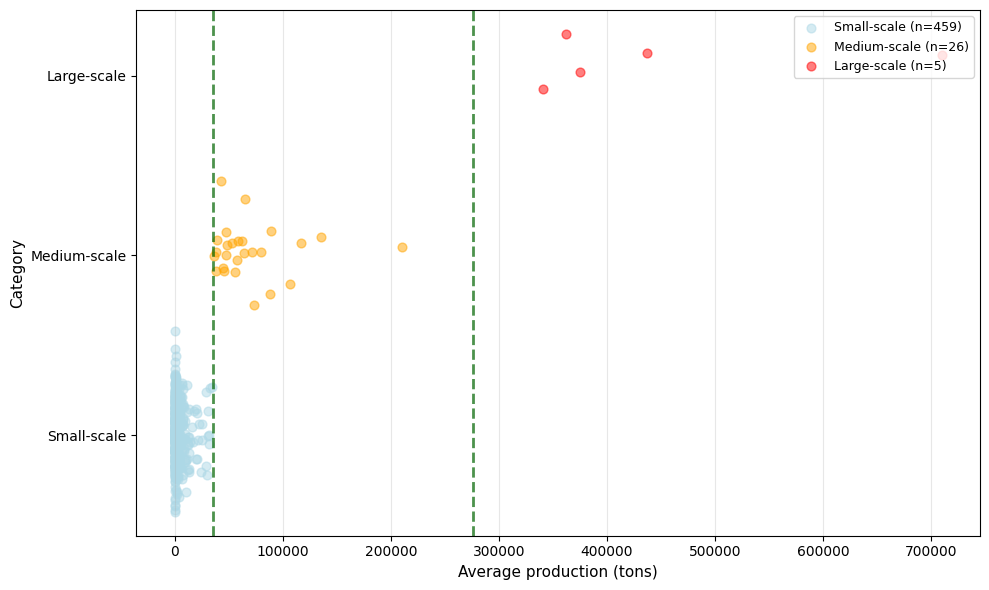

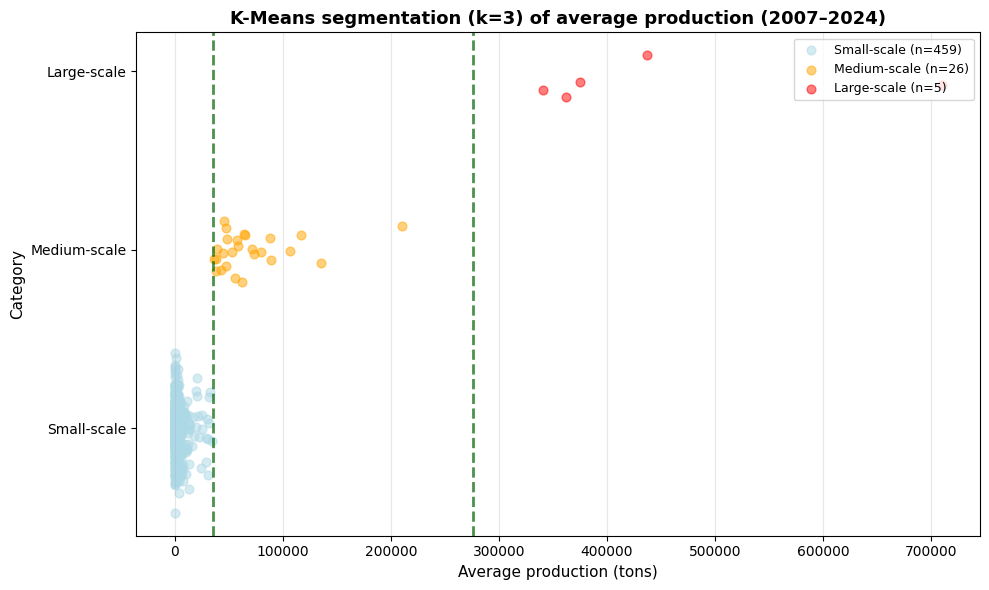

✓ 8 figuras guardadas en 'figures_clustering/'
  comparacion_cuartiles_es.pdf / comparacion_cuartiles_title_es.pdf
  comparacion_clustering_en.pdf / comparacion_clustering_title_en.pdf  ...


In [26]:
# ==============================================================================
# COMPARACIÓN: CUARTILES VS CLUSTERING
# ==============================================================================

import pandas as pd
import numpy as np

# ── Cálculos ──────────────────────────────────────────────────────────────────
q1 = df_features['produccion_promedio'].quantile(0.25)
q2 = df_features['produccion_promedio'].quantile(0.50)
q3 = df_features['produccion_promedio'].quantile(0.75)

print(f"Puntos de corte (cuartiles):")
print(f"  Q1 (25%): {q1:,.2f} ton")
print(f"  Q2 (50%): {q2:,.2f} ton")
print(f"  Q3 (75%): {q3:,.2f} ton")

print(f"\nDistribución por cuartiles:")
print(df_features['escala_cuartiles_prod'].value_counts().sort_index())

print("\n\nCLASIFICACIÓN POR CLUSTERING (K-Means, k=3)")
print("-" * 80)
for escala in ["Pequeña", "Mediana", "Grande"]:
    grupo = df_features[df_features['escala_productiva'] == escala]
    print(f"{escala}: {grupo['produccion_promedio'].min():,.2f} - {grupo['produccion_promedio'].max():,.2f} ton")

pequena_max    = df_features[df_features['escala_productiva'] == 'Pequeña']['produccion_promedio'].max()
mediana_min    = df_features[df_features['escala_productiva'] == 'Mediana']['produccion_promedio'].min()
mediana_max    = df_features[df_features['escala_productiva'] == 'Mediana']['produccion_promedio'].max()
grande_min     = df_features[df_features['escala_productiva'] == 'Grande']['produccion_promedio'].min()
corte1_cluster = (pequena_max + mediana_min) / 2
corte2_cluster = (mediana_max + grande_min) / 2

print(f"\nPuntos de corte (clustering):")
print(f"  Pequeña-Mediana: ~{corte1_cluster:,.2f} ton")
print(f"  Mediana-Grande:  ~{corte2_cluster:,.2f} ton")
print(f"\nDistribución por clustering:")
print(df_features['escala_productiva'].value_counts().sort_index())

print("\n\nTABLA CRUZADA: CUARTILES VS CLUSTERING")
print("-" * 80)
tabla_cruzada = pd.crosstab(
    df_features['escala_productiva'],
    df_features['escala_cuartiles_prod'],
    margins=True
)
print(tabla_cruzada)

q4_pares       = df_features[df_features['escala_cuartiles_prod'] == 'Q4_gran_escala']
cluster_grande = df_features[df_features['escala_productiva'] == 'Grande']
cv_q4          = q4_pares['produccion_promedio'].std()       / q4_pares['produccion_promedio'].mean()       * 100
cv_grande      = cluster_grande['produccion_promedio'].std() / cluster_grande['produccion_promedio'].mean() * 100
rango_q4       = q4_pares['produccion_promedio'].max()       - q4_pares['produccion_promedio'].min()
rango_grande   = cluster_grande['produccion_promedio'].max() - cluster_grande['produccion_promedio'].min()

print(f"\n\nCOMPARACIÓN DEL GRUPO 'GRANDE' / 'Q4'")
print("-" * 80)
print(f"CV Q4 (cuartiles):       {cv_q4:.1f}%")
print(f"CV Grande (clustering):  {cv_grande:.1f}%")
print(f"Rango Q4:                {rango_q4:,.0f} ton")
print(f"Rango Grande:            {rango_grande:,.0f} ton")

resumen = pd.DataFrame({
    'Criterio': ['Método de corte', 'N° categorías', 'Pares categoría superior',
                 '% superior', 'Prod. mínima superior', 'Prod. media superior',
                 'CV superior', 'Fundamento'],
    'Cuartiles': ['Percentiles fijos (25%, 50%, 75%)', '4', f'{len(q4_pares)}',
                  f'{len(q4_pares)/len(df_features)*100:.1f}%',
                  f'{q4_pares["produccion_promedio"].min():,.0f} ton',
                  f'{q4_pares["produccion_promedio"].mean():,.0f} ton',
                  f'{cv_q4:.1f}%', 'Distribución uniforme forzada'],
    'Clustering': ['Discontinuidades naturales', '3', f'{len(cluster_grande)}',
                   f'{len(cluster_grande)/len(df_features)*100:.1f}%',
                   f'{cluster_grande["produccion_promedio"].min():,.0f} ton',
                   f'{cluster_grande["produccion_promedio"].mean():,.0f} ton',
                   f'{cv_grande:.1f}%', 'Estructura real de los datos'],
})
print("\n\nRESUMEN COMPARATIVO")
print("=" * 80)
print(resumen.to_string(index=False))

# ── Constantes para figuras ───────────────────────────────────────────────────
# Etiquetas de cuartiles por idioma (clave = valor real en el df)
cuartil_col_keys = ['Q1_baja', 'Q2_media-baja', 'Q3_media-alta', 'Q4_gran_escala']
cuartil_labels = {
    'es': ['Q1_baja', 'Q2_media-baja', 'Q3_media-alta', 'Q4_gran_escala'],
    'en': ['Q1_low',  'Q2_med-low',    'Q3_med-high',   'Q4_large-scale'],
}
colors_cuartiles = {
    'Q1_baja':        'lightblue',
    'Q2_media-baja':  'skyblue',
    'Q3_media-alta':  'orange',
    'Q4_gran_escala': 'red',
}

# Etiquetas y colores del clustering por idioma
escala_col = ['Pequeña', 'Mediana', 'Grande']
escala_keys = {
    'es': ['Pequeña',     'Mediana',      'Grande'],
    'en': ['Small-scale', 'Medium-scale', 'Large-scale'],
}
colors_cluster = {
    'es': {'Pequeña':     'lightblue', 'Mediana':      'orange', 'Grande':      'red'},
    'en': {'Small-scale': 'lightblue', 'Medium-scale': 'orange', 'Large-scale': 'red'},
}

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel':        'Producción promedio (toneladas)',
        'ylabel':        'Categoría',
        'title_q':       'Segmentación por cuartiles (percentiles fijos: 25%, 50%, 75%)',
        'title_cl':      'Segmentación por clustering (discontinuidades naturales)',
        'title_q_full':  'Segmentación por cuartiles de producción promedio (2007–2024)',
        'title_cl_full': 'Segmentación por K-Means (k=3) de producción promedio (2007–2024)',
    },
    'en': {
        'xlabel':        'Average production (tons)',
        'ylabel':        'Category',
        'title_q':       'Quartile segmentation (fixed percentiles: 25%, 50%, 75%)',
        'title_cl':      'Clustering segmentation (natural discontinuities)',
        'title_q_full':  'Quartile segmentation of average production (2007–2024)',
        'title_cl_full': 'K-Means segmentation (k=3) of average production (2007–2024)',
    },
}

BASE_Q  = "comparacion_cuartiles"
BASE_CL = "comparacion_clustering"

# ── Función panel cuartiles ───────────────────────────────────────────────────
def plot_cuartiles(xlabel, ylabel, title_q, lang, title=None, **_):
    labels_vis = cuartil_labels[lang]   # etiquetas visibles en la figura
    fig, ax = plt.subplots(figsize=(10, 6))
    for idx, cuartil_col in enumerate(cuartil_col_keys):
        datos = df_features[df_features['escala_cuartiles_prod'] == cuartil_col]['produccion_promedio']
        n     = len(datos)
        ax.scatter(datos,
                   np.random.normal(idx, 0.15, size=n),
                   alpha=0.5, label=f'{labels_vis[idx]} (n={n})',
                   color=colors_cuartiles[cuartil_col], s=40)
    for xv in [q1, q2, q3]:
        ax.axvline(x=xv, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_yticks([0, 1, 2, 3])
    ax.set_yticklabels(labels_vis)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Función panel clustering ──────────────────────────────────────────────────
def plot_clustering_fig(xlabel, ylabel, title_cl, lang, title=None, **_):
    ek  = escala_keys[lang]
    col = colors_cluster[lang]
    fig, ax = plt.subplots(figsize=(10, 6))
    for i, (escala_df, escala_label) in enumerate(zip(escala_col, ek)):
        datos = df_features[df_features['escala_productiva'] == escala_df]['produccion_promedio']
        n     = len(datos)
        ax.scatter(datos,
                   np.random.normal(i, 0.15, size=n),
                   alpha=0.5, label=f'{escala_label} (n={n})',
                   color=col[escala_label], s=40)
    for xv in [corte1_cluster, corte2_cluster]:
        ax.axvline(x=xv, color='darkgreen', linestyle='--', linewidth=2, alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(ek)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── Generar las 8 figuras (2 paneles × 2 idiomas × 2 variantes) ──────────────
total = 0
for lang in ['es', 'en']:
    lbl = LABELS[lang]

    plot_cuartiles(**{k: v for k, v in lbl.items()
                      if k not in ('title_q_full', 'title_cl_full')},
                   lang=lang)
    save_fig(f"{BASE_Q}_{lang}")
    plt.show()

    plot_cuartiles(**{k: v for k, v in lbl.items()
                      if k not in ('title_q_full', 'title_cl_full')},
                   lang=lang, title=lbl['title_q_full'])
    save_fig(f"{BASE_Q}_title_{lang}")
    plt.show()

    plot_clustering_fig(**{k: v for k, v in lbl.items()
                           if k not in ('title_q_full', 'title_cl_full')},
                        lang=lang)
    save_fig(f"{BASE_CL}_{lang}")
    plt.show()

    plot_clustering_fig(**{k: v for k, v in lbl.items()
                           if k not in ('title_q_full', 'title_cl_full')},
                        lang=lang, title=lbl['title_cl_full'])
    save_fig(f"{BASE_CL}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_Q}_es.pdf / {BASE_Q}_title_es.pdf")
print(f"  {BASE_CL}_en.pdf / {BASE_CL}_title_en.pdf  ...")

### Mapa Colombia

DISTRIBUCIÓN DE PARES POR ESCALA PRODUCTIVA
escala_productiva
Pequeña    459
Mediana     26
Grande       5
Name: count, dtype: int64

Departamentos en shapefile: 32
Departamentos con datos:    32

RESUMEN: DEPARTAMENTOS POR ESCALA PRODUCTIVA

GRANDE (5 pares, 5 departamentos):
  Narino: 1 pares
  Boyaca: 1 pares
  Casanare: 1 pares
  Tolima: 1 pares
  Cundinamarca: 1 pares

MEDIANA (26 pares, 14 departamentos):
  Meta: 4 pares
  Norte De Santander: 3 pares
  Boyaca: 3 pares
  Cesar: 2 pares
  Antioquia: 2 pares
  Cordoba: 2 pares
  Bolivar: 2 pares
  Huila: 2 pares
  Cauca: 1 pares
  Valle Del Cauca: 1 pares
  Sucre: 1 pares
  Santander: 1 pares
  Tolima: 1 pares
  Cundinamarca: 1 pares

PEQUEÑA (459 pares, 32 departamentos):
  Cundinamarca: 37 pares
  Cauca: 33 pares
  Boyaca: 30 pares
  Narino: 29 pares
  Norte De Santander: 28 pares
  Valle Del Cauca: 27 pares
  Santander: 27 pares
  Antioquia: 25 pares
  Tolima: 19 pares
  Caldas: 19 pares
  Huila: 15 pares
  Atlantico: 14 pares
  

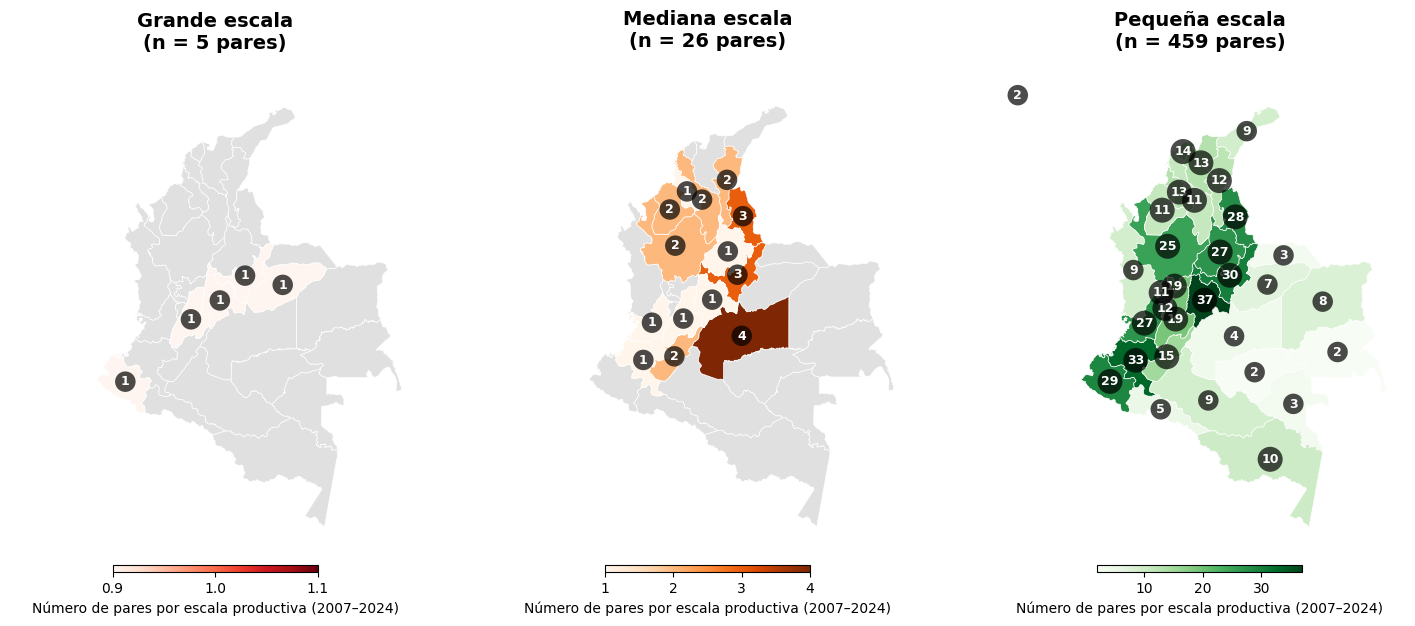

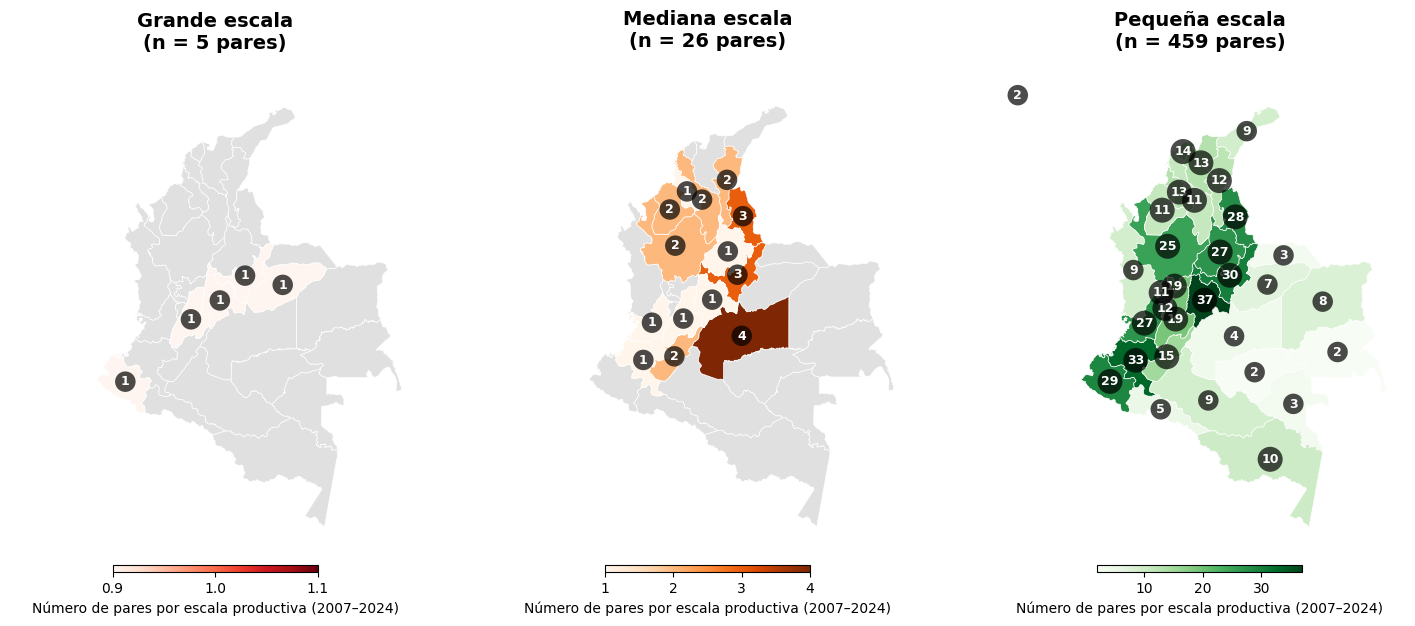

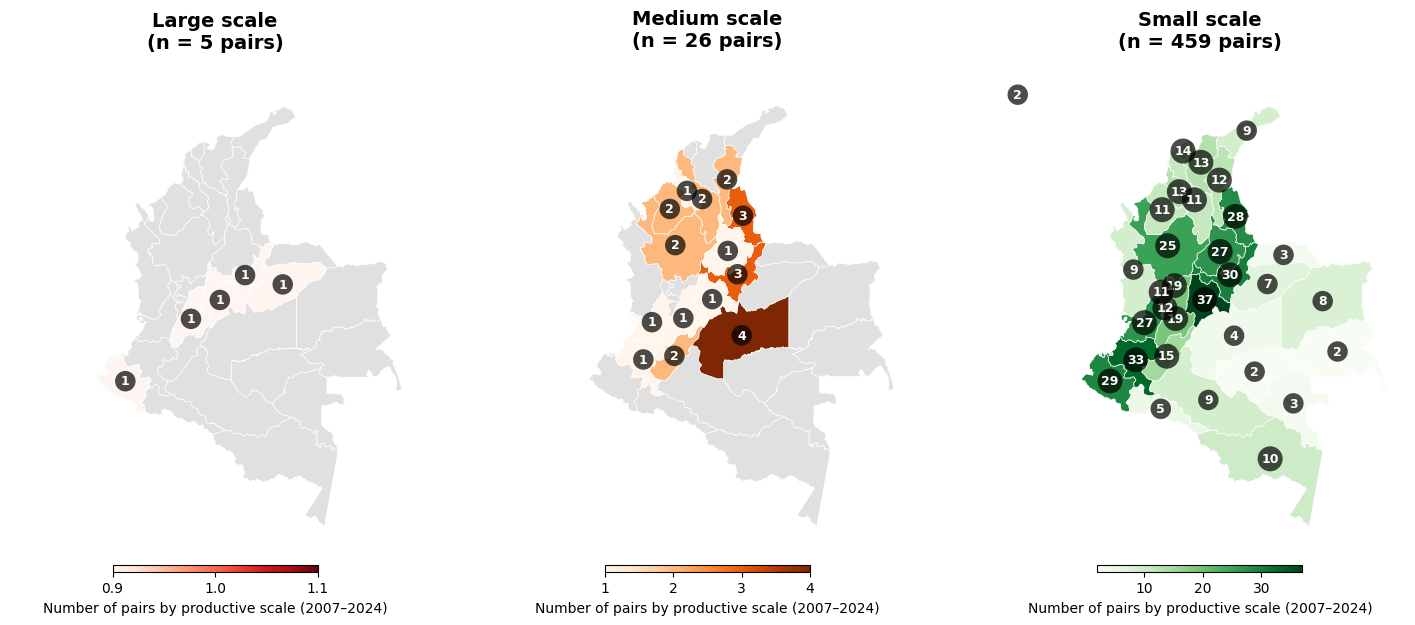

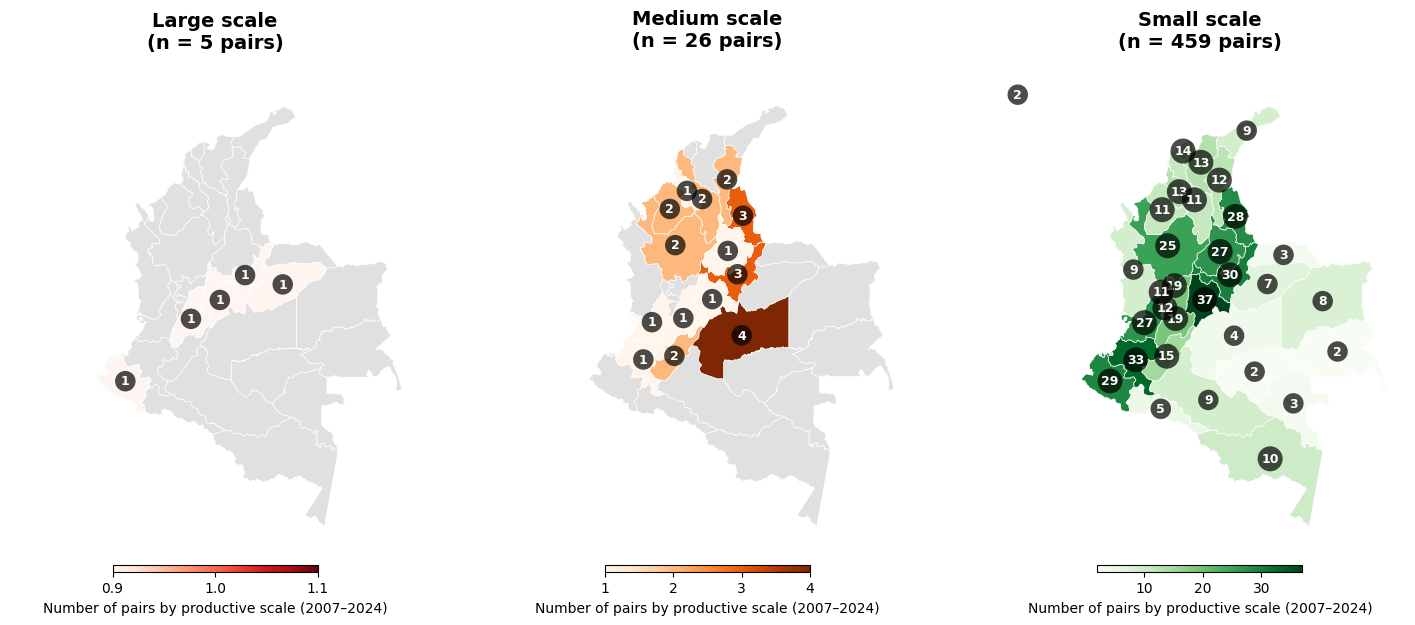

✓ 4 figuras guardadas en 'figures_clustering/'
   mapa_panel_escalas_productivas_es.pdf
   mapa_panel_escalas_productivas_en.pdf
   mapa_panel_escalas_productivas_title_es.pdf
   mapa_panel_escalas_productivas_title_en.pdf


In [29]:
# ==============================================================================
# PANEL DE MAPAS - DISTRIBUCIÓN DE PARES POR ESCALA PRODUCTIVA
# ==============================================================================

import pandas as pd
import geopandas as gpd
import os

# ── Datos ─────────────────────────────────────────────────────────────────────
df_segmentado = pd.read_csv(
    "data/transitorios_deptos_15_final_features_segmentado.csv",
    encoding="utf-8-sig"
)

conteo_escala = (
    df_segmentado
    .groupby(['departamento', 'escala_productiva'], as_index=False)
    .size()
    .rename(columns={'size': 'n_pares'})
)
conteo_pivot = (
    conteo_escala
    .pivot(index='departamento', columns='escala_productiva', values='n_pares')
    .fillna(0)
    .reset_index()
)

# ── GeoJSON ───────────────────────────────────────────────────────────────────
gdf_colombia = gpd.read_file(os.path.join("data", "co.json"))
col_nombre   = next(
    (c for c in ['NOMBRE_DPT', 'nombre', 'name', 'NAME', 'DPTO',
                 'departamento', 'DEPARTAMENTO'] if c in gdf_colombia.columns),
    gdf_colombia.select_dtypes(include=['object']).columns.difference(['geometry'])[0]
)

def normalizar(serie):
    return (serie.str.lower()
                 .str.normalize('NFKD')
                 .str.encode('ascii', errors='ignore')
                 .str.decode('utf-8')
                 .str.strip())

gdf_colombia['nombre_depto'] = normalizar(gdf_colombia[col_nombre])
conteo_pivot['nombre_depto'] = normalizar(conteo_pivot['departamento'])

bog_mask  = gdf_colombia['nombre_depto'].str.contains('bogota', na=False)
cund_mask = gdf_colombia['nombre_depto'].str.contains('cundinamarca', na=False)
if bog_mask.any() and cund_mask.any():
    geom_u = (gdf_colombia[bog_mask].geometry.values[0]
              .union(gdf_colombia[cund_mask].geometry.values[0]))
    gdf_colombia.loc[cund_mask, 'geometry'] = geom_u
    gdf_colombia = gdf_colombia[~bog_mask].copy()

gdf_mapa = gdf_colombia.merge(conteo_pivot, on='nombre_depto', how='left')
for col in ['Grande', 'Mediana', 'Pequeña']:
    if col in gdf_mapa.columns:
        gdf_mapa[col] = gdf_mapa[col].fillna(0)

escalas = ['Grande', 'Mediana', 'Pequeña']
cmaps   = ['Reds', 'Oranges', 'Greens']
totales = [int(gdf_mapa[esc].sum()) for esc in escalas]

# ── Resumen en consola ────────────────────────────────────────────────────────
print("DISTRIBUCIÓN DE PARES POR ESCALA PRODUCTIVA")
print("=" * 70)
print(df_segmentado['escala_productiva'].value_counts())
print(f"\nDepartamentos en shapefile: {len(gdf_colombia)}")
print(f"Departamentos con datos:    "
      f"{(gdf_mapa[escalas].sum(axis=1) > 0).sum()}")
print("\n" + "=" * 70)
print("RESUMEN: DEPARTAMENTOS POR ESCALA PRODUCTIVA")
for escala in escalas:
    sub = (gdf_mapa[gdf_mapa[escala] > 0][['nombre_depto', escala]]
           .sort_values(escala, ascending=False))
    print(f"\n{escala.upper()} ({int(gdf_mapa[escala].sum())} pares, "
          f"{len(sub)} departamentos):")
    for _, row in sub.iterrows():
        print(f"  {row['nombre_depto'].title()}: {int(row[escala])} pares")

# ── Variantes de texto ────────────────────────────────────────────────────────
# ── Variantes de texto ────────────────────────────────────────────────────────
subtitulos = {
    'es': [f'{esc} escala\n(n = {tot} pares)'
           for esc, tot in zip(['Grande', 'Mediana', 'Pequeña'], totales)],
    'en': [f'{esc} scale\n(n = {tot} pairs)'
           for esc, tot in zip(['Large', 'Medium', 'Small'], totales)],
}

LABELS = {
    'es': {
        'cbar':      'Número de pares por escala productiva (2007–2024)',
        'subtitles': subtitulos['es'],
    },
    'en': {
        'cbar':      'Number of pairs by productive scale (2007–2024)',
        'subtitles': subtitulos['en'],
    },
}
BASE = "mapa_panel_escalas_productivas"

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_panel_mapas(cbar, subtitles=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 10))
    for ax, escala, cmap, subtit in zip(axes, escalas, cmaps, subtitles):
        gdf_mapa.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.5)
        gdf_con = gdf_mapa[gdf_mapa[escala] > 0].copy()
        if len(gdf_con) > 0:
            gdf_con.plot(
                ax=ax, column=escala, cmap=cmap,
                edgecolor='white', linewidth=0.5, legend=True,
                legend_kwds={'label': cbar, 'shrink': 0.5,
                             'orientation': 'horizontal',
                             'pad': 0.02, 'aspect': 30})
            for _, row in gdf_con.iterrows():
                c = row.geometry.centroid
                ax.annotate(str(int(row[escala])), xy=(c.x, c.y),
                            ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white',
                            bbox=dict(boxstyle='circle,pad=0.3',
                                      facecolor='black', edgecolor='none',
                                      alpha=0.7))
        ax.set_title(subtit, fontsize=14, fontweight='bold')
        ax.axis('off')

# ── Generar las 4 figuras ─────────────────────────────────────────────────────
total = 0
for lang in ['es', 'en']:
    lbl = LABELS[lang]

    # Sin título
    plot_panel_mapas(lbl['cbar'], lbl['subtitles'])
    save_fig(f"{BASE}_{lang}")
    plt.show()

    # Con título
    plot_panel_mapas(lbl['cbar'], lbl['subtitles'])
    save_fig(f"{BASE}_title_{lang}")
    plt.show()

    total += 2

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

## Clustering Caracterización

In [30]:
# ==============================================================================
# CLUSTERING POR DIMENSIÓN - CONFIGURACIÓN GENERAL
# ==============================================================================

import pandas as pd
import numpy as np
import os
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ------------------------------------------------------------------------------
# 1. Cargar dataset
# ------------------------------------------------------------------------------

features_file = os.path.join("data", "transitorios_deptos_15_final_features_segmentado.csv")
df_features = pd.read_csv(features_file, encoding="utf-8-sig")

print("CLUSTERING POR DIMENSIÓN - PATRONES TEMPORALES")
print("=" * 80)
print(f"Dataset: {len(df_features):,} pares\n")

# ------------------------------------------------------------------------------
# 2. Definir dimensiones y sus variables
# ------------------------------------------------------------------------------

dimensiones = {
    'Volatilidad': {
        'variables': ['cv_produccion'],
        'etiquetas_k3': {0: 'Estable', 1: 'Moderada', 2: 'Volátil'},
        'etiquetas_k2': {0: 'Estable', 1: 'Volátil'},
        'descripcion': 'Variabilidad relativa de la producción en el tiempo'
    },
    'Tendencia': {
        'variables': ['tendencia_produccion_pendiente', 'tendencia_produccion_r2', 'mk_tau_produccion'],
        'etiquetas_k3': {0: 'Decreciente', 1: 'Estable', 2: 'Creciente'},
        'etiquetas_k2': {0: 'Decreciente/Estable', 1: 'Creciente'},
        'descripcion': 'Dirección y fuerza del cambio temporal'
    },
    'Estacionalidad': {
        'variables': ['ratio_AB', 'porcentaje_A_mayor_B'],
        'etiquetas_k3': {0: 'Sin patrón', 1: 'Moderada', 2: 'Marcada'},
        'etiquetas_k2': {0: 'Sin patrón', 1: 'Estacional'},
        'descripcion': 'Diferencia sistemática entre periodos A y B'
    },
    'Continuidad': {
        'variables': ['completitud_pct'],
        'etiquetas_k3': {0: 'Intermitente', 1: 'Regular', 2: 'Continua'},
        'etiquetas_k2': {0: 'Intermitente', 1: 'Continua'},
        'descripcion': 'Solidez y consistencia de la serie temporal'
    },
    'Concentración': {
        'variables': ['hhi_espacial_cultivo'],
        'etiquetas_k3': {0: 'Disperso', 1: 'Moderado', 2: 'Concentrado'},
        'etiquetas_k2': {0: 'Disperso', 1: 'Concentrado'},
        'descripcion': 'Concentración geográfica del cultivo a nivel nacional'
    }
}

print("DIMENSIONES A ANALIZAR:")
print("-" * 80)
for dim, config in dimensiones.items():
    print(f"\n{dim}:")
    print(f"  Variables: {config['variables']}")
    print(f"  Descripción: {config['descripcion']}")

# ------------------------------------------------------------------------------
# 3. Eliminar filas con nulos en cualquier variable
# ------------------------------------------------------------------------------

todas_variables = []
for config in dimensiones.values():
    todas_variables.extend(config['variables'])

df_analisis = df_features.dropna(subset=todas_variables).copy()
print(f"\n\nPares con datos completos: {len(df_analisis)} de {len(df_features)}")

CLUSTERING POR DIMENSIÓN - PATRONES TEMPORALES
Dataset: 490 pares

DIMENSIONES A ANALIZAR:
--------------------------------------------------------------------------------

Volatilidad:
  Variables: ['cv_produccion']
  Descripción: Variabilidad relativa de la producción en el tiempo

Tendencia:
  Variables: ['tendencia_produccion_pendiente', 'tendencia_produccion_r2', 'mk_tau_produccion']
  Descripción: Dirección y fuerza del cambio temporal

Estacionalidad:
  Variables: ['ratio_AB', 'porcentaje_A_mayor_B']
  Descripción: Diferencia sistemática entre periodos A y B

Continuidad:
  Variables: ['completitud_pct']
  Descripción: Solidez y consistencia de la serie temporal

Concentración:
  Variables: ['hhi_espacial_cultivo']
  Descripción: Concentración geográfica del cultivo a nivel nacional


Pares con datos completos: 489 de 490


In [31]:
# ==============================================================================
# FUNCIÓN PARA ANÁLISIS DE CLUSTERING POR DIMENSIÓN
# ==============================================================================

def analizar_dimension(df, nombre_dimension, config, k_range=range(2, 7)):
    """
    Realiza análisis completo de clustering para una dimensión.
    Returns dict con resultados del análisis.
    """
    variables = config['variables']
    X = df[variables].values

    if len(variables) > 1:
        scaler   = StandardScaler()
        X_scaled = scaler.fit_transform(X)
    else:
        X_scaled = X

    inertias    = []
    silhouettes = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        silhouettes.append(silhouette_score(X_scaled, kmeans.labels_) if k > 1 else 0)

    return {
        'nombre':      nombre_dimension,
        'variables':   variables,
        'X':           X,
        'X_scaled':    X_scaled,
        'k_range':     list(k_range),
        'inertias':    inertias,
        'silhouettes': silhouettes,
        'config':      config,
    }

def visualizar_seleccion_k(resultados):
    """
    Visualiza método del codo y silhouette para una dimensión.
    Genera 4 variantes: es/en × con/sin título. Figuras separadas.
    """
    nombre  = resultados['nombre']
    k_range = resultados['k_range']

    # ── Resumen en consola ────────────────────────────────────────────────────
    print(f"\n{nombre} - Resumen:")
    print("-" * 50)
    for k, sil in zip(k_range, resultados['silhouettes']):
        print(f"  k={k}: Silhouette = {sil:.4f}")
    mejor_k = k_range[np.argmax(resultados['silhouettes'])]
    print(f"\n  → Mejor k por Silhouette: {mejor_k}")

    # ── Nombre base para archivos ─────────────────────────────────────────────
    base_nombre = nombre.lower().replace(' ', '_').replace('á','a').replace('é','e')\
                       .replace('í','i').replace('ó','o').replace('ú','u')
    BASE_CODO = f"{base_nombre}_codo"
    BASE_SIL  = f"{base_nombre}_silhouette"

    # ── Variantes de texto ────────────────────────────────────────────────────
    LABELS_CODO = {
        'es': {
            'xlabel':   'Número de clústeres (k)',
            'ylabel':   'Inercia (SSE)',
            'title':    f'Método del codo — {nombre}',
        },
        'en': {
            'xlabel':   'Number of clusters (k)',
            'ylabel':   'Inertia (SSE)',
            'title':    f'Elbow method — {nombre}',
        },
    }
    LABELS_SIL = {
        'es': {
            'xlabel':   'Número de clústeres (k)',
            'ylabel':   'Índice de silueta',
            'title':    f'Coeficiente de silueta — {nombre}',
        },
        'en': {
            'xlabel':   'Number of clusters (k)',
            'ylabel':   'Silhouette index',
            'title':    f'Silhouette coefficient — {nombre}',
        },
    }

    # ── Funciones de figura ───────────────────────────────────────────────────
    def plot_codo(xlabel, ylabel, title=None):
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(k_range, resultados['inertias'], 'bo-', linewidth=2, markersize=8)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xticks(k_range)
        ax.grid(True, alpha=0.3)
        if title:
            ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()

    def plot_sil(xlabel, ylabel, title=None):
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(k_range, resultados['silhouettes'], 'go-', linewidth=2, markersize=8)
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xticks(k_range)
        ax.grid(True, alpha=0.3)
        if title:
            ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout()

    # ── Generar 8 figuras (2 tipos × 2 idiomas × 2 variantes) ────────────────
    for lang in ['es', 'en']:
        lc = LABELS_CODO[lang]
        ls = LABELS_SIL[lang]

        plot_codo(lc['xlabel'], lc['ylabel'])
        save_fig(f"{BASE_CODO}_{lang}")
        plt.show()

        plot_codo(lc['xlabel'], lc['ylabel'], title=lc['title'])
        save_fig(f"{BASE_CODO}_title_{lang}")
        plt.show()

        plot_sil(ls['xlabel'], ls['ylabel'])
        save_fig(f"{BASE_SIL}_{lang}")
        plt.show()

        plot_sil(ls['xlabel'], ls['ylabel'], title=ls['title'])
        save_fig(f"{BASE_SIL}_title_{lang}")
        plt.show()

    print(f"  ✓ 8 figuras guardadas: {BASE_CODO}_*.pdf | {BASE_SIL}_*.pdf")

def aplicar_clustering_dimension(df, resultados, k, ordenar_por='media'):
    """
    Aplica clustering final y ordena clusters de menor a mayor.
    """
    X_scaled   = resultados['X_scaled']
    X          = resultados['X']
    variables  = resultados['variables']

    kmeans     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels     = kmeans.fit_predict(X_scaled)

    if ordenar_por == 'media':
        medias = [X[labels == i, 0].mean() for i in range(k)]
        orden  = np.argsort(medias)
    else:
        orden  = np.arange(k)

    label_map  = {old: new for new, old in enumerate(orden)}
    labels_ord = np.array([label_map[l] for l in labels])
    sil        = silhouette_score(X_scaled, labels)

    return labels_ord, sil, kmeans

### Volatilidad


DIMENSIÓN 1: VOLATILIDAD

Volatilidad - Resumen:
--------------------------------------------------
  k=2: Silhouette = 0.5885
  k=3: Silhouette = 0.5724
  k=4: Silhouette = 0.5705
  k=5: Silhouette = 0.5633
  k=6: Silhouette = 0.5340

  → Mejor k por Silhouette: 2


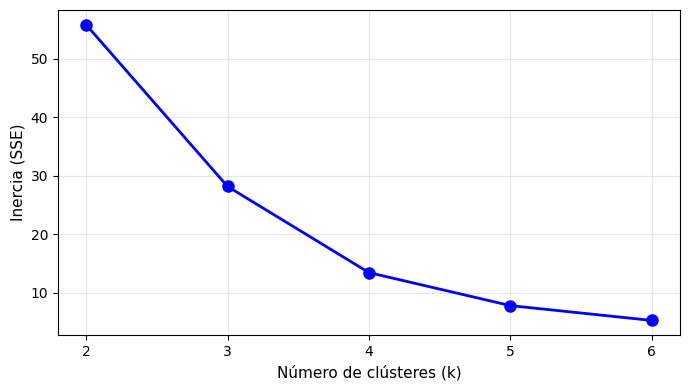

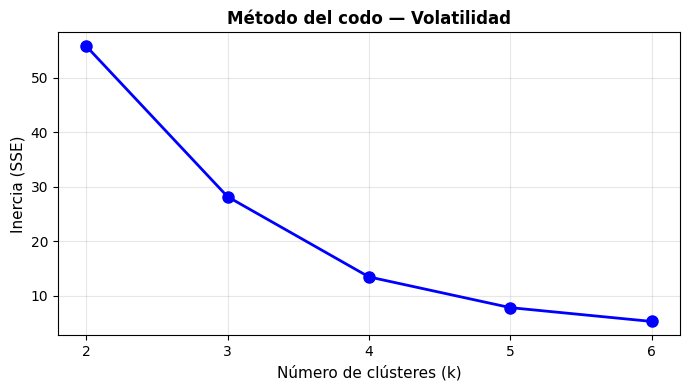

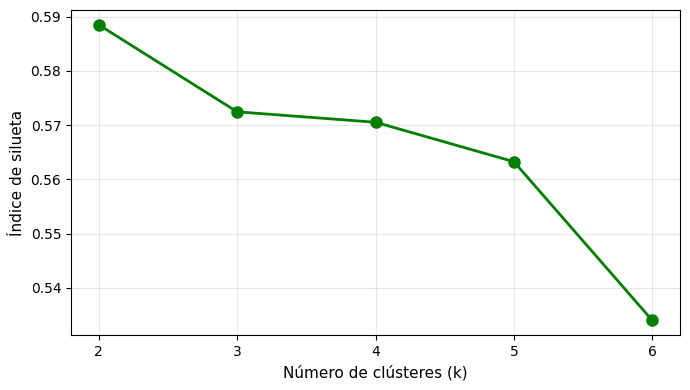

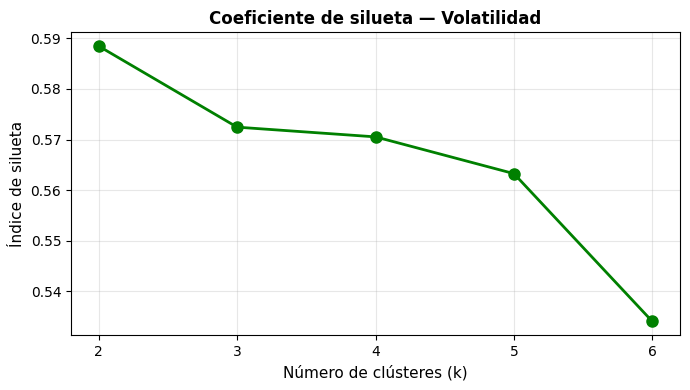

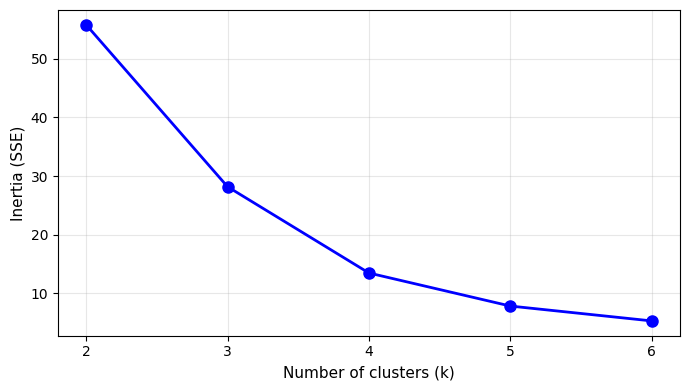

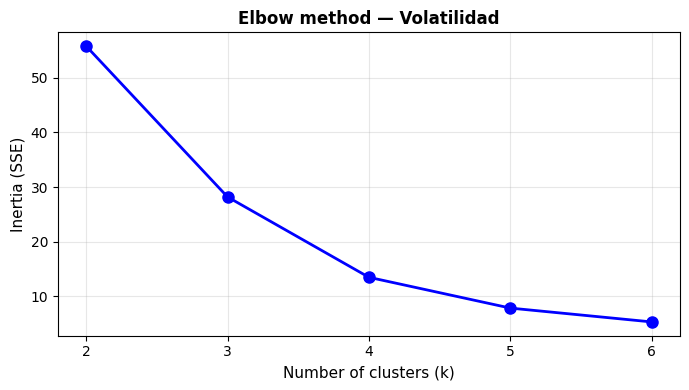

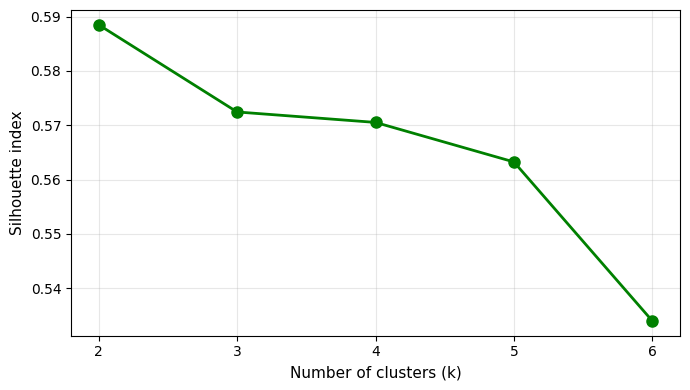

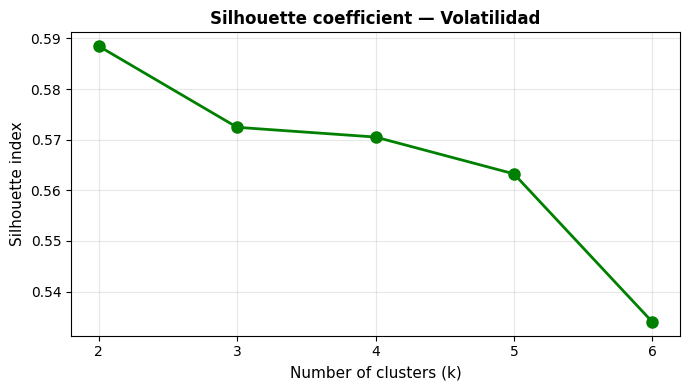

  ✓ 8 figuras guardadas: volatilidad_codo_*.pdf | volatilidad_silhouette_*.pdf

Estadísticas de cv_produccion:
count    489.000000
mean       0.752486
std        0.479972
min        0.104346
25%        0.444392
50%        0.681544
75%        0.957024
max        4.523508
Name: cv_produccion, dtype: float64


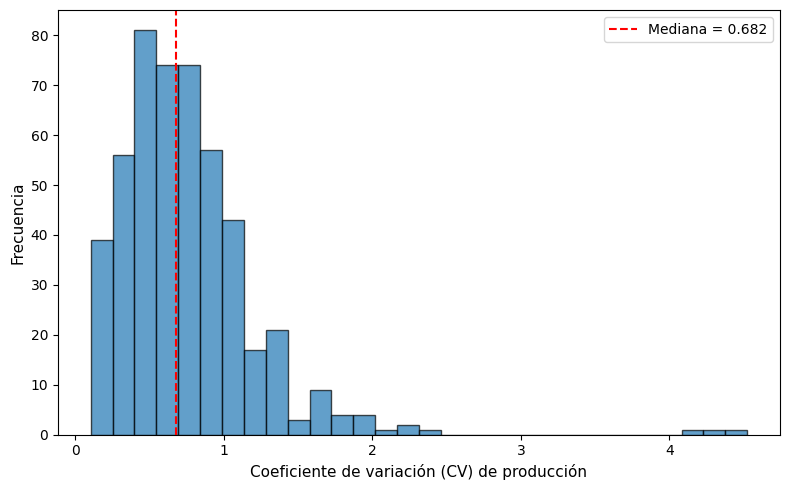

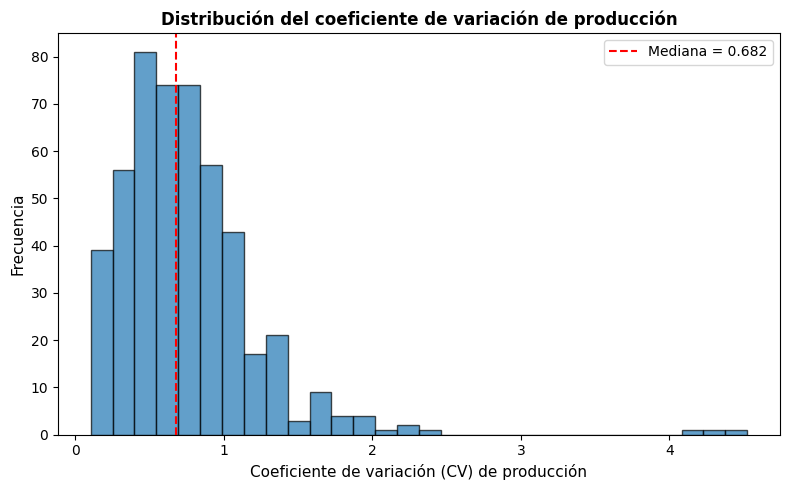

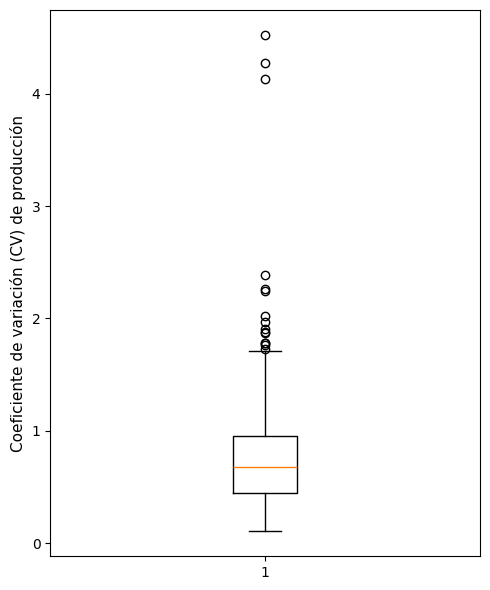

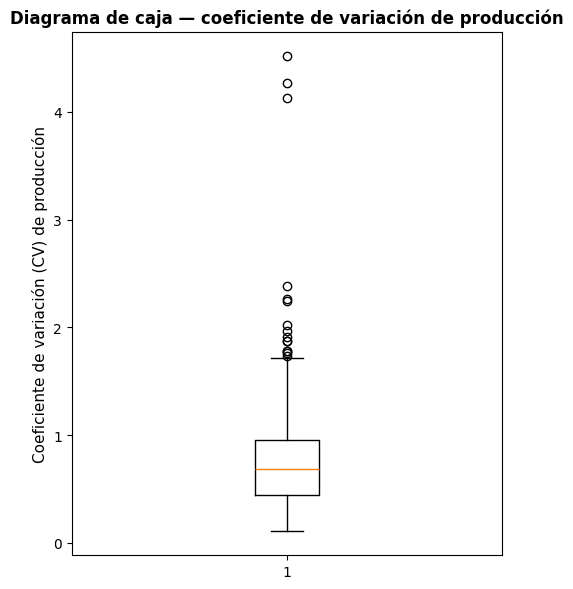

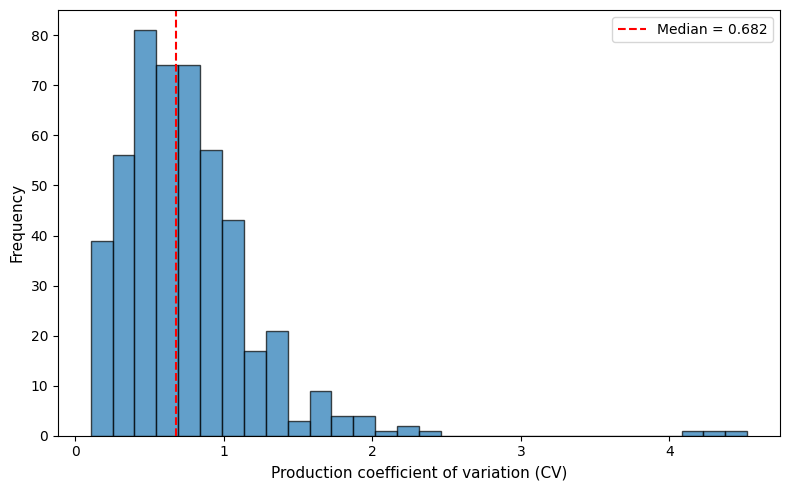

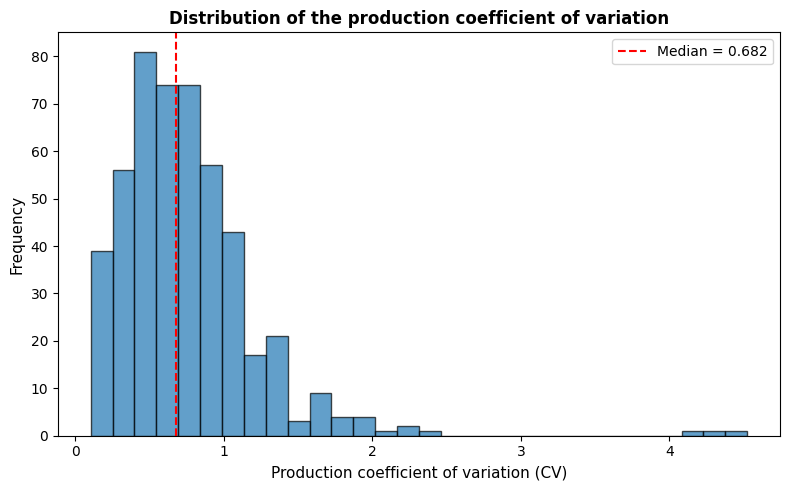

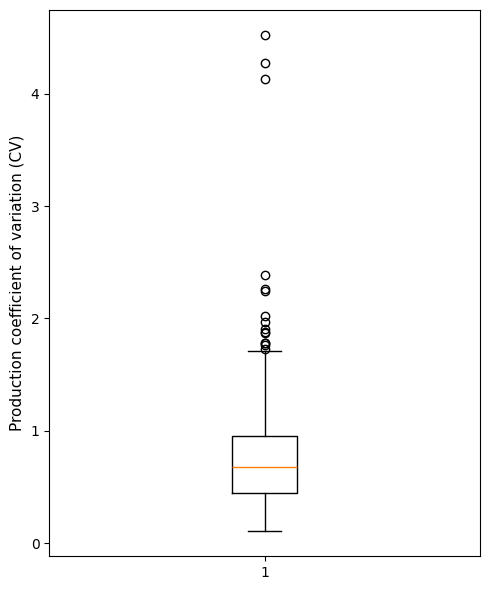

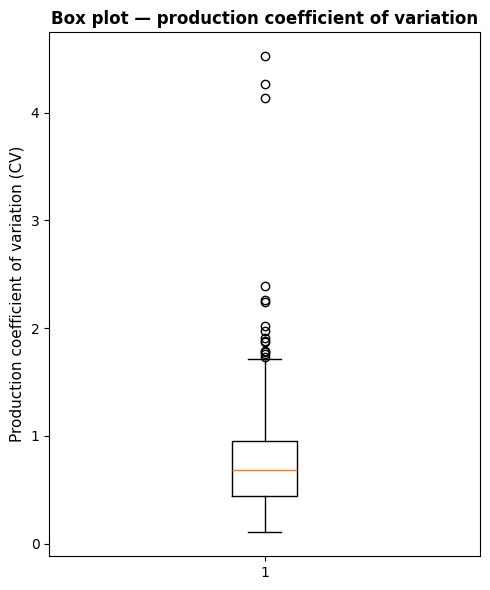

✓ 8 figuras guardadas en 'figures_clustering/'
  volatilidad_hist_cv_es.pdf / volatilidad_hist_cv_title_es.pdf
  volatilidad_boxplot_cv_en.pdf  / volatilidad_boxplot_cv_title_en.pdf  ...


In [32]:
# ==============================================================================
# DIMENSIÓN 1: VOLATILIDAD
# ==============================================================================

print("\n" + "=" * 80)
print("DIMENSIÓN 1: VOLATILIDAD")
print("=" * 80)

# ── Análisis y selección de k (genera sus propias figuras) ────────────────────
res_volatilidad = analizar_dimension(df_analisis, 'Volatilidad', dimensiones['Volatilidad'])
visualizar_seleccion_k(res_volatilidad)

# ── Estadísticas en consola ───────────────────────────────────────────────────
print("\nEstadísticas de cv_produccion:")
print(df_analisis['cv_produccion'].describe())

# ── Variantes de texto ────────────────────────────────────────────────────────
mediana_cv = df_analisis['cv_produccion'].median()

LABELS_HIST = {
    'es': {
        'xlabel':       'Coeficiente de variación (CV) de producción',
        'ylabel':       'Frecuencia',
        'label_med':    f'Mediana = {mediana_cv:.3f}',
        'title':        'Distribución del coeficiente de variación de producción',
    },
    'en': {
        'xlabel':       'Production coefficient of variation (CV)',
        'ylabel':       'Frequency',
        'label_med':    f'Median = {mediana_cv:.3f}',
        'title':        'Distribution of the production coefficient of variation',
    },
}

LABELS_BOX = {
    'es': {
        'ylabel': 'Coeficiente de variación (CV) de producción',
        'title':  'Diagrama de caja — coeficiente de variación de producción',
    },
    'en': {
        'ylabel': 'Production coefficient of variation (CV)',
        'title':  'Box plot — production coefficient of variation',
    },
}

BASE_HIST = "volatilidad_hist_cv"
BASE_BOX  = "volatilidad_boxplot_cv"

# ── Función histograma ────────────────────────────────────────────────────────
def plot_hist_cv(xlabel, ylabel, label_med, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_analisis['cv_produccion'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mediana_cv, color='red', linestyle='--', label=label_med)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Función boxplot ───────────────────────────────────────────────────────────
def plot_box_cv(ylabel, title=None):
    fig, ax = plt.subplots(figsize=(5, 6))
    ax.boxplot(df_analisis['cv_produccion'], vert=True)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Generar las 8 figuras (2 tipos × 2 idiomas × 2 variantes) ────────────────
total = 0
for lang in ['es', 'en']:
    lh = LABELS_HIST[lang]
    lb = LABELS_BOX[lang]

    plot_hist_cv(lh['xlabel'], lh['ylabel'], lh['label_med'])
    save_fig(f"{BASE_HIST}_{lang}")
    plt.show()

    plot_hist_cv(lh['xlabel'], lh['ylabel'], lh['label_med'], title=lh['title'])
    save_fig(f"{BASE_HIST}_title_{lang}")
    plt.show()

    plot_box_cv(lb['ylabel'])
    save_fig(f"{BASE_BOX}_{lang}")
    plt.show()

    plot_box_cv(lb['ylabel'], title=lb['title'])
    save_fig(f"{BASE_BOX}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_HIST}_es.pdf / {BASE_HIST}_title_es.pdf")
print(f"  {BASE_BOX}_en.pdf  / {BASE_BOX}_title_en.pdf  ...")

CLUSTERING DE VOLATILIDAD
k = 3, Silhouette = 0.5724

Distribución:
volatilidad
Estable     324
Moderada    162
Volátil       3
Name: count, dtype: int64


Estadísticas por grupo:
------------------------------------------------------------

Estable (n=324):
  CV mín: 0.104, máx: 0.833, media: 0.513

Moderada (n=162):
  CV mín: 0.841, máx: 2.388, media: 1.166

Volátil (n=3):
  CV mín: 4.133, máx: 4.524, media: 4.309


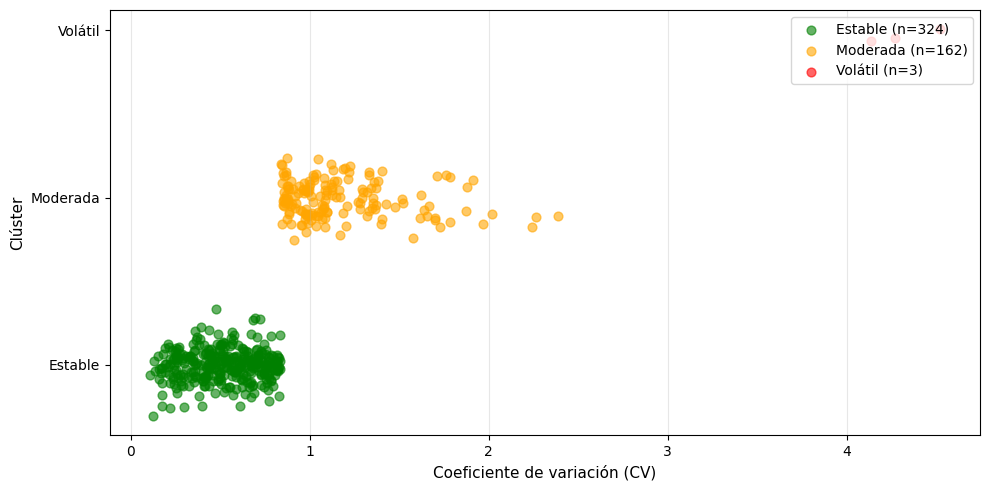

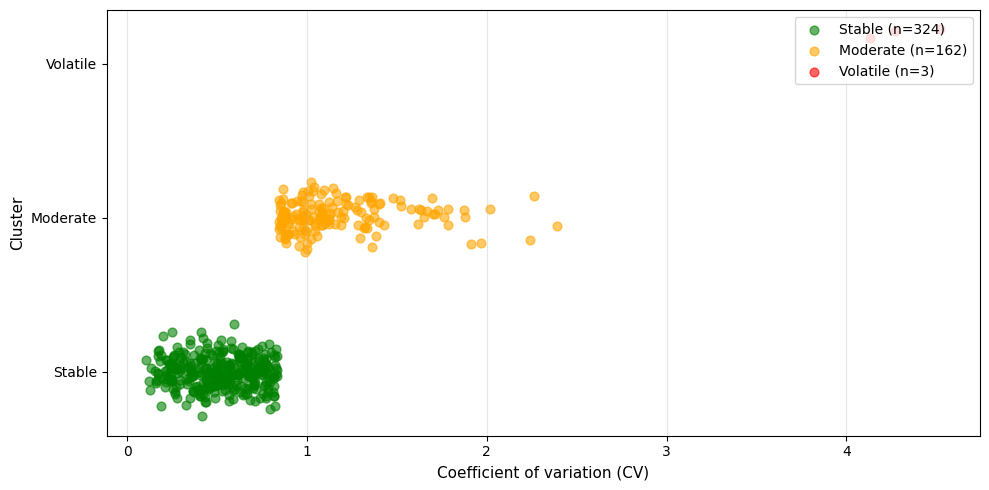

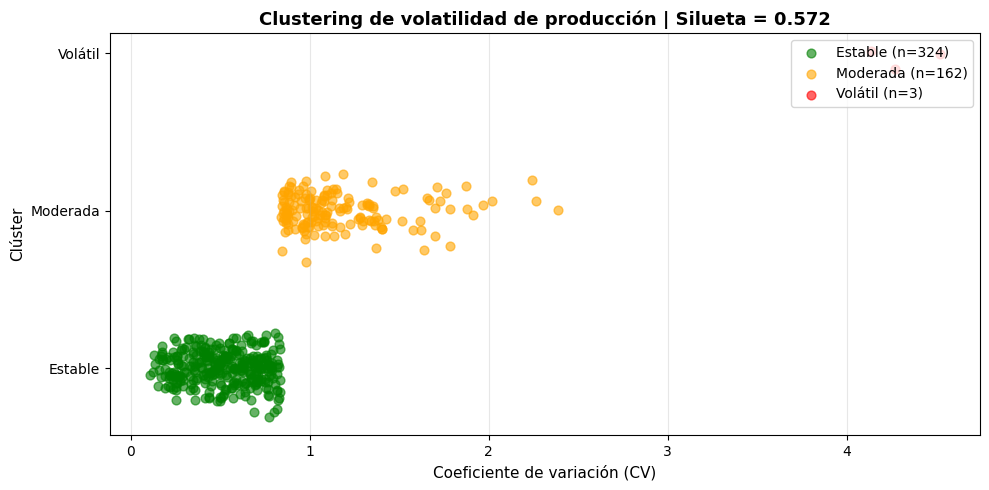

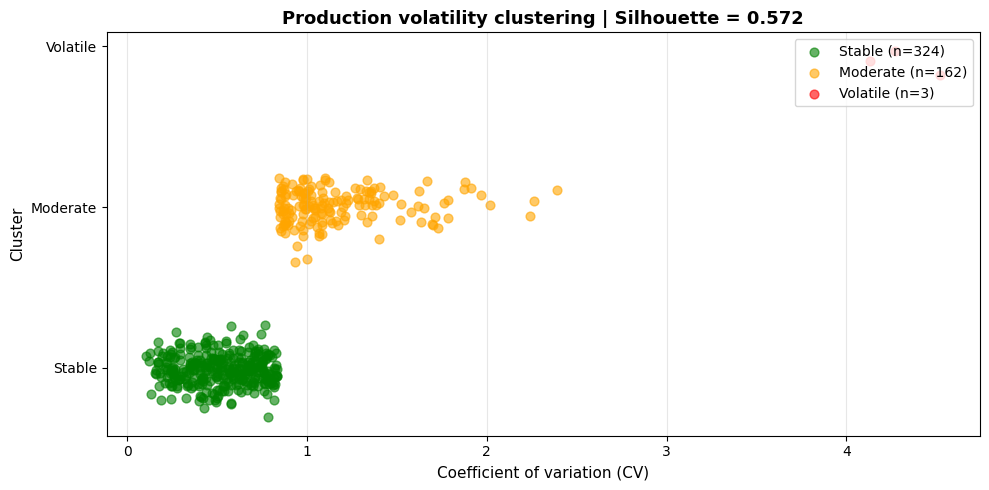

✓ 4 versiones guardadas en 'figures_clustering/':
   volatilidad_clustering_distribucion_es.pdf
   volatilidad_clustering_distribucion_en.pdf
   volatilidad_clustering_distribucion_title_es.pdf
   volatilidad_clustering_distribucion_title_en.pdf


In [34]:
# ==============================================================================
# APLICAR CLUSTERING - VOLATILIDAD
# ==============================================================================

k_volatilidad = 3  # Estable / Moderada / Volátil

labels_vol, sil_vol, kmeans_vol = aplicar_clustering_dimension(
    df_analisis, res_volatilidad, k_volatilidad
)

etiquetas_vol = dimensiones['Volatilidad']['etiquetas_k3']
df_analisis['cluster_volatilidad'] = labels_vol
df_analisis['volatilidad']         = df_analisis['cluster_volatilidad'].map(etiquetas_vol)

# Etiquetas por idioma (mapeo desde índice de clúster)
etiquetas_vol_en = {
    i: {'Estable': 'Stable', 'Moderada': 'Moderate', 'Volátil': 'Volatile'}[etiquetas_vol[i]]
    for i in range(k_volatilidad)
}

# ── Resumen en consola ────────────────────────────────────────────────────────
print("CLUSTERING DE VOLATILIDAD")
print("=" * 80)
print(f"k = {k_volatilidad}, Silhouette = {sil_vol:.4f}\n")
print("Distribución:")
print(df_analisis['volatilidad'].value_counts().sort_index())
print("\n\nEstadísticas por grupo:")
print("-" * 60)
for label in sorted(df_analisis['cluster_volatilidad'].unique()):
    grupo = df_analisis[df_analisis['cluster_volatilidad'] == label]
    cv    = grupo['cv_produccion']
    print(f"\n{etiquetas_vol[label]} (n={len(grupo)}):")
    print(f"  CV mín: {cv.min():.3f}, máx: {cv.max():.3f}, media: {cv.mean():.3f}")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel': 'Coeficiente de variación (CV)',
        'ylabel': 'Clúster',
        'title':  f'Clustering de volatilidad de producción | Silueta = {sil_vol:.3f}',
    },
    'en': {
        'xlabel': 'Coefficient of variation (CV)',
        'ylabel': 'Cluster',
        'title':  f'Production volatility clustering | Silhouette = {sil_vol:.3f}',
    },
}
BASE   = "volatilidad_clustering_distribucion"
colors = ['green', 'orange', 'red']

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_volatilidad(xlabel, ylabel, lang, title=None):
    etiq = etiquetas_vol if lang == 'es' else etiquetas_vol_en
    fig, ax = plt.subplots(figsize=(10, 5))
    for i in range(k_volatilidad):
        mask  = df_analisis['cluster_volatilidad'] == i
        datos = df_analisis.loc[mask, 'cv_produccion']
        ax.scatter(datos, np.random.normal(i, 0.1, size=len(datos)),
                   c=colors[i], alpha=0.6,
                   label=f"{etiq[i]} (n={len(datos)})", s=40)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_yticks(range(k_volatilidad))
    ax.set_yticklabels([etiq[i] for i in range(k_volatilidad)])
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3, axis='x')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── 1. Sin título — español ───────────────────────────────────────────────────
plot_volatilidad(**{k: v for k, v in LABELS['es'].items() if k != 'title'}, lang='es')
save_fig(f"{BASE}_es")
plt.show()

# ── 2. Sin título — inglés ────────────────────────────────────────────────────
plot_volatilidad(**{k: v for k, v in LABELS['en'].items() if k != 'title'}, lang='en')
save_fig(f"{BASE}_en")
plt.show()

# ── 3. Con título — español ───────────────────────────────────────────────────
plot_volatilidad(**LABELS['es'], lang='es')
save_fig(f"{BASE}_title_es")
plt.show()

# ── 4. Con título — inglés ────────────────────────────────────────────────────
plot_volatilidad(**LABELS['en'], lang='en')
save_fig(f"{BASE}_title_en")
plt.show()

print(f"✓ 4 versiones guardadas en '{OUT_DIR}/':")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

In [35]:
# ==============================================================================
# DETALLE DE PARES POR CLUSTER - VOLATILIDAD
# ==============================================================================

print("DETALLE DE PARES - VOLATILIDAD")
print("=" * 80)

for etiqueta in ['Estable', 'Moderada', 'Volátil']:
    grupo = df_analisis[df_analisis['volatilidad'] == etiqueta].copy()
    grupo = grupo.sort_values('cv_produccion', ascending=(etiqueta == 'Estable'))
    
    print(f"\n\n{'='*80}")
    print(f"{etiqueta.upper()} (n={len(grupo)})")
    print(f"CV rango: {grupo['cv_produccion'].min():.3f} - {grupo['cv_produccion'].max():.3f}")
    print(f"CV media: {grupo['cv_produccion'].mean():.3f}")
    print("="*80)
    
    # Mostrar todos o los primeros/últimos según tamaño
    if len(grupo) <= 30:
        print(f"\nTodos los pares:")
        print(grupo[['departamento', 'cultivo', 'cv_produccion', 'escala_productiva']].to_string(index=False))
    else:
        print(f"\nPrimeros 15 pares (menor CV en el grupo):")
        print(grupo[['departamento', 'cultivo', 'cv_produccion', 'escala_productiva']].head(15).to_string(index=False))
        print(f"\n... ({len(grupo) - 30} pares intermedios omitidos) ...")
        print(f"\nÚltimos 15 pares (mayor CV en el grupo):")
        print(grupo[['departamento', 'cultivo', 'cv_produccion', 'escala_productiva']].tail(15).to_string(index=False))

# Cruce con escala productiva
print("\n\n" + "=" * 80)
print("TABLA CRUZADA: VOLATILIDAD × ESCALA PRODUCTIVA")
print("=" * 80)
tabla_vol = pd.crosstab(df_analisis['volatilidad'], df_analisis['escala_productiva'], margins=True)
print(tabla_vol)

# Porcentajes por escala
print("\n\nPorcentaje por escala productiva:")
tabla_vol_pct = pd.crosstab(df_analisis['volatilidad'], df_analisis['escala_productiva'], normalize='columns') * 100
print(tabla_vol_pct.round(1))

DETALLE DE PARES - VOLATILIDAD


ESTABLE (n=324)
CV rango: 0.104 - 0.833
CV media: 0.513

Primeros 15 pares (menor CV en el grupo):
      departamento    cultivo  cv_produccion escala_productiva
            tolima      arroz       0.104346            Grande
   valle del cauca     frijol       0.120805           Pequeña
norte de santander     frijol       0.127513           Pequeña
             huila     frijol       0.132079           Pequeña
         antioquia       papa       0.152073           Mediana
             huila      arroz       0.159493           Mediana
   valle del cauca habichuela       0.159568           Pequeña
             huila     tomate       0.168502           Pequeña
            boyaca       papa       0.169561            Grande
             huila       maiz       0.171848           Mediana
norte de santander    brocoli       0.172104           Pequeña
norte de santander  remolacha       0.172421           Pequeña
      cundinamarca    girasol       0.174298     

### Tendencia


DIMENSIÓN 2: TENDENCIA

Tendencia - Resumen:
--------------------------------------------------
  k=2: Silhouette = 0.4484
  k=3: Silhouette = 0.5027
  k=4: Silhouette = 0.5245
  k=5: Silhouette = 0.4718
  k=6: Silhouette = 0.4788

  → Mejor k por Silhouette: 4


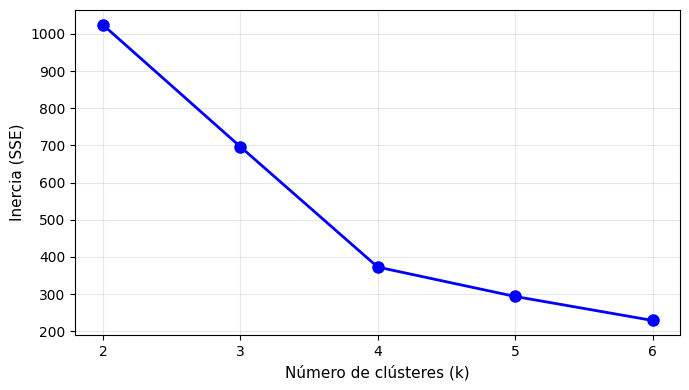

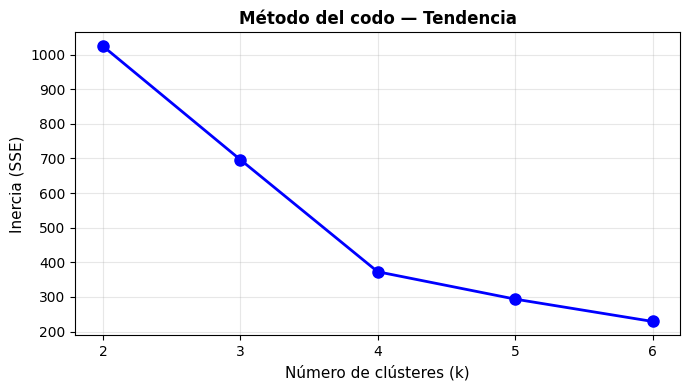

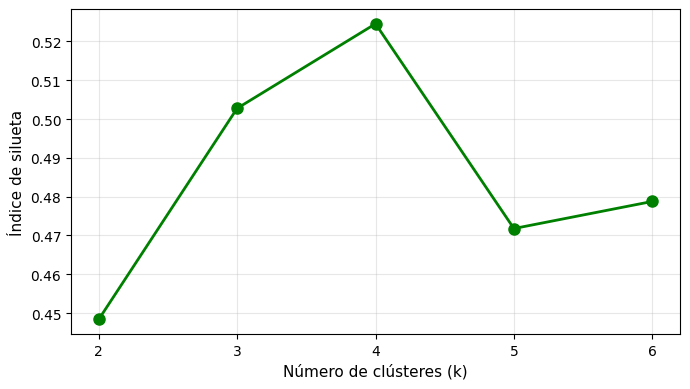

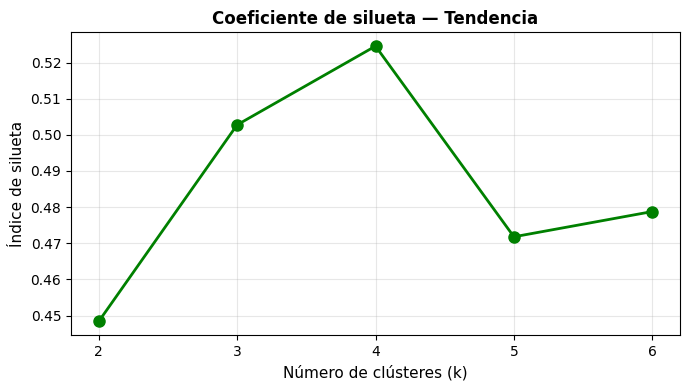

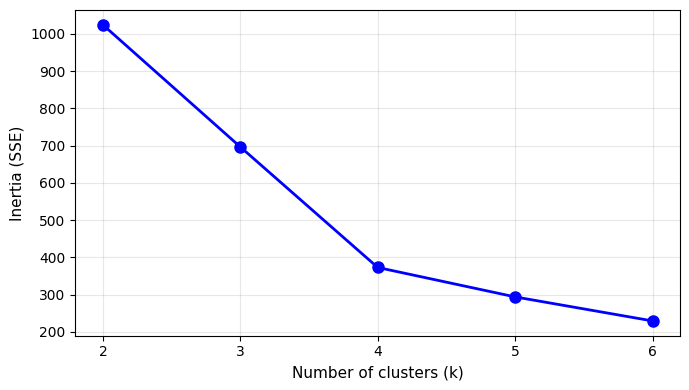

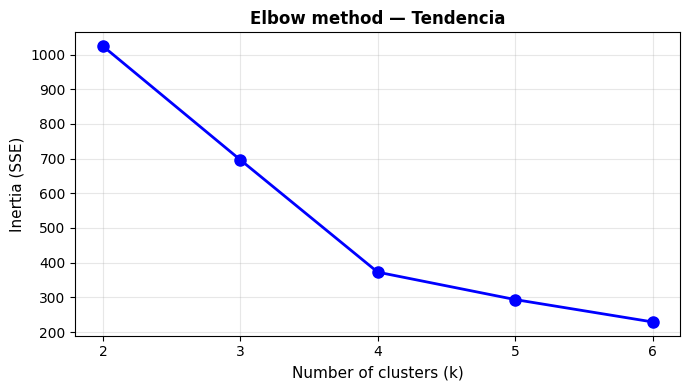

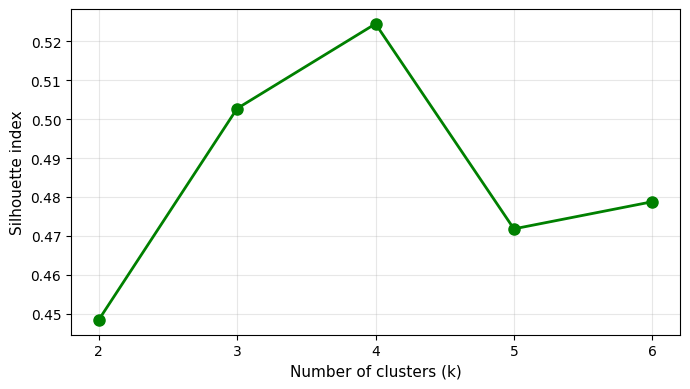

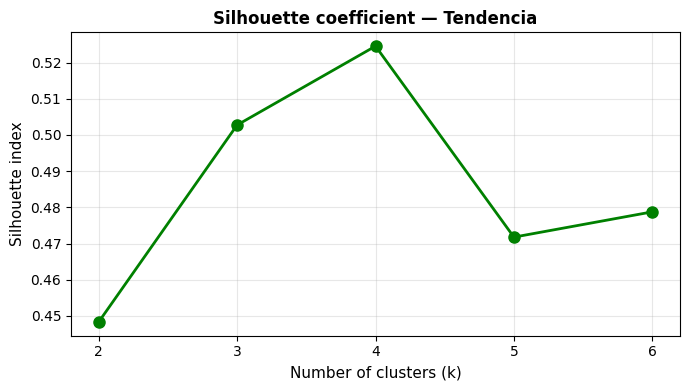

  ✓ 8 figuras guardadas: tendencia_codo_*.pdf | tendencia_silhouette_*.pdf

Correlaciones entre variables de tendencia:
                                tendencia_produccion_pendiente  \
tendencia_produccion_pendiente                           1.000   
tendencia_produccion_r2                                  0.078   
mk_tau_produccion                                        0.238   

                                tendencia_produccion_r2  mk_tau_produccion  
tendencia_produccion_pendiente                    0.078              0.238  
tendencia_produccion_r2                           1.000              0.118  
mk_tau_produccion                                 0.118              1.000  


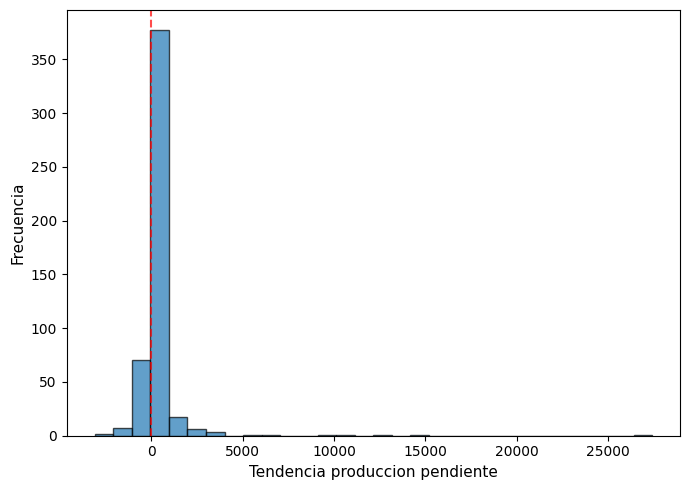

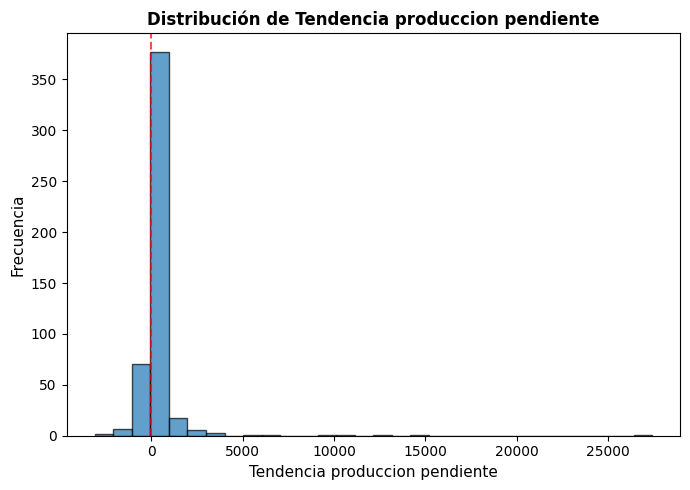

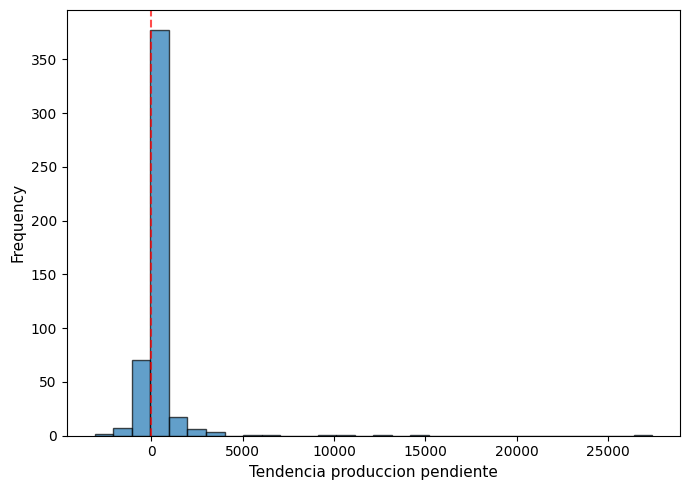

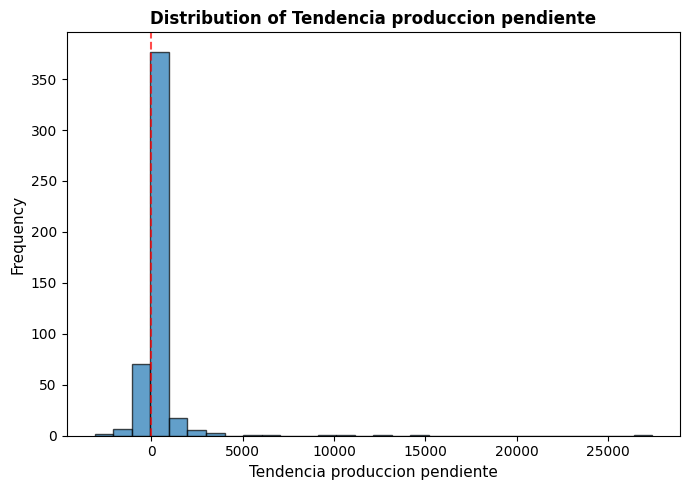

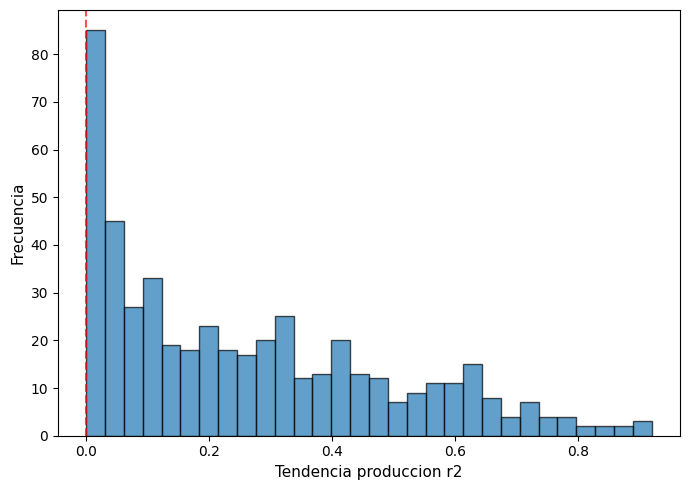

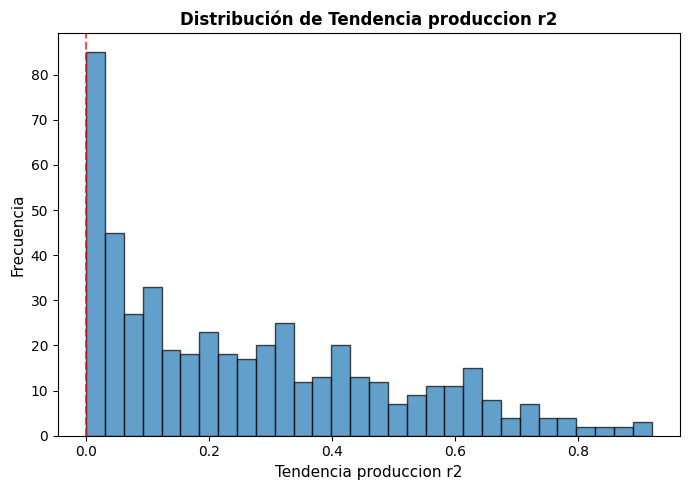

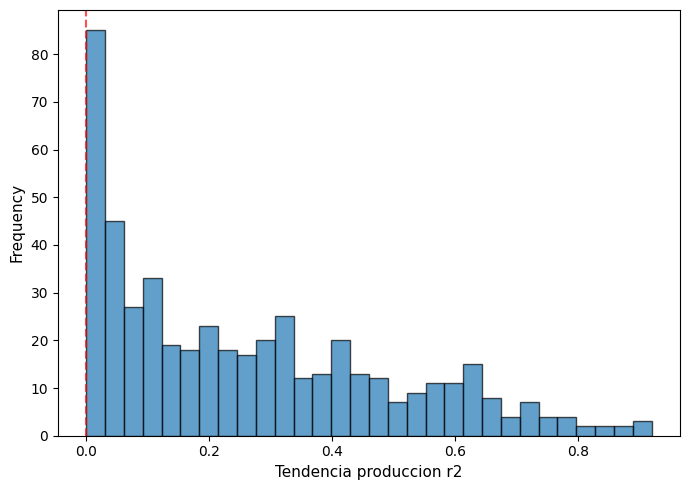

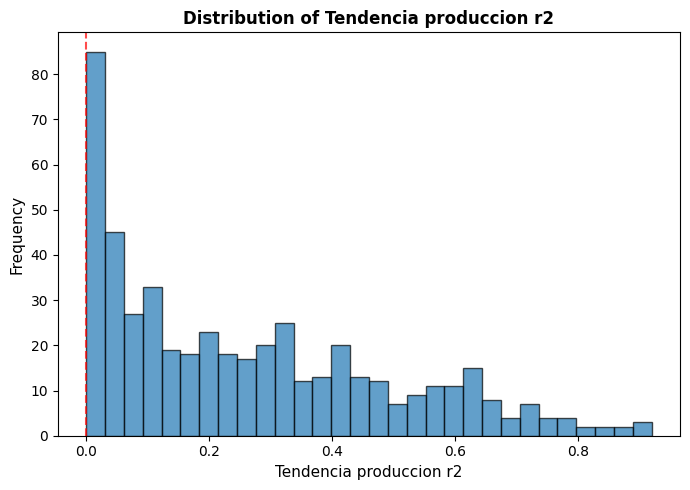

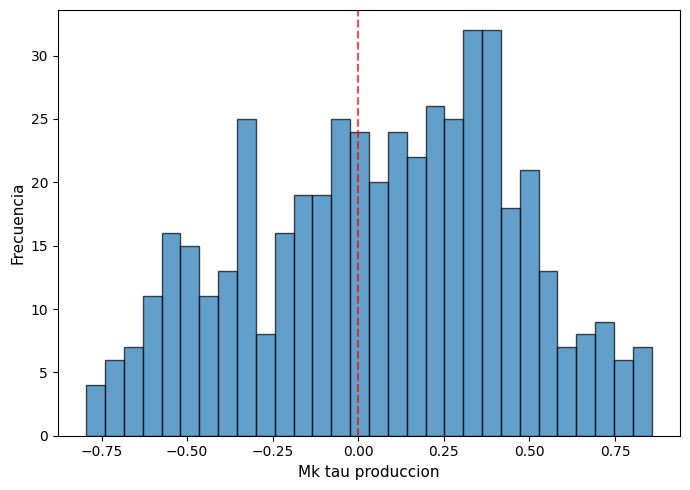

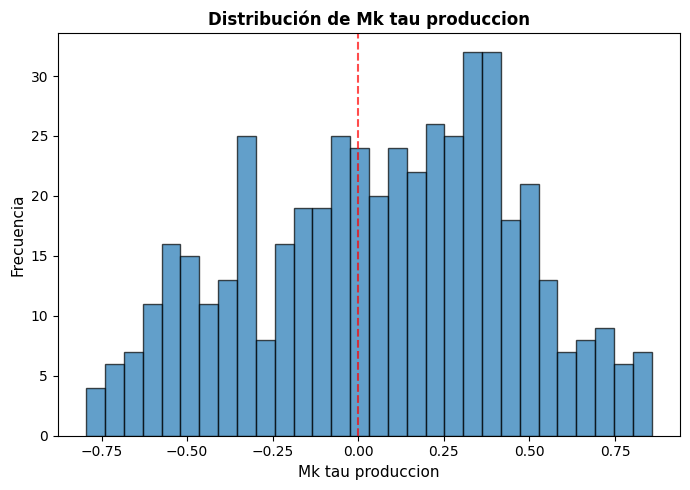

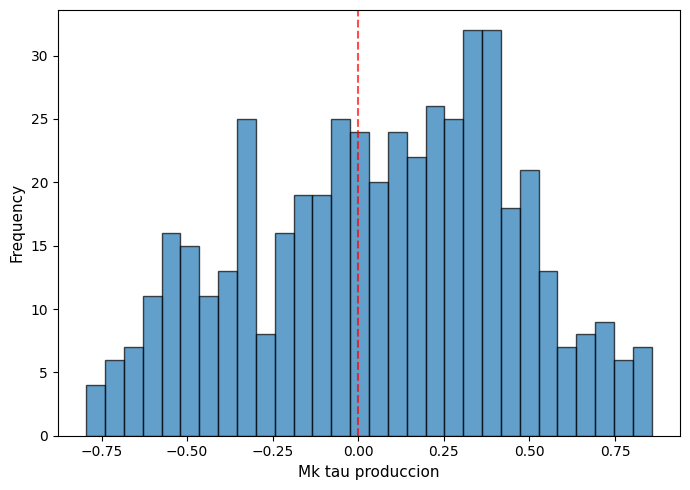

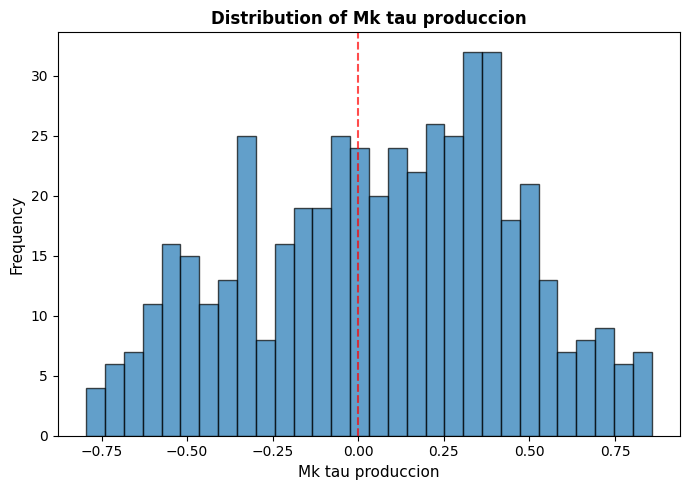

✓ 12 figuras guardadas en 'figures_clustering/'
  tendencia_hist_tendencia_produccion_pendiente_es.pdf / tendencia_hist_tendencia_produccion_pendiente_title_en.pdf  ...
  tendencia_hist_tendencia_produccion_r2_es.pdf / tendencia_hist_tendencia_produccion_r2_title_en.pdf  ...
  tendencia_hist_mk_tau_produccion_es.pdf / tendencia_hist_mk_tau_produccion_title_en.pdf  ...


In [36]:
# ==============================================================================
# DIMENSIÓN 2: TENDENCIA
# ==============================================================================

print("\n" + "=" * 80)
print("DIMENSIÓN 2: TENDENCIA")
print("=" * 80)

# ── Análisis y selección de k (genera sus propias figuras) ────────────────────
res_tendencia = analizar_dimension(df_analisis, 'Tendencia', dimensiones['Tendencia'])
visualizar_seleccion_k(res_tendencia)

# ── Estadísticas en consola ───────────────────────────────────────────────────
print("\nCorrelaciones entre variables de tendencia:")
print(df_analisis[dimensiones['Tendencia']['variables']].corr().round(3))

# ── Variantes de texto ────────────────────────────────────────────────────────
vars_tendencia = dimensiones['Tendencia']['variables']

# Nombres legibles por variable
NOMBRES_VAR = {
    'es': {v: v.replace('_', ' ').capitalize() for v in vars_tendencia},
    'en': {v: v.replace('_', ' ').capitalize() for v in vars_tendencia},
}

LABELS_HIST = {
    'es': {
        'ylabel':   'Frecuencia',
    },
    'en': {
        'ylabel':   'Frequency',
    },
}

BASE_HIST = "tendencia_hist"

# ── Función histograma por variable ──────────────────────────────────────────
def plot_hist_tendencia(var, ylabel, nombre_var, title=None):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(df_analisis[var], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', alpha=0.7)
    ax.set_xlabel(nombre_var, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Generar figuras por variable (2 vars × 2 idiomas × 2 variantes = 8) ──────
total = 0
for var in vars_tendencia:
    for lang in ['es', 'en']:
        lh       = LABELS_HIST[lang]
        nom_var  = NOMBRES_VAR[lang][var]
        base     = f"{BASE_HIST}_{var}"
        title_full = f"Distribución de {nom_var}" if lang == 'es' \
                     else f"Distribution of {nom_var}"

        plot_hist_tendencia(var, lh['ylabel'], nom_var)
        save_fig(f"{base}_{lang}")
        plt.show()

        plot_hist_tendencia(var, lh['ylabel'], nom_var,
                            title=title_full)
        save_fig(f"{base}_title_{lang}")
        plt.show()

        total += 2

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
for var in vars_tendencia:
    print(f"  {BASE_HIST}_{var}_es.pdf / {BASE_HIST}_{var}_title_en.pdf  ...")

CLUSTERING DE TENDENCIA
k = 3, Silhouette = 0.5027

Distribución:
tendencia
Creciente      117
Decreciente     94
Estable        278
Name: count, dtype: int64


Estadísticas por grupo:
--------------------------------------------------------------------------------

Decreciente (n=94):
  Pendiente - media: -259.10
  R² - media:        0.458
  Tau MK - media:    -0.505

Estable (n=278):
  Pendiente - media: 24.58
  R² - media:        0.092
  Tau MK - media:    0.058

Creciente (n=117):
  Pendiente - media: 1198.07
  R² - media:        0.501
  Tau MK - media:    0.532


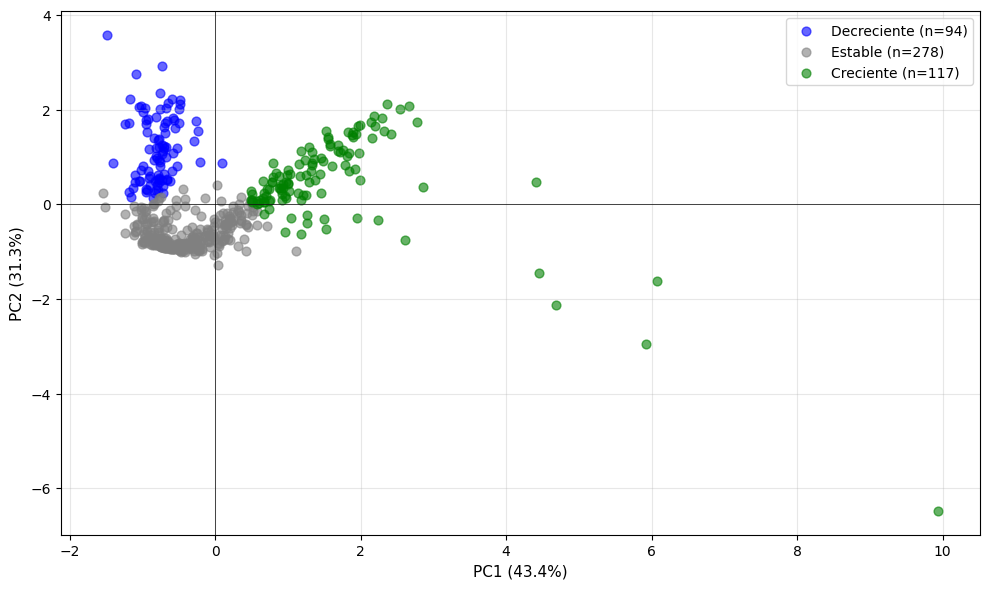

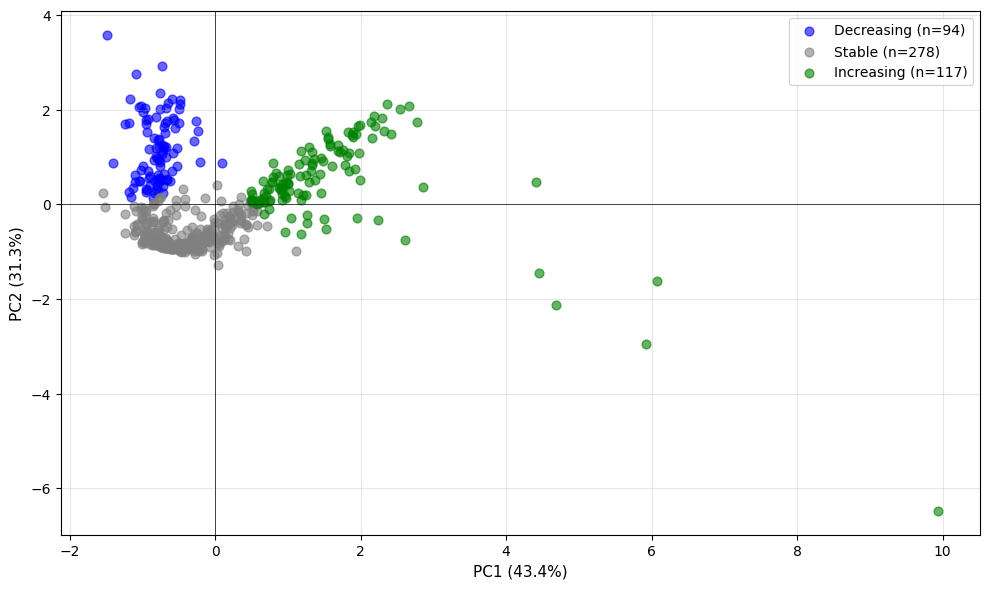

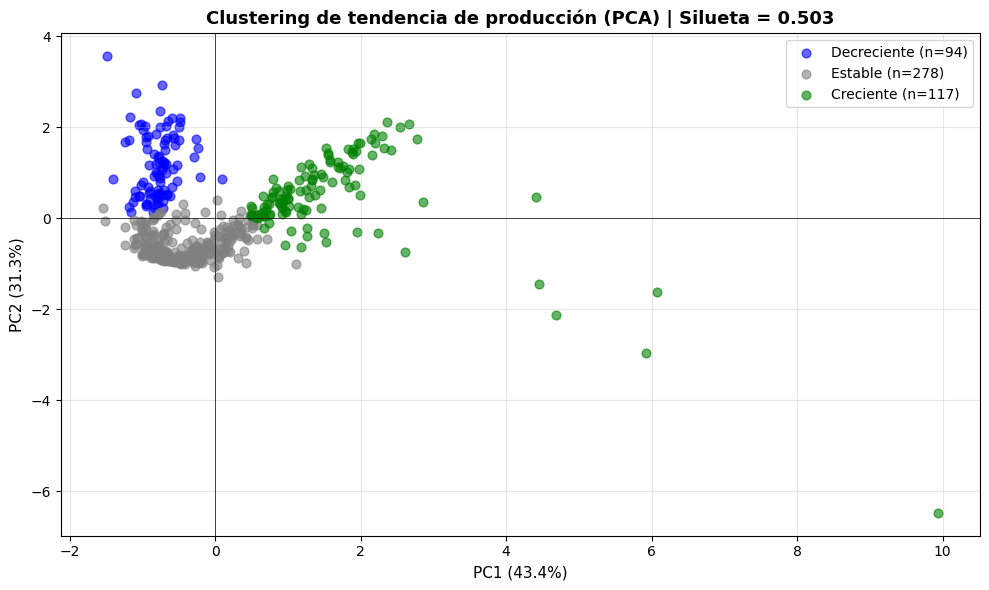

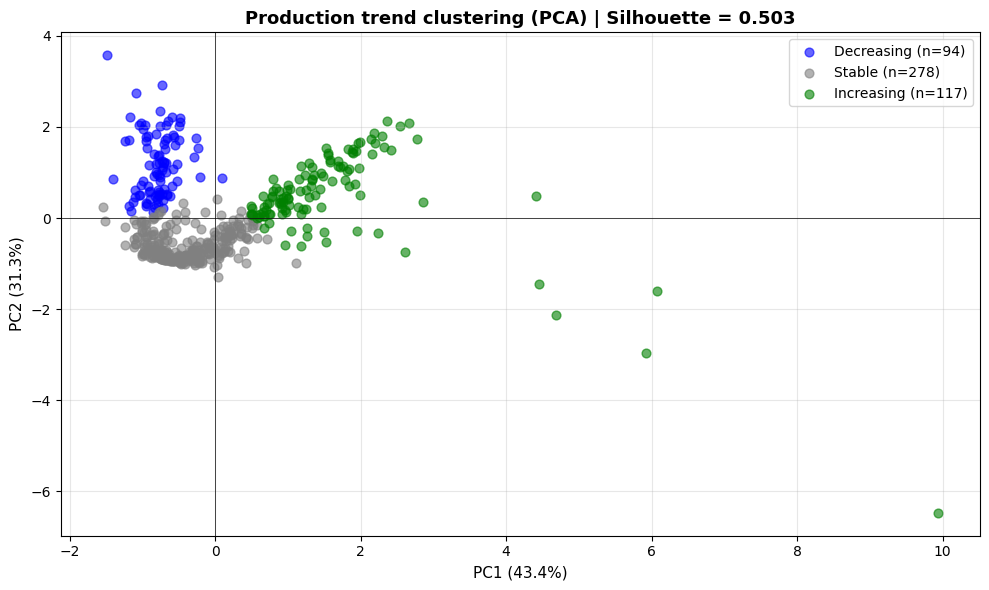

✓ 4 versiones guardadas en 'figures_clustering/':
   tendencia_pca_clustering_es.pdf
   tendencia_pca_clustering_en.pdf
   tendencia_pca_clustering_title_es.pdf
   tendencia_pca_clustering_title_en.pdf


In [38]:
# ==============================================================================
# APLICAR CLUSTERING - TENDENCIA
# ==============================================================================

from sklearn.decomposition import PCA

k_tendencia = 3  # Decreciente / Estable / Creciente

labels_tend, sil_tend, kmeans_tend = aplicar_clustering_dimension(
    df_analisis, res_tendencia, k_tendencia, ordenar_por='media'
)

etiquetas_tend = dimensiones['Tendencia']['etiquetas_k3']
df_analisis['cluster_tendencia'] = labels_tend
df_analisis['tendencia']         = df_analisis['cluster_tendencia'].map(etiquetas_tend)

# Etiquetas en inglés
etiquetas_tend_en = {
    i: {'Decreciente': 'Decreasing', 'Estable': 'Stable',
        'Creciente': 'Increasing'}[etiquetas_tend[i]]
    for i in range(k_tendencia)
}

# ── Resumen en consola ────────────────────────────────────────────────────────
print("CLUSTERING DE TENDENCIA")
print("=" * 80)
print(f"k = {k_tendencia}, Silhouette = {sil_tend:.4f}\n")
print("Distribución:")
print(df_analisis['tendencia'].value_counts().sort_index())
print("\n\nEstadísticas por grupo:")
print("-" * 80)
for label in sorted(df_analisis['cluster_tendencia'].unique()):
    grupo = df_analisis[df_analisis['cluster_tendencia'] == label]
    print(f"\n{etiquetas_tend[label]} (n={len(grupo)}):")
    print(f"  Pendiente - media: {grupo['tendencia_produccion_pendiente'].mean():.2f}")
    print(f"  R² - media:        {grupo['tendencia_produccion_r2'].mean():.3f}")
    print(f"  Tau MK - media:    {grupo['mk_tau_produccion'].mean():.3f}")

# ── PCA ───────────────────────────────────────────────────────────────────────
X_tend        = df_analisis[dimensiones['Tendencia']['variables']].values
X_tend_scaled = StandardScaler().fit_transform(X_tend)
pca           = PCA(n_components=2)
X_pca         = pca.fit_transform(X_tend_scaled)
var_pc1       = pca.explained_variance_ratio_[0] * 100
var_pc2       = pca.explained_variance_ratio_[1] * 100

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel': f'PC1 ({var_pc1:.1f}%)',
        'ylabel': f'PC2 ({var_pc2:.1f}%)',
        'title':  f'Clustering de tendencia de producción (PCA) | Silueta = {sil_tend:.3f}',
    },
    'en': {
        'xlabel': f'PC1 ({var_pc1:.1f}%)',
        'ylabel': f'PC2 ({var_pc2:.1f}%)',
        'title':  f'Production trend clustering (PCA) | Silhouette = {sil_tend:.3f}',
    },
}
BASE   = "tendencia_pca_clustering"
colors = ['blue', 'gray', 'green']

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_tendencia_pca(xlabel, ylabel, lang, title=None):
    etiq = etiquetas_tend if lang == 'es' else etiquetas_tend_en
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(k_tendencia):
        mask = df_analisis['cluster_tendencia'] == i
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[i], alpha=0.6,
                   label=f"{etiq[i]} (n={mask.sum()})", s=40)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── 1. Sin título — español ───────────────────────────────────────────────────
plot_tendencia_pca(**{k: v for k, v in LABELS['es'].items() if k != 'title'}, lang='es')
save_fig(f"{BASE}_es")
plt.show()

# ── 2. Sin título — inglés ────────────────────────────────────────────────────
plot_tendencia_pca(**{k: v for k, v in LABELS['en'].items() if k != 'title'}, lang='en')
save_fig(f"{BASE}_en")
plt.show()

# ── 3. Con título — español ───────────────────────────────────────────────────
plot_tendencia_pca(**LABELS['es'], lang='es')
save_fig(f"{BASE}_title_es")
plt.show()

# ── 4. Con título — inglés ────────────────────────────────────────────────────
plot_tendencia_pca(**LABELS['en'], lang='en')
save_fig(f"{BASE}_title_en")
plt.show()

print(f"✓ 4 versiones guardadas en '{OUT_DIR}/':")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

In [39]:
# ==============================================================================
# DETALLE DE PARES POR CLUSTER - TENDENCIA
# ==============================================================================

print("DETALLE DE PARES - TENDENCIA")
print("=" * 80)

for etiqueta in ['Decreciente', 'Estable', 'Creciente']:
    grupo = df_analisis[df_analisis['tendencia'] == etiqueta].copy()
    grupo = grupo.sort_values('tendencia_produccion_pendiente', ascending=False)
    
    print(f"\n\n{'='*80}")
    print(f"{etiqueta.upper()} (n={len(grupo)})")
    print(f"Pendiente rango: {grupo['tendencia_produccion_pendiente'].min():.2f} - {grupo['tendencia_produccion_pendiente'].max():.2f}")
    print(f"Pendiente media: {grupo['tendencia_produccion_pendiente'].mean():.2f}")
    print(f"R² media: {grupo['tendencia_produccion_r2'].mean():.3f}")
    print(f"Tau MK media: {grupo['mk_tau_produccion'].mean():.3f}")
    print("="*80)
    
    # Mostrar todos o los primeros/últimos según tamaño
    cols_mostrar = ['departamento', 'cultivo', 'tendencia_produccion_pendiente', 
                    'tendencia_produccion_r2', 'mk_tau_produccion', 'escala_productiva']
    
    if len(grupo) <= 30:
        print(f"\nTodos los pares:")
        print(grupo[cols_mostrar].to_string(index=False))
    else:
        print(f"\nPrimeros 15 pares (mayor pendiente en el grupo):")
        print(grupo[cols_mostrar].head(15).to_string(index=False))
        print(f"\n... ({len(grupo) - 30} pares intermedios omitidos) ...")
        print(f"\nÚltimos 15 pares (menor pendiente en el grupo):")
        print(grupo[cols_mostrar].tail(15).to_string(index=False))

# Cruce con escala productiva
print("\n\n" + "=" * 80)
print("TABLA CRUZADA: TENDENCIA × ESCALA PRODUCTIVA")
print("=" * 80)
tabla_tend = pd.crosstab(df_analisis['tendencia'], df_analisis['escala_productiva'], margins=True)
print(tabla_tend)

# Porcentajes por escala
print("\n\nPorcentaje por escala productiva:")
tabla_tend_pct = pd.crosstab(df_analisis['tendencia'], df_analisis['escala_productiva'], normalize='columns') * 100
print(tabla_tend_pct.round(1))

DETALLE DE PARES - TENDENCIA


DECRECIENTE (n=94)
Pendiente rango: -3120.51 - -0.52
Pendiente media: -259.10
R² media: 0.458
Tau MK media: -0.505

Primeros 15 pares (mayor pendiente en el grupo):
      departamento         cultivo  tendencia_produccion_pendiente  tendencia_produccion_r2  mk_tau_produccion escala_productiva
         antioquia             ajo                       -0.523829                 0.227508          -0.349820           Pequeña
         risaralda          arveja                       -0.561553                 0.293870          -0.338103           Pequeña
             cauca            haba                       -0.777440                 0.536961          -0.352297           Pequeña
           quindio          arveja                       -0.897623                 0.250686          -0.432219           Pequeña
            caldas       remolacha                       -1.298269                 0.209131          -0.510645           Pequeña
norte de santander           t

### Estacionalidad


DIMENSIÓN 3: ESTACIONALIDAD

Estacionalidad - Resumen:
--------------------------------------------------
  k=2: Silhouette = 0.4690
  k=3: Silhouette = 0.4992
  k=4: Silhouette = 0.5005
  k=5: Silhouette = 0.4520
  k=6: Silhouette = 0.4270

  → Mejor k por Silhouette: 4


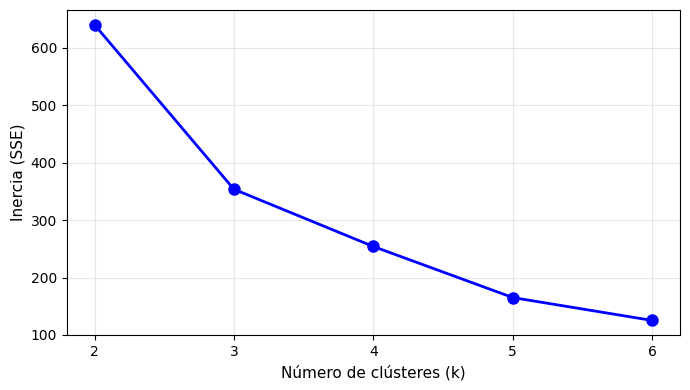

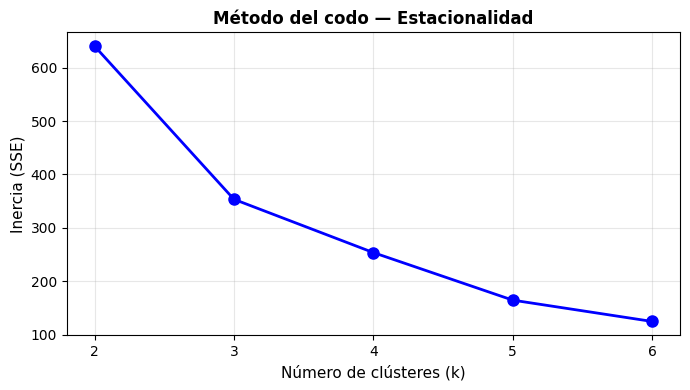

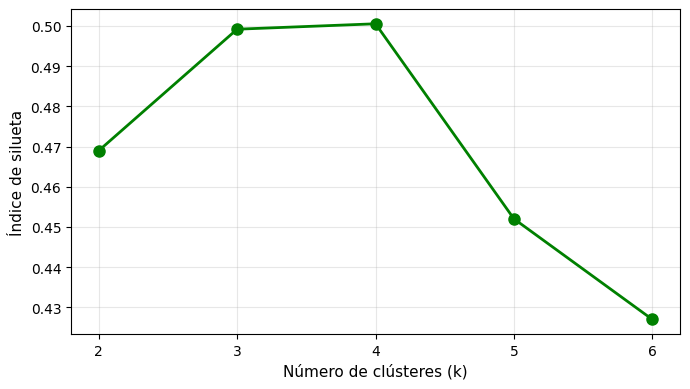

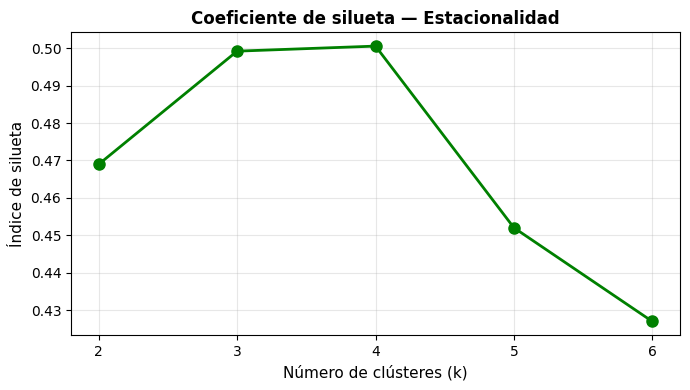

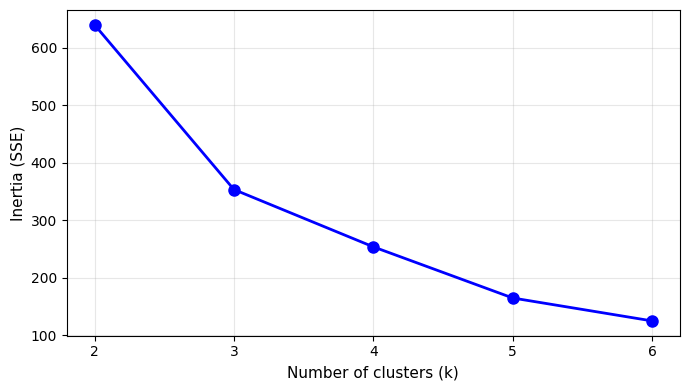

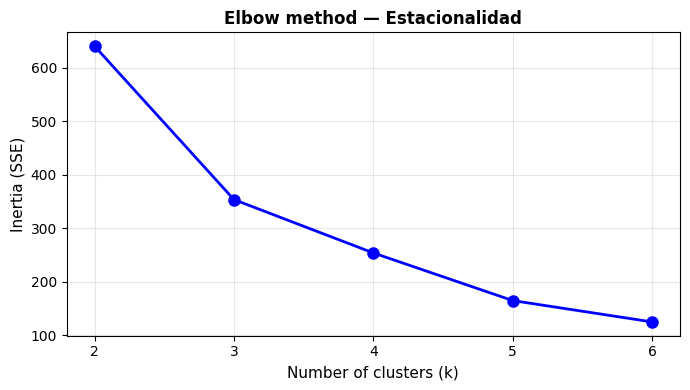

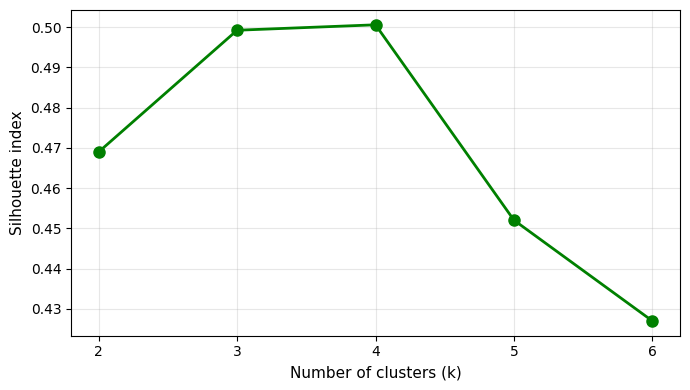

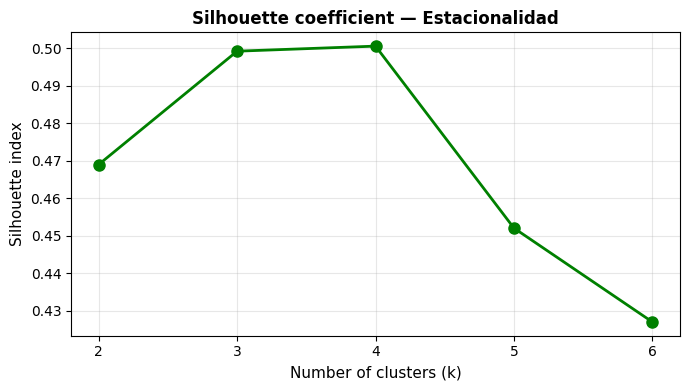

  ✓ 8 figuras guardadas: estacionalidad_codo_*.pdf | estacionalidad_silhouette_*.pdf

Correlación ratio_AB vs porcentaje_A_mayor_B: 0.169


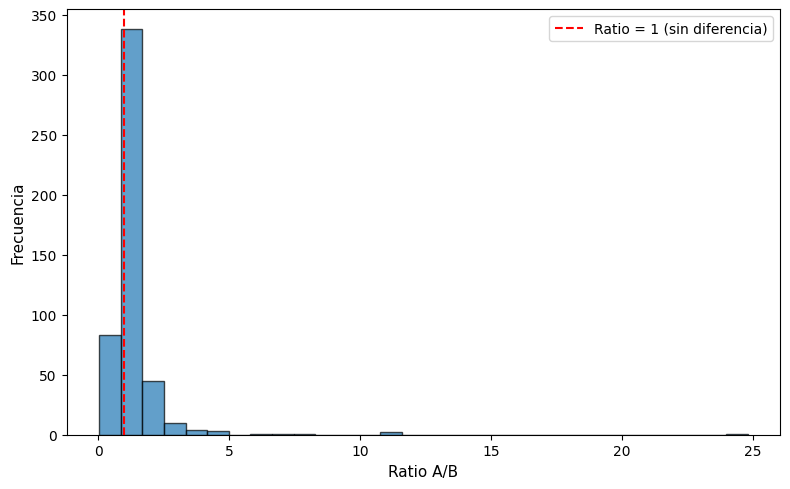

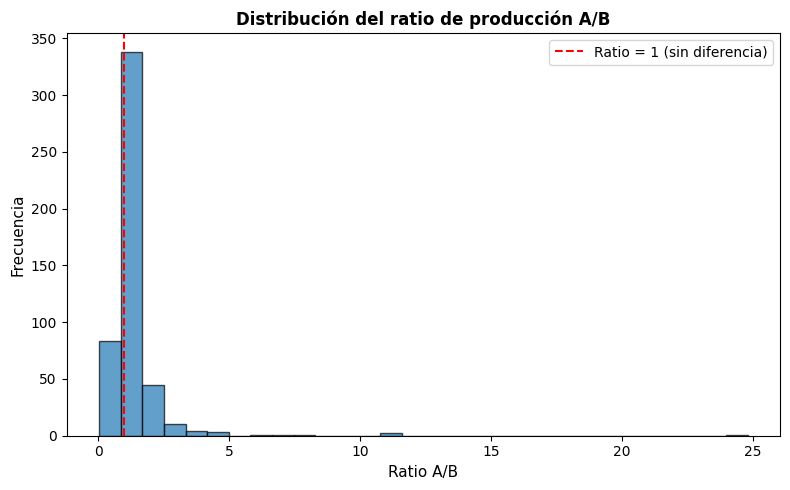

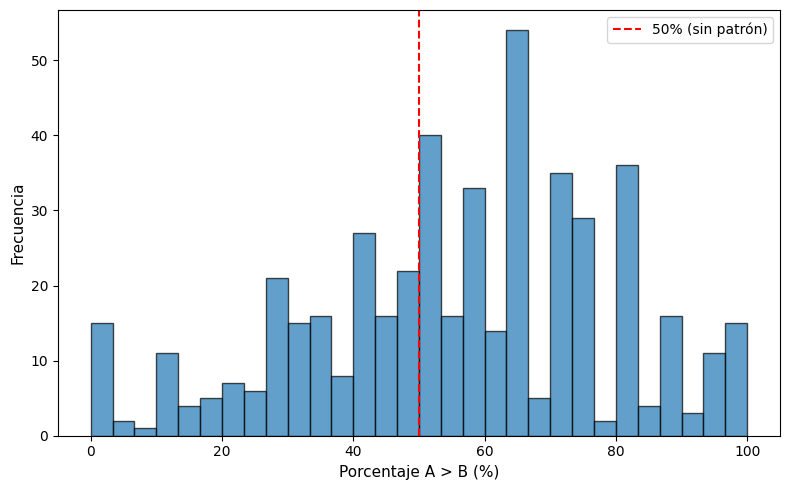

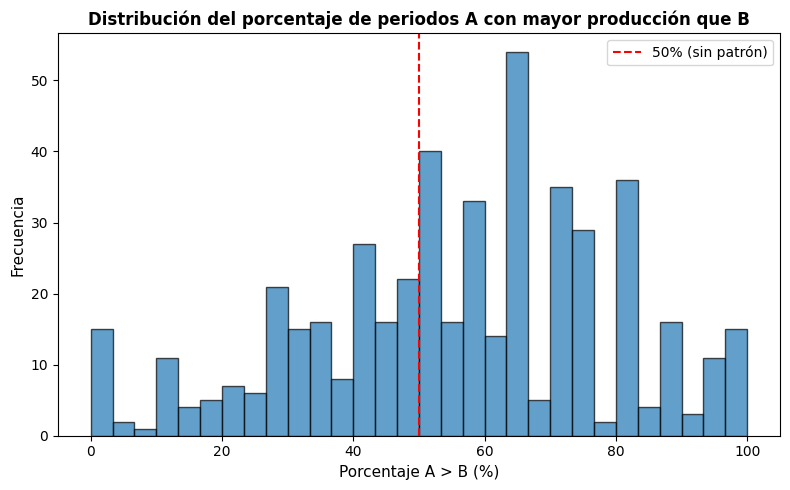

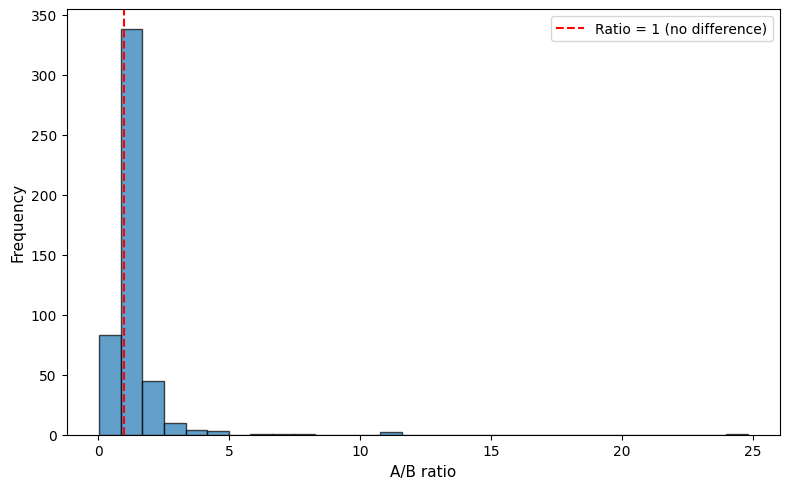

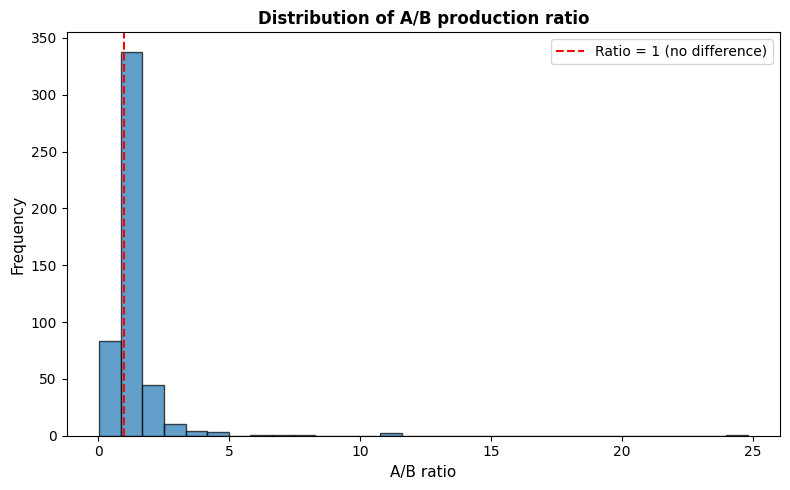

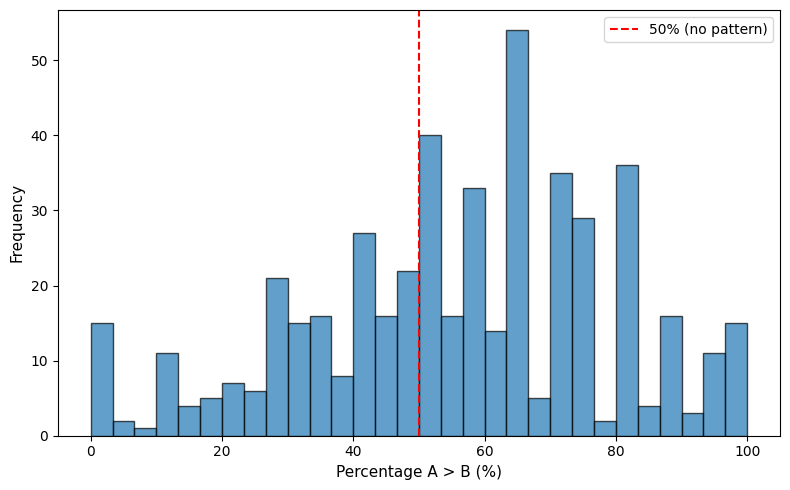

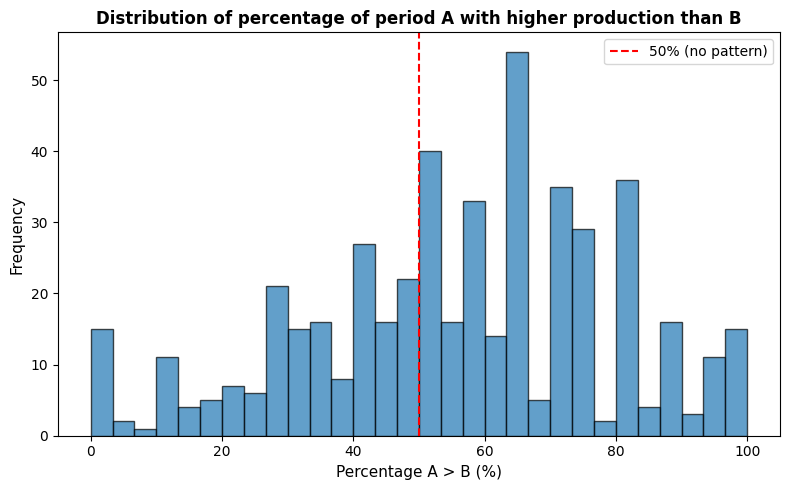

✓ 8 figuras guardadas en 'figures_clustering/'
  estacionalidad_hist_ratio_AB_es.pdf / estacionalidad_hist_ratio_AB_title_es.pdf
  estacionalidad_hist_pct_A_mayor_B_en.pdf   / estacionalidad_hist_pct_A_mayor_B_title_en.pdf  ...


In [40]:
# ==============================================================================
# DIMENSIÓN 3: ESTACIONALIDAD
# ==============================================================================

print("\n" + "=" * 80)
print("DIMENSIÓN 3: ESTACIONALIDAD")
print("=" * 80)

# ── Análisis y selección de k (genera sus propias figuras) ────────────────────
res_estacionalidad = analizar_dimension(
    df_analisis, 'Estacionalidad', dimensiones['Estacionalidad'])
visualizar_seleccion_k(res_estacionalidad)

# ── Estadísticas en consola ───────────────────────────────────────────────────
print(f"\nCorrelación ratio_AB vs porcentaje_A_mayor_B: "
      f"{df_analisis['ratio_AB'].corr(df_analisis['porcentaje_A_mayor_B']):.3f}")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS_RATIO = {
    'es': {
        'xlabel':    'Ratio A/B',
        'ylabel':    'Frecuencia',
        'label_ref': 'Ratio = 1 (sin diferencia)',
        'title':     'Distribución del ratio de producción A/B',
    },
    'en': {
        'xlabel':    'A/B ratio',
        'ylabel':    'Frequency',
        'label_ref': 'Ratio = 1 (no difference)',
        'title':     'Distribution of A/B production ratio',
    },
}

LABELS_PCT = {
    'es': {
        'xlabel':    'Porcentaje A > B (%)',
        'ylabel':    'Frecuencia',
        'label_ref': '50% (sin patrón)',
        'title':     'Distribución del porcentaje de periodos A con mayor producción que B',
    },
    'en': {
        'xlabel':    'Percentage A > B (%)',
        'ylabel':    'Frequency',
        'label_ref': '50% (no pattern)',
        'title':     'Distribution of percentage of period A with higher production than B',
    },
}

BASE_RATIO = "estacionalidad_hist_ratio_AB"
BASE_PCT   = "estacionalidad_hist_pct_A_mayor_B"

# ── Función histograma ratio A/B ──────────────────────────────────────────────
def plot_ratio_ab(xlabel, ylabel, label_ref, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_analisis['ratio_AB'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(1, color='red', linestyle='--', label=label_ref)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Función histograma % A > B ────────────────────────────────────────────────
def plot_pct_a_mayor_b(xlabel, ylabel, label_ref, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_analisis['porcentaje_A_mayor_B'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(50, color='red', linestyle='--', label=label_ref)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Generar las 8 figuras (2 tipos × 2 idiomas × 2 variantes) ────────────────
total = 0
for lang in ['es', 'en']:
    lr = LABELS_RATIO[lang]
    lp = LABELS_PCT[lang]

    plot_ratio_ab(lr['xlabel'], lr['ylabel'], lr['label_ref'])
    save_fig(f"{BASE_RATIO}_{lang}")
    plt.show()

    plot_ratio_ab(lr['xlabel'], lr['ylabel'], lr['label_ref'], title=lr['title'])
    save_fig(f"{BASE_RATIO}_title_{lang}")
    plt.show()

    plot_pct_a_mayor_b(lp['xlabel'], lp['ylabel'], lp['label_ref'])
    save_fig(f"{BASE_PCT}_{lang}")
    plt.show()

    plot_pct_a_mayor_b(lp['xlabel'], lp['ylabel'], lp['label_ref'], title=lp['title'])
    save_fig(f"{BASE_PCT}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_RATIO}_es.pdf / {BASE_RATIO}_title_es.pdf")
print(f"  {BASE_PCT}_en.pdf   / {BASE_PCT}_title_en.pdf  ...")

CLUSTERING DE ESTACIONALIDAD
k = 3, Silhouette = 0.4992

Distribución:
estacionalidad
Marcada         5
Moderada      291
Sin patrón    193
Name: count, dtype: int64


Estadísticas por grupo:
----------------------------------------------------------------------

Sin patrón (n=193):
  Ratio A/B — media: 0.965, mediana: 0.936
  % A > B  — media: 32.7%

Moderada (n=291):
  Ratio A/B — media: 1.386, mediana: 1.181
  % A > B  — media: 71.2%

Marcada (n=5):
  Ratio A/B — media: 12.430, mediana: 11.118
  % A > B  — media: 64.8%


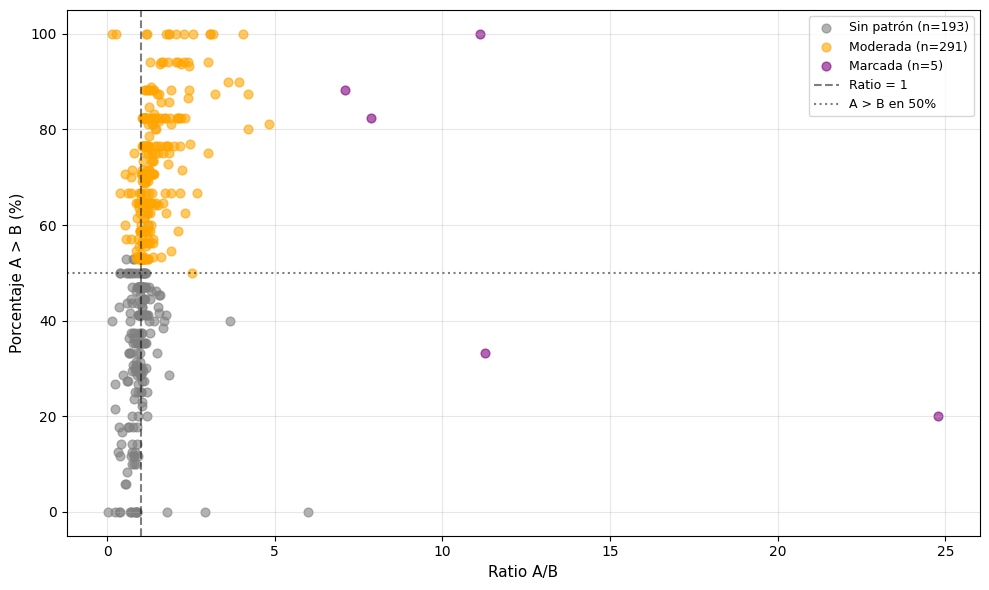

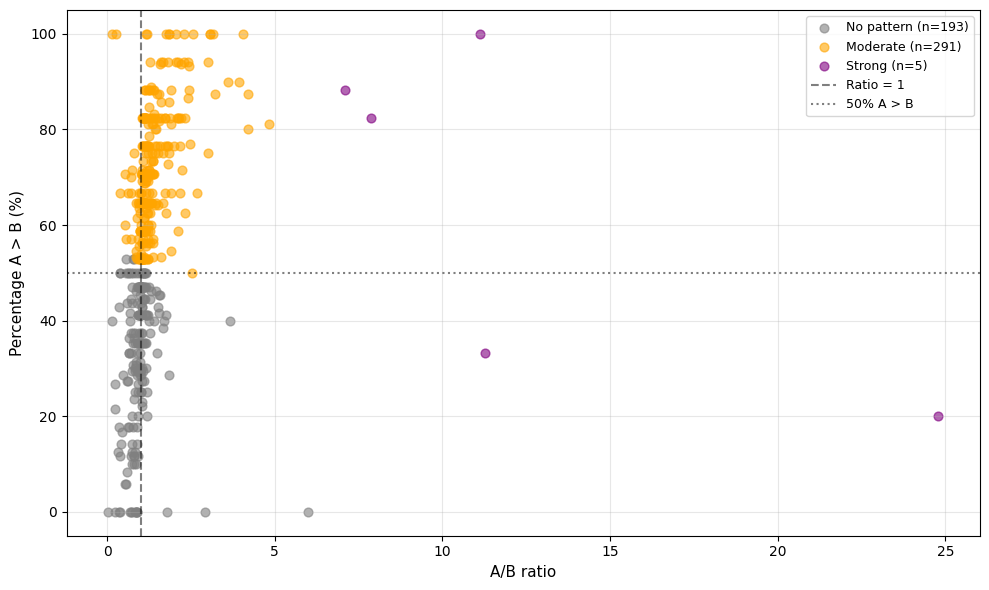

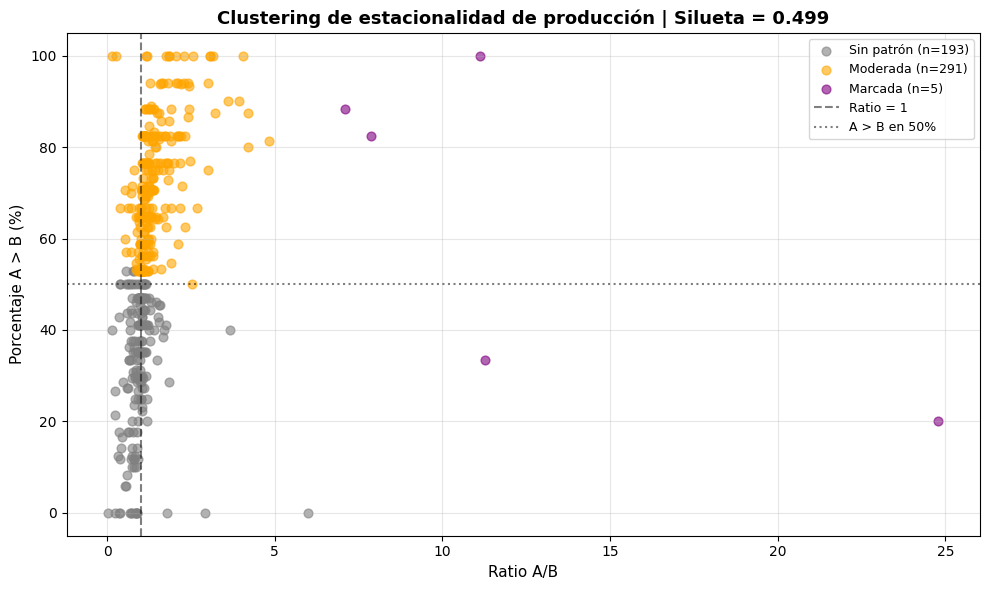

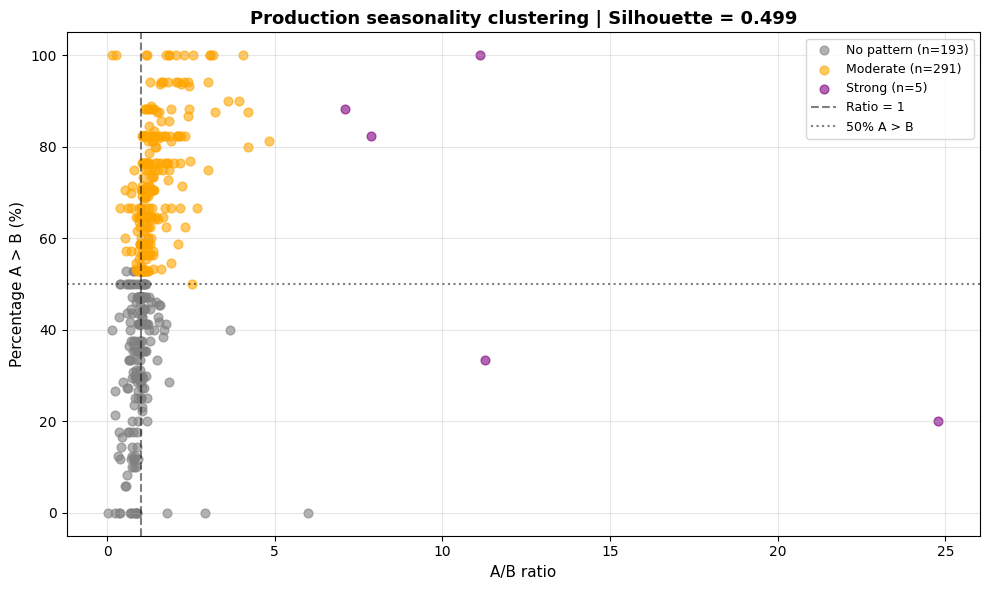

✓ 4 versiones guardadas en 'figures_clustering/':
   estacionalidad_clustering_2d_es.pdf
   estacionalidad_clustering_2d_en.pdf
   estacionalidad_clustering_2d_title_es.pdf
   estacionalidad_clustering_2d_title_en.pdf


In [42]:
# ==============================================================================
# APLICAR CLUSTERING - ESTACIONALIDAD
# ==============================================================================

k_estacionalidad = 3  # Sin patrón / Moderada / Marcada

labels_est, sil_est, kmeans_est = aplicar_clustering_dimension(
    df_analisis, res_estacionalidad, k_estacionalidad
)

etiquetas_est = dimensiones['Estacionalidad']['etiquetas_k3']
df_analisis['cluster_estacionalidad'] = labels_est
df_analisis['estacionalidad']         = df_analisis['cluster_estacionalidad'].map(etiquetas_est)

# Etiquetas en inglés
etiquetas_est_en = {
    i: {'Sin patrón': 'No pattern', 'Moderada': 'Moderate',
        'Marcada': 'Strong'}[etiquetas_est[i]]
    for i in range(k_estacionalidad)
}

# ── Resumen en consola ────────────────────────────────────────────────────────
print("CLUSTERING DE ESTACIONALIDAD")
print("=" * 80)
print(f"k = {k_estacionalidad}, Silhouette = {sil_est:.4f}\n")
print("Distribución:")
print(df_analisis['estacionalidad'].value_counts().sort_index())
print("\n\nEstadísticas por grupo:")
print("-" * 70)
for label in sorted(df_analisis['cluster_estacionalidad'].unique()):
    grupo = df_analisis[df_analisis['cluster_estacionalidad'] == label]
    print(f"\n{etiquetas_est[label]} (n={len(grupo)}):")
    print(f"  Ratio A/B — media: {grupo['ratio_AB'].mean():.3f}, "
          f"mediana: {grupo['ratio_AB'].median():.3f}")
    print(f"  % A > B  — media: {grupo['porcentaje_A_mayor_B'].mean():.1f}%")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel':  'Ratio A/B',
        'ylabel':  'Porcentaje A > B (%)',
        'label_v': 'Ratio = 1',
        'label_h': 'A > B en 50%',
        'title':   f'Clustering de estacionalidad de producción | Silueta = {sil_est:.3f}',
    },
    'en': {
        'xlabel':  'A/B ratio',
        'ylabel':  'Percentage A > B (%)',
        'label_v': 'Ratio = 1',
        'label_h': '50% A > B',
        'title':   f'Production seasonality clustering | Silhouette = {sil_est:.3f}',
    },
}
BASE   = "estacionalidad_clustering_2d"
colors = ['gray', 'orange', 'purple']

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_estacionalidad(xlabel, ylabel, label_v, label_h, lang, title=None):
    etiq = etiquetas_est if lang == 'es' else etiquetas_est_en
    fig, ax = plt.subplots(figsize=(10, 6))
    for i in range(k_estacionalidad):
        mask = df_analisis['cluster_estacionalidad'] == i
        ax.scatter(df_analisis.loc[mask, 'ratio_AB'],
                   df_analisis.loc[mask, 'porcentaje_A_mayor_B'],
                   c=colors[i], alpha=0.6,
                   label=f"{etiq[i]} (n={mask.sum()})", s=40)
    ax.axvline(1,  color='black', linestyle='--', alpha=0.5, label=label_v)
    ax.axhline(50, color='black', linestyle=':',  alpha=0.5, label=label_h)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── 1. Sin título — español ───────────────────────────────────────────────────
plot_estacionalidad(**{k: v for k, v in LABELS['es'].items() if k != 'title'}, lang='es')
save_fig(f"{BASE}_es")
plt.show()

# ── 2. Sin título — inglés ────────────────────────────────────────────────────
plot_estacionalidad(**{k: v for k, v in LABELS['en'].items() if k != 'title'}, lang='en')
save_fig(f"{BASE}_en")
plt.show()

# ── 3. Con título — español ───────────────────────────────────────────────────
plot_estacionalidad(**LABELS['es'], lang='es')
save_fig(f"{BASE}_title_es")
plt.show()

# ── 4. Con título — inglés ────────────────────────────────────────────────────
plot_estacionalidad(**LABELS['en'], lang='en')
save_fig(f"{BASE}_title_en")
plt.show()

print(f"✓ 4 versiones guardadas en '{OUT_DIR}/':")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

In [43]:
# ==============================================================================
# DETALLE DE PARES POR CLUSTER - ESTACIONALIDAD
# ==============================================================================

print("DETALLE DE PARES - ESTACIONALIDAD")
print("=" * 80)

for etiqueta in ['Sin patrón', 'Moderada', 'Marcada']:
    grupo = df_analisis[df_analisis['estacionalidad'] == etiqueta].copy()
    grupo = grupo.sort_values('ratio_AB', ascending=False)
    
    print(f"\n\n{'='*80}")
    print(f"{etiqueta.upper()} (n={len(grupo)})")
    print(f"Ratio A/B rango: {grupo['ratio_AB'].min():.3f} - {grupo['ratio_AB'].max():.3f}")
    print(f"Ratio A/B media: {grupo['ratio_AB'].mean():.3f}")
    print(f"% A > B media: {grupo['porcentaje_A_mayor_B'].mean():.1f}%")
    print("="*80)
    
    # Mostrar todos o los primeros/últimos según tamaño
    cols_mostrar = ['departamento', 'cultivo', 'ratio_AB', 'porcentaje_A_mayor_B', 'escala_productiva']
    
    if len(grupo) <= 30:
        print(f"\nTodos los pares:")
        print(grupo[cols_mostrar].to_string(index=False))
    else:
        print(f"\nPrimeros 15 pares (mayor ratio A/B en el grupo):")
        print(grupo[cols_mostrar].head(15).to_string(index=False))
        print(f"\n... ({len(grupo) - 30} pares intermedios omitidos) ...")
        print(f"\nÚltimos 15 pares (menor ratio A/B en el grupo):")
        print(grupo[cols_mostrar].tail(15).to_string(index=False))

# Cruce con escala productiva
print("\n\n" + "=" * 80)
print("TABLA CRUZADA: ESTACIONALIDAD × ESCALA PRODUCTIVA")
print("=" * 80)
tabla_est = pd.crosstab(df_analisis['estacionalidad'], df_analisis['escala_productiva'], margins=True)
print(tabla_est)

# Porcentajes por escala
print("\n\nPorcentaje por escala productiva:")
tabla_est_pct = pd.crosstab(df_analisis['estacionalidad'], df_analisis['escala_productiva'], normalize='columns') * 100
print(tabla_est_pct.round(1))

# Interpretación adicional del ratio
print("\n\n" + "=" * 80)
print("INTERPRETACIÓN DEL RATIO A/B")
print("=" * 80)
print("""
Ratio A/B = Producción promedio periodo A / Producción promedio periodo B

  - Ratio ≈ 1.0: Sin diferencia estacional (producción similar en A y B)
  - Ratio > 1.0: Mayor producción en periodo A (primer semestre)
  - Ratio < 1.0: Mayor producción en periodo B (segundo semestre)
  
  Ejemplo: Ratio = 2.0 significa que A produce el doble que B
  Ejemplo: Ratio = 0.5 significa que B produce el doble que A
""")

DETALLE DE PARES - ESTACIONALIDAD


SIN PATRÓN (n=193)
Ratio A/B rango: 0.031 - 5.993
Ratio A/B media: 0.965
% A > B media: 32.7%

Primeros 15 pares (mayor ratio A/B en el grupo):
   departamento         cultivo  ratio_AB  porcentaje_A_mayor_B escala_productiva
valle del cauca         algodon  5.993102              0.000000           Pequeña
        caqueta          tomate  3.658762             40.000000           Pequeña
         tolima         algodon  2.915444              0.000000           Pequeña
      risaralda         lechuga  1.842474             28.571429           Pequeña
        bolivar          tabaco  1.796814              0.000000           Pequeña
          cauca            mani  1.741463             41.176471           Pequeña
        vichada          tomate  1.686510             40.000000           Pequeña
         caldas       remolacha  1.670556             38.461538           Pequeña
         caldas         lechuga  1.572431             45.454545           Pequeña


### Continuidad


DIMENSIÓN 4: CONTINUIDAD

Continuidad - Resumen:
--------------------------------------------------
  k=2: Silhouette = 0.8007
  k=3: Silhouette = 0.7934
  k=4: Silhouette = 0.7836
  k=5: Silhouette = 0.7681
  k=6: Silhouette = 0.7976

  → Mejor k por Silhouette: 2


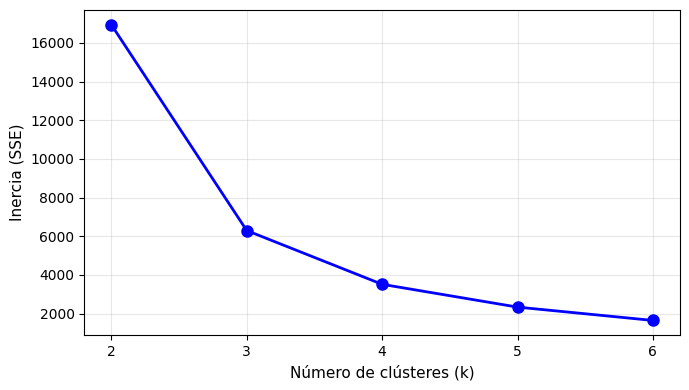

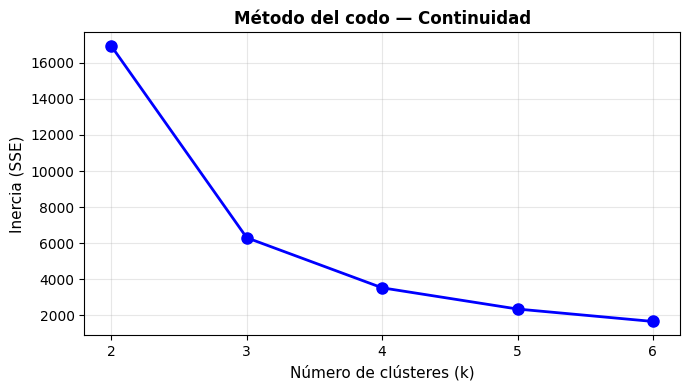

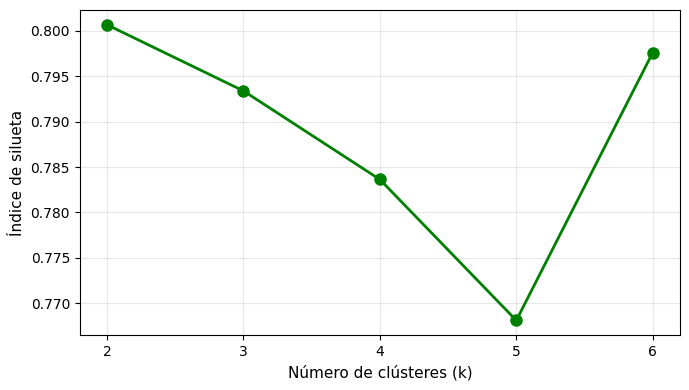

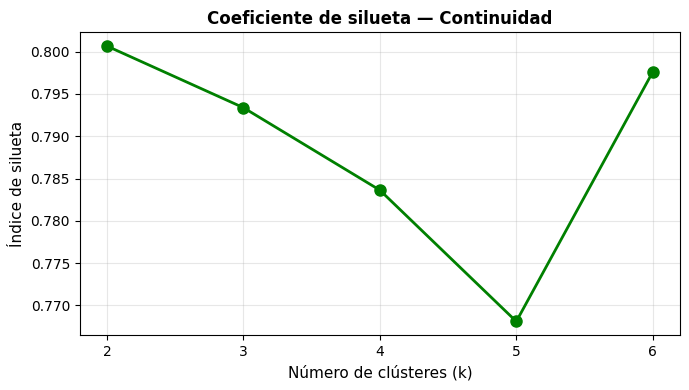

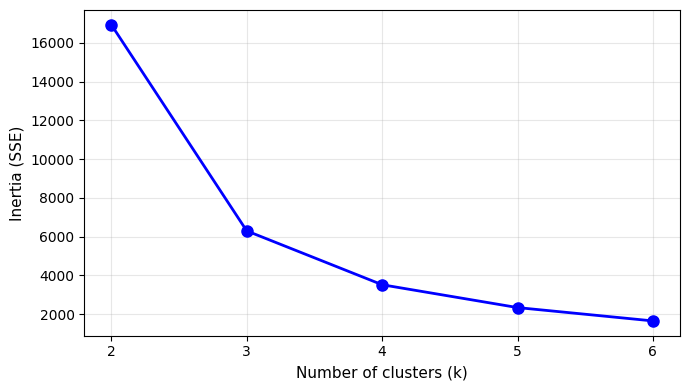

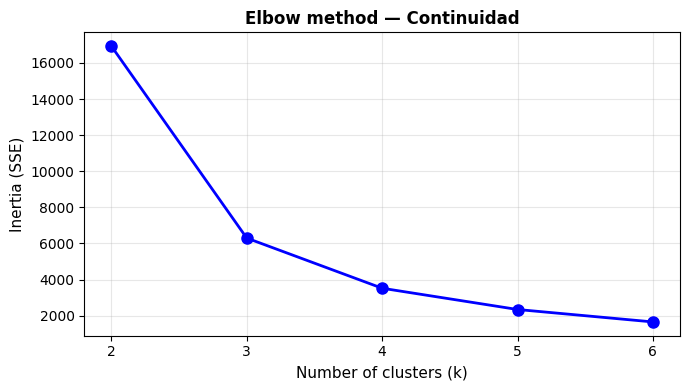

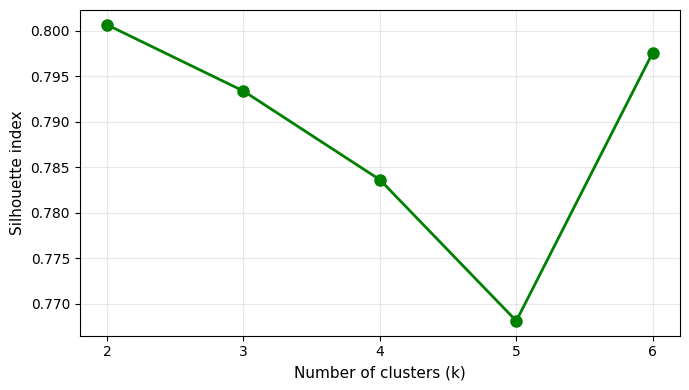

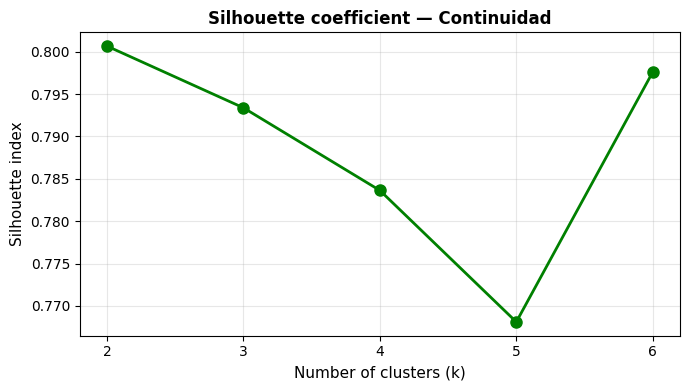

  ✓ 8 figuras guardadas: continuidad_codo_*.pdf | continuidad_silhouette_*.pdf

Estadísticas de completitud_pct:
count    489.000000
mean      89.476261
std       12.991929
min       41.666667
25%       86.111111
50%       97.222222
75%       97.222222
max      100.000000
Name: completitud_pct, dtype: float64


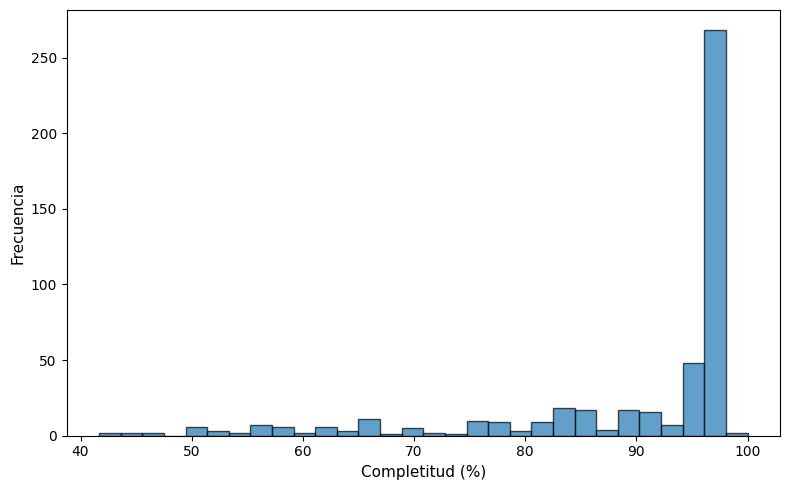

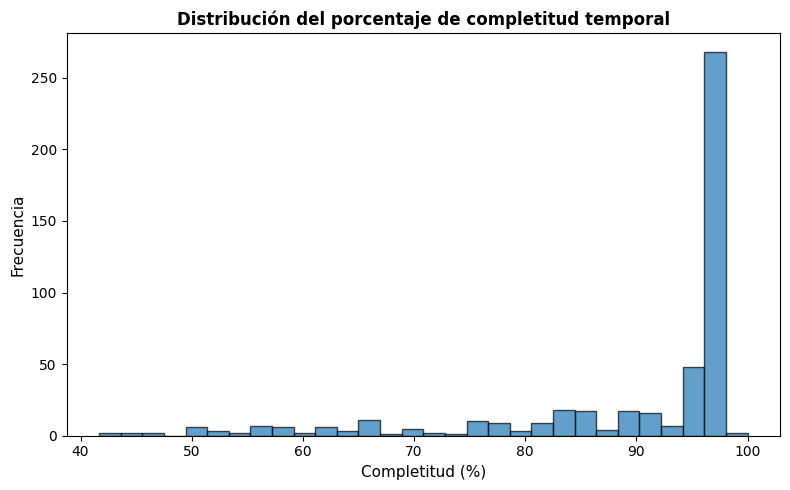

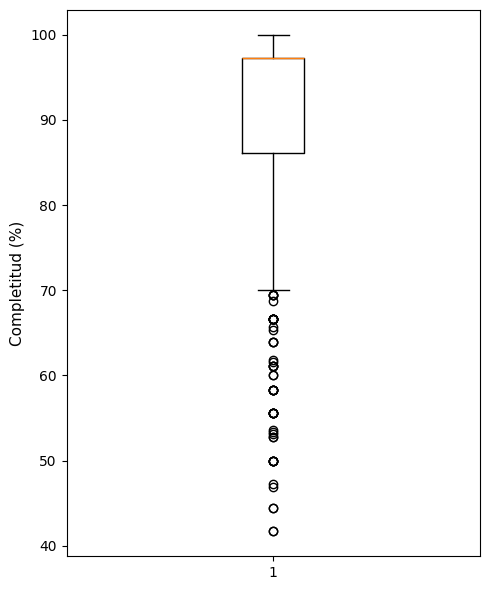

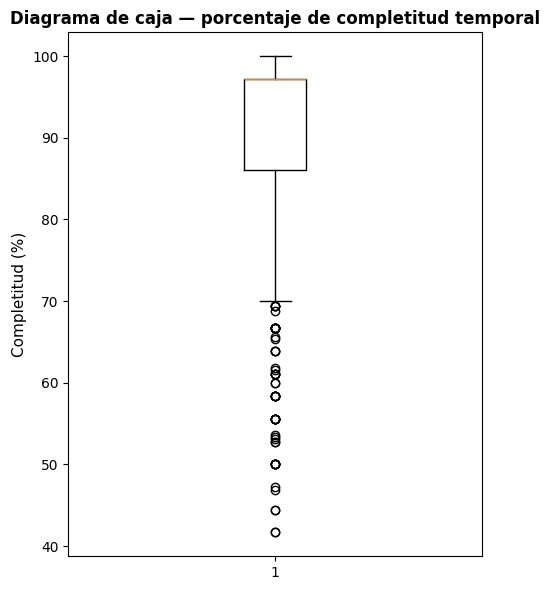

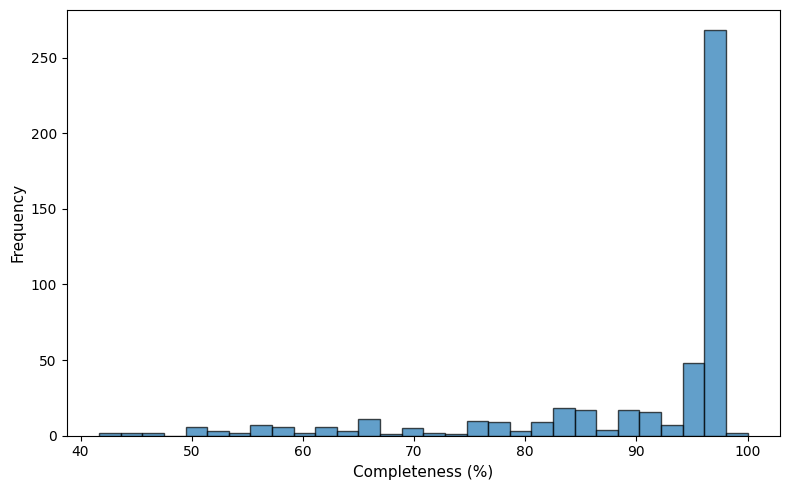

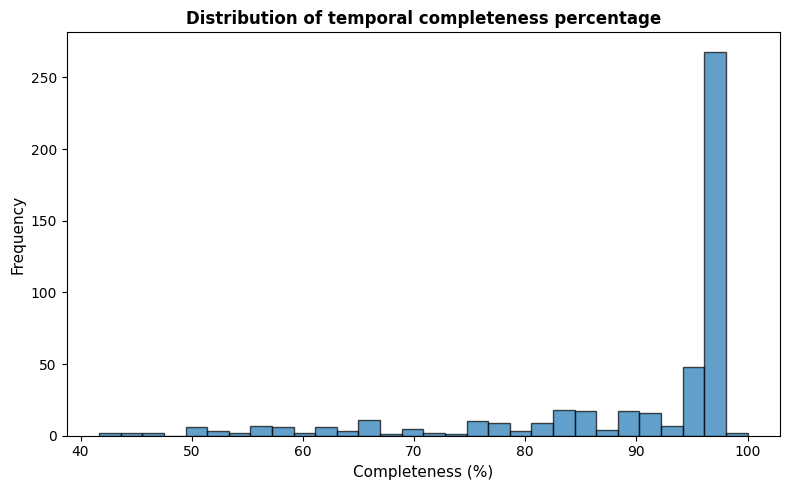

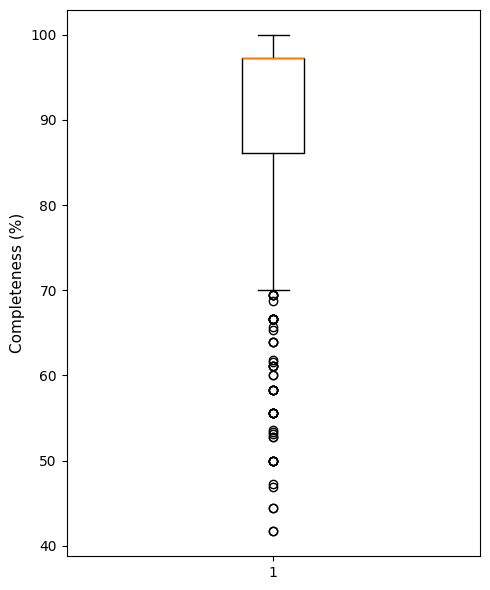

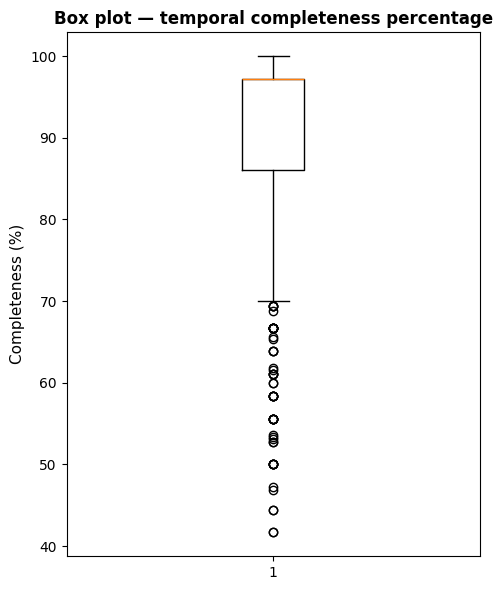

✓ 8 figuras guardadas en 'figures_clustering/'
  continuidad_hist_completitud_es.pdf / continuidad_hist_completitud_title_es.pdf
  continuidad_boxplot_completitud_en.pdf  / continuidad_boxplot_completitud_title_en.pdf  ...


In [44]:
# ==============================================================================
# DIMENSIÓN 4: CONTINUIDAD
# ==============================================================================

print("\n" + "=" * 80)
print("DIMENSIÓN 4: CONTINUIDAD")
print("=" * 80)

# ── Análisis y selección de k (genera sus propias figuras) ────────────────────
res_continuidad = analizar_dimension(
    df_analisis, 'Continuidad', dimensiones['Continuidad'])
visualizar_seleccion_k(res_continuidad)

# ── Estadísticas en consola ───────────────────────────────────────────────────
print("\nEstadísticas de completitud_pct:")
print(df_analisis['completitud_pct'].describe())

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS_HIST = {
    'es': {
        'xlabel': 'Completitud (%)',
        'ylabel': 'Frecuencia',
        'title':  'Distribución del porcentaje de completitud temporal',
    },
    'en': {
        'xlabel': 'Completeness (%)',
        'ylabel': 'Frequency',
        'title':  'Distribution of temporal completeness percentage',
    },
}

LABELS_BOX = {
    'es': {
        'ylabel': 'Completitud (%)',
        'title':  'Diagrama de caja — porcentaje de completitud temporal',
    },
    'en': {
        'ylabel': 'Completeness (%)',
        'title':  'Box plot — temporal completeness percentage',
    },
}

BASE_HIST = "continuidad_hist_completitud"
BASE_BOX  = "continuidad_boxplot_completitud"

# ── Función histograma ────────────────────────────────────────────────────────
def plot_hist_completitud(xlabel, ylabel, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_analisis['completitud_pct'], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Función boxplot ───────────────────────────────────────────────────────────
def plot_box_completitud(ylabel, title=None):
    fig, ax = plt.subplots(figsize=(5, 6))
    ax.boxplot(df_analisis['completitud_pct'], vert=True)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Generar las 8 figuras (2 tipos × 2 idiomas × 2 variantes) ────────────────
total = 0
for lang in ['es', 'en']:
    lh = LABELS_HIST[lang]
    lb = LABELS_BOX[lang]

    plot_hist_completitud(lh['xlabel'], lh['ylabel'])
    save_fig(f"{BASE_HIST}_{lang}")
    plt.show()

    plot_hist_completitud(lh['xlabel'], lh['ylabel'], title=lh['title'])
    save_fig(f"{BASE_HIST}_title_{lang}")
    plt.show()

    plot_box_completitud(lb['ylabel'])
    save_fig(f"{BASE_BOX}_{lang}")
    plt.show()

    plot_box_completitud(lb['ylabel'], title=lb['title'])
    save_fig(f"{BASE_BOX}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_HIST}_es.pdf / {BASE_HIST}_title_es.pdf")
print(f"  {BASE_BOX}_en.pdf  / {BASE_BOX}_title_en.pdf  ...")

CLUSTERING DE CONTINUIDAD
k = 3, Silhouette = 0.7934

Distribución:
continuidad
Continua        341
Intermitente     58
Regular          90
Name: count, dtype: int64


Estadísticas por grupo:
------------------------------------------------------------

Intermitente (n=58):
  Completitud mín: 41.7%  máx: 70.0%  media: 58.6%

Regular (n=90):
  Completitud mín: 72.2%  máx: 88.9%  media: 82.8%

Continua (n=341):
  Completitud mín: 90.9%  máx: 100.0%  media: 96.5%


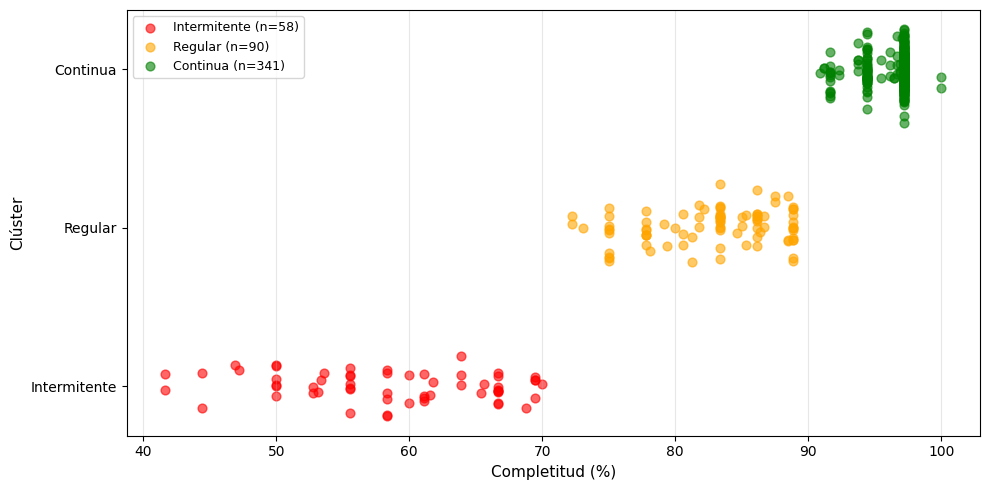

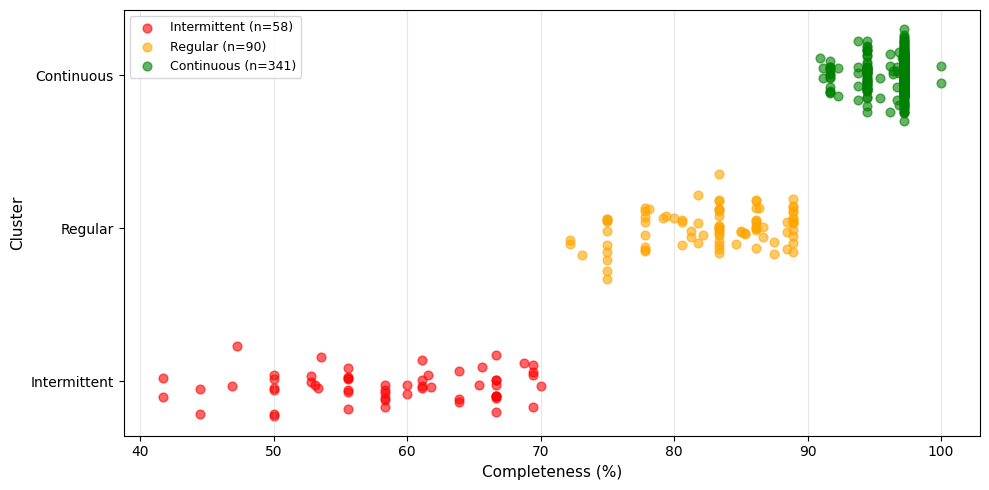

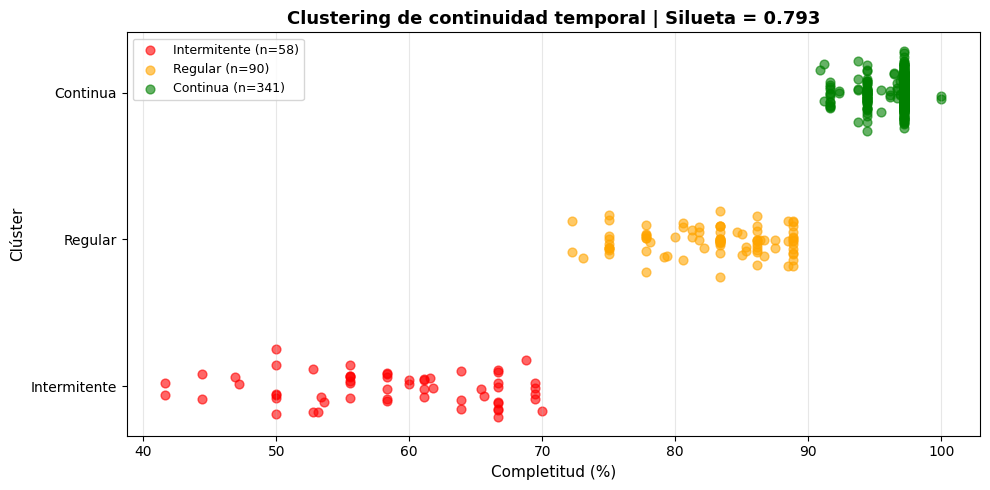

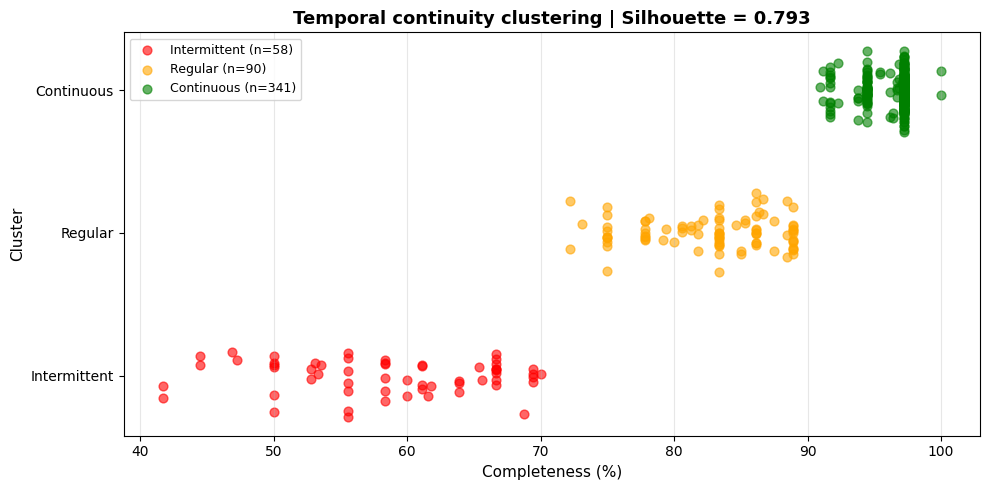

✓ 4 versiones guardadas en 'figures_clustering/':
   continuidad_clustering_distribucion_es.pdf
   continuidad_clustering_distribucion_en.pdf
   continuidad_clustering_distribucion_title_es.pdf
   continuidad_clustering_distribucion_title_en.pdf


In [46]:
# ==============================================================================
# APLICAR CLUSTERING - CONTINUIDAD
# ==============================================================================

k_continuidad = 3  # Intermitente / Regular / Continua

labels_cont, sil_cont, kmeans_cont = aplicar_clustering_dimension(
    df_analisis, res_continuidad, k_continuidad
)

etiquetas_cont = dimensiones['Continuidad']['etiquetas_k3']
df_analisis['cluster_continuidad'] = labels_cont
df_analisis['continuidad']         = df_analisis['cluster_continuidad'].map(etiquetas_cont)

# Etiquetas en inglés
etiquetas_cont_en = {
    i: {'Intermitente': 'Intermittent', 'Regular': 'Regular',
        'Continua': 'Continuous'}[etiquetas_cont[i]]
    for i in range(k_continuidad)
}

# ── Resumen en consola ────────────────────────────────────────────────────────
print("CLUSTERING DE CONTINUIDAD")
print("=" * 80)
print(f"k = {k_continuidad}, Silhouette = {sil_cont:.4f}\n")
print("Distribución:")
print(df_analisis['continuidad'].value_counts().sort_index())
print("\n\nEstadísticas por grupo:")
print("-" * 60)
for label in sorted(df_analisis['cluster_continuidad'].unique()):
    grupo = df_analisis[df_analisis['cluster_continuidad'] == label]
    comp  = grupo['completitud_pct']
    print(f"\n{etiquetas_cont[label]} (n={len(grupo)}):")
    print(f"  Completitud mín: {comp.min():.1f}%  "
          f"máx: {comp.max():.1f}%  media: {comp.mean():.1f}%")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel': 'Completitud (%)',
        'ylabel': 'Clúster',
        'title':  f'Clustering de continuidad temporal | Silueta = {sil_cont:.3f}',
    },
    'en': {
        'xlabel': 'Completeness (%)',
        'ylabel': 'Cluster',
        'title':  f'Temporal continuity clustering | Silhouette = {sil_cont:.3f}',
    },
}
BASE   = "continuidad_clustering_distribucion"
colors = ['red', 'orange', 'green']

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_continuidad(xlabel, ylabel, lang, title=None):
    etiq = etiquetas_cont if lang == 'es' else etiquetas_cont_en
    fig, ax = plt.subplots(figsize=(10, 5))
    for i in range(k_continuidad):
        mask  = df_analisis['cluster_continuidad'] == i
        datos = df_analisis.loc[mask, 'completitud_pct']
        ax.scatter(datos, np.random.normal(i, 0.1, size=len(datos)),
                   c=colors[i], alpha=0.6,
                   label=f"{etiq[i]} (n={len(datos)})", s=40)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_yticks(range(k_continuidad))
    ax.set_yticklabels([etiq[i] for i in range(k_continuidad)])
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── 1. Sin título — español ───────────────────────────────────────────────────
plot_continuidad(**{k: v for k, v in LABELS['es'].items() if k != 'title'}, lang='es')
save_fig(f"{BASE}_es")
plt.show()

# ── 2. Sin título — inglés ────────────────────────────────────────────────────
plot_continuidad(**{k: v for k, v in LABELS['en'].items() if k != 'title'}, lang='en')
save_fig(f"{BASE}_en")
plt.show()

# ── 3. Con título — español ───────────────────────────────────────────────────
plot_continuidad(**LABELS['es'], lang='es')
save_fig(f"{BASE}_title_es")
plt.show()

# ── 4. Con título — inglés ────────────────────────────────────────────────────
plot_continuidad(**LABELS['en'], lang='en')
save_fig(f"{BASE}_title_en")
plt.show()

print(f"✓ 4 versiones guardadas en '{OUT_DIR}/':")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

In [47]:
# ==============================================================================
# DETALLE DE PARES POR CLUSTER - CONTINUIDAD
# ==============================================================================

print("DETALLE DE PARES - CONTINUIDAD")
print("=" * 80)

for etiqueta in ['Intermitente', 'Regular', 'Continua']:
    grupo = df_analisis[df_analisis['continuidad'] == etiqueta].copy()
    grupo = grupo.sort_values('completitud_pct', ascending=False)
    
    print(f"\n\n{'='*80}")
    print(f"{etiqueta.upper()} (n={len(grupo)})")
    print(f"Completitud rango: {grupo['completitud_pct'].min():.1f}% - {grupo['completitud_pct'].max():.1f}%")
    print(f"Completitud media: {grupo['completitud_pct'].mean():.1f}%")
    print("="*80)
    
    # Mostrar todos o los primeros/últimos según tamaño
    cols_mostrar = ['departamento', 'cultivo', 'completitud_pct', 'n_periodos', 'escala_productiva']
    
    if len(grupo) <= 30:
        print(f"\nTodos los pares:")
        print(grupo[cols_mostrar].to_string(index=False))
    else:
        print(f"\nPrimeros 15 pares (mayor completitud en el grupo):")
        print(grupo[cols_mostrar].head(15).to_string(index=False))
        print(f"\n... ({len(grupo) - 30} pares intermedios omitidos) ...")
        print(f"\nÚltimos 15 pares (menor completitud en el grupo):")
        print(grupo[cols_mostrar].tail(15).to_string(index=False))

# Cruce con escala productiva
print("\n\n" + "=" * 80)
print("TABLA CRUZADA: CONTINUIDAD × ESCALA PRODUCTIVA")
print("=" * 80)
tabla_cont = pd.crosstab(df_analisis['continuidad'], df_analisis['escala_productiva'], margins=True)
print(tabla_cont)

# Porcentajes por escala
print("\n\nPorcentaje por escala productiva:")
tabla_cont_pct = pd.crosstab(df_analisis['continuidad'], df_analisis['escala_productiva'], normalize='columns') * 100
print(tabla_cont_pct.round(1))

# Recordatorio sobre el umbral de filtrado
print("\n\n" + "=" * 80)
print("NOTA SOBRE EL UMBRAL DE FILTRADO")
print("=" * 80)
print("""
Recordar que el dataset fue filtrado previamente para incluir solo pares con 
al menos 15 periodos observados (de 36 posibles), lo que equivale a un mínimo 
de 41.7% de completitud. Por tanto, no existen pares con completitud inferior 
a este umbral en el análisis.
""")

DETALLE DE PARES - CONTINUIDAD


INTERMITENTE (n=58)
Completitud rango: 41.7% - 70.0%
Completitud media: 58.6%

Primeros 15 pares (mayor completitud en el grupo):
   departamento         cultivo  completitud_pct  n_periodos escala_productiva
          cauca            haba        70.000000          21           Pequeña
      antioquia cebolla de rama        69.444444          25           Pequeña
valle del cauca cebolla de rama        69.444444          25           Pequeña
         narino cebolla de rama        69.444444          25           Pequeña
        cordoba        ajonjoli        69.444444          25           Pequeña
          sucre          tabaco        68.750000          22           Pequeña
          sucre         ahuyama        66.666667          24           Pequeña
       amazonas        pimenton        66.666667          24           Pequeña
         vaupes             aji        66.666667          24           Pequeña
valle del cauca             aji        66.66666

### Concentración


DIMENSIÓN 5: CONCENTRACIÓN ESPACIAL

Concentración - Resumen:
--------------------------------------------------
  k=2: Silhouette = 0.7183
  k=3: Silhouette = 0.6198
  k=4: Silhouette = 0.6757
  k=5: Silhouette = 0.6713
  k=6: Silhouette = 0.6715

  → Mejor k por Silhouette: 2


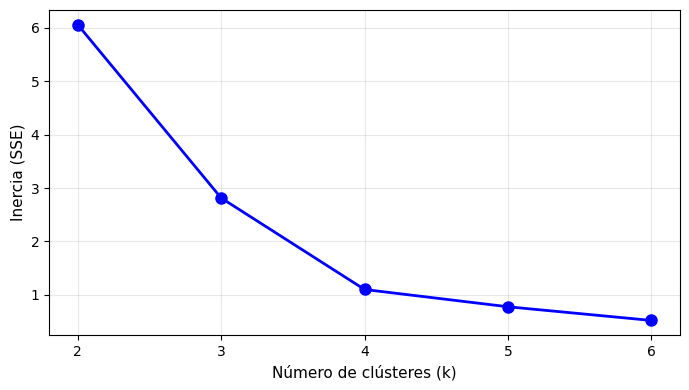

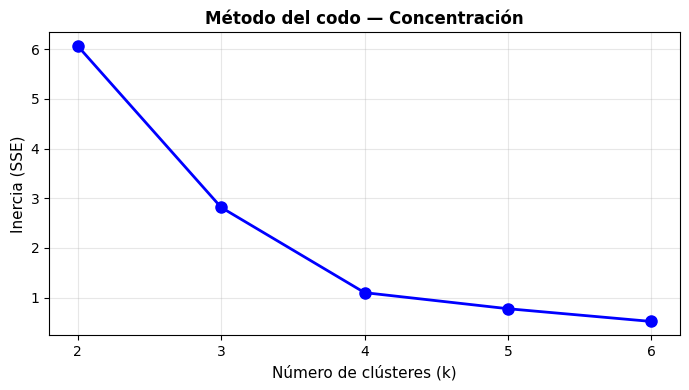

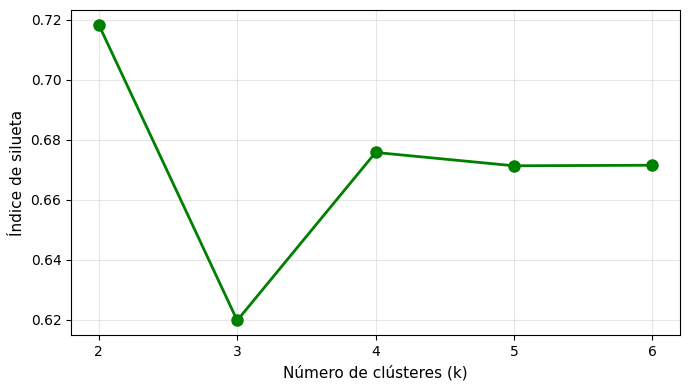

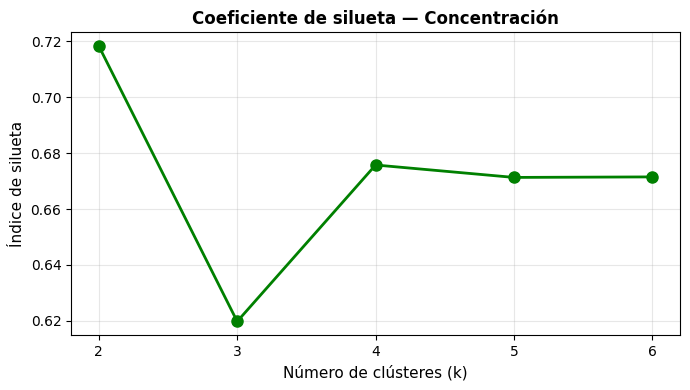

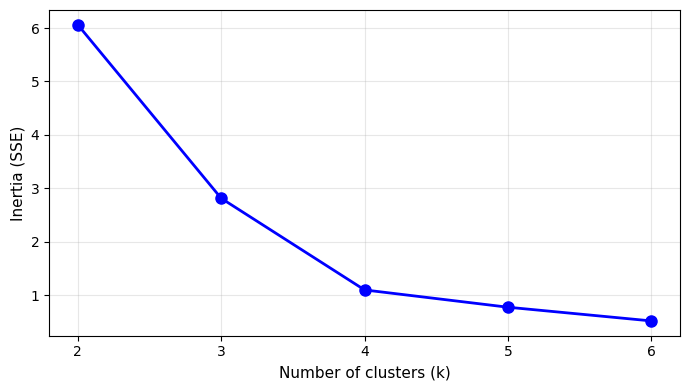

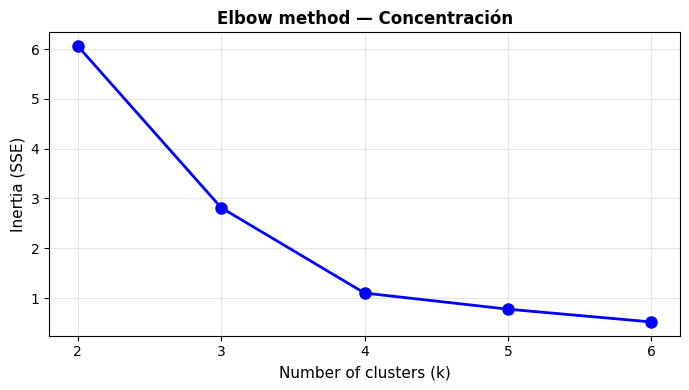

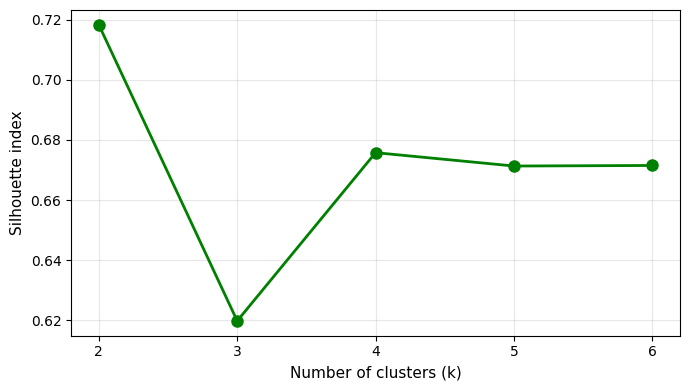

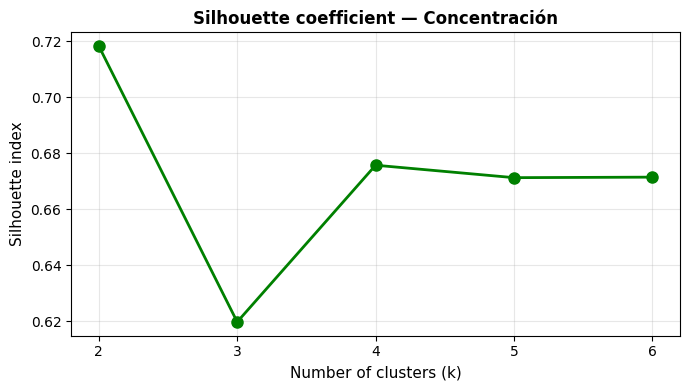

  ✓ 8 figuras guardadas: concentracion_codo_*.pdf | concentracion_silhouette_*.pdf

Estadísticas de hhi_espacial_cultivo:
count    489.000000
mean       0.275765
std        0.191223
min        0.082138
25%        0.150174
50%        0.262344
75%        0.320642
max        1.000000
Name: hhi_espacial_cultivo, dtype: float64

Interpretación del HHI:
  HHI < 0.15: Mercado no concentrado (disperso)
  0.15 ≤ HHI < 0.25: Concentración moderada
  HHI ≥ 0.25: Alta concentración


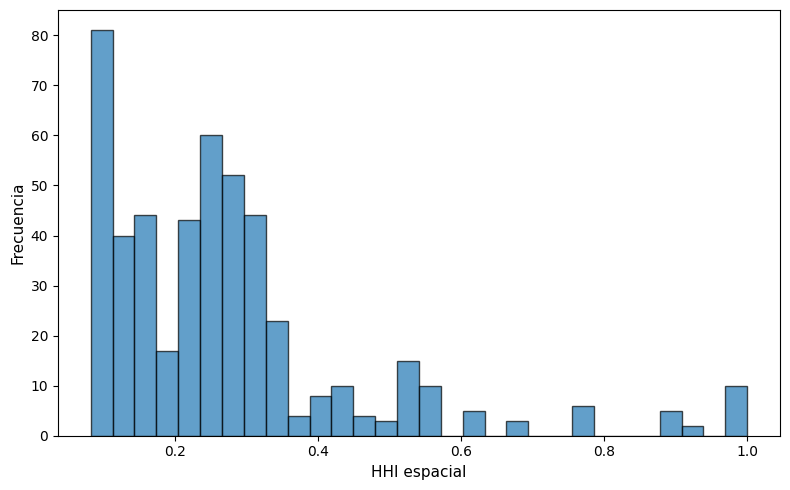

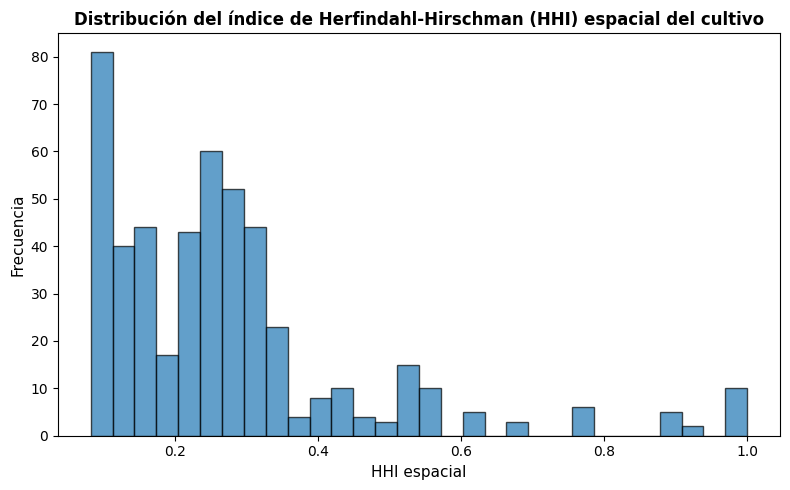

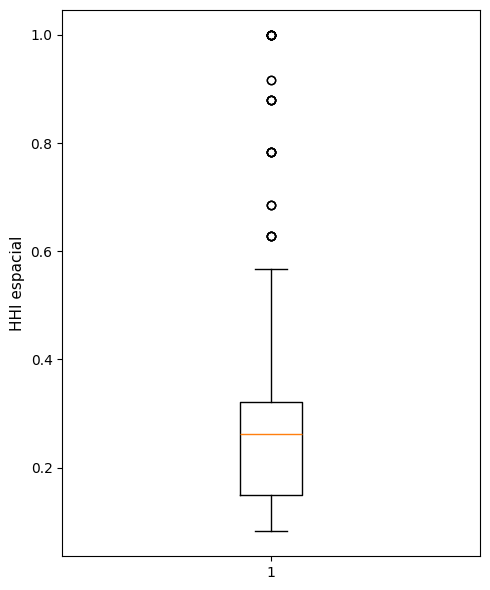

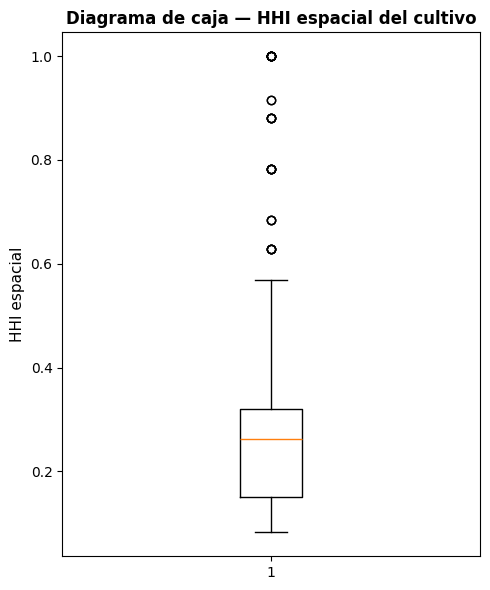

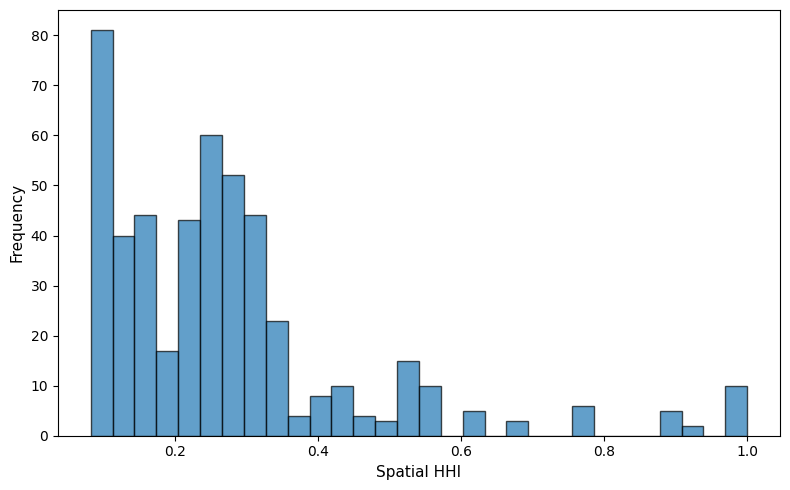

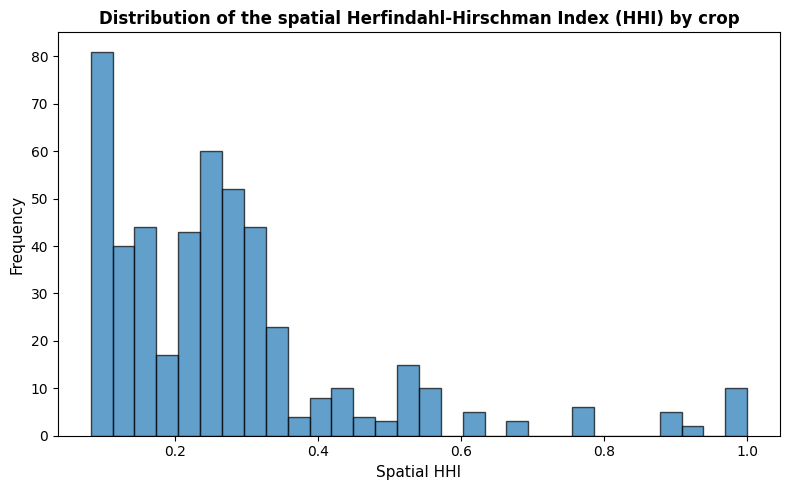

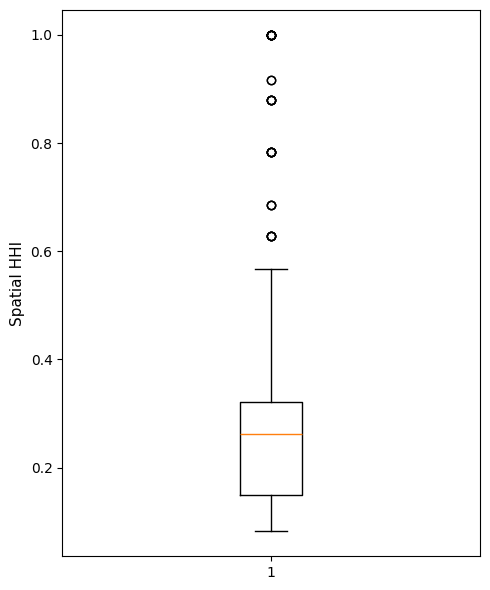

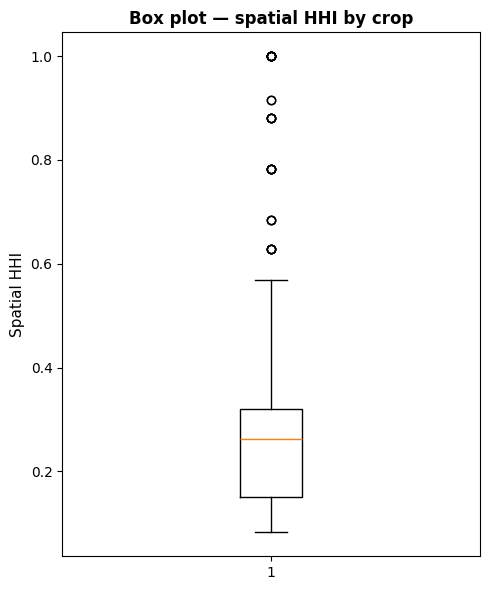

✓ 8 figuras guardadas en 'figures_clustering/'
  concentracion_hist_hhi_es.pdf / concentracion_hist_hhi_title_es.pdf
  concentracion_boxplot_hhi_en.pdf  / concentracion_boxplot_hhi_title_en.pdf  ...


In [48]:
# ==============================================================================
# DIMENSIÓN 5: CONCENTRACIÓN ESPACIAL
# ==============================================================================

print("\n" + "=" * 80)
print("DIMENSIÓN 5: CONCENTRACIÓN ESPACIAL")
print("=" * 80)

# ── Análisis y selección de k (genera sus propias figuras) ────────────────────
res_concentracion = analizar_dimension(
    df_analisis, 'Concentración', dimensiones['Concentración'])
visualizar_seleccion_k(res_concentracion)

# ── Estadísticas en consola ───────────────────────────────────────────────────
print("\nEstadísticas de hhi_espacial_cultivo:")
print(df_analisis['hhi_espacial_cultivo'].describe())
print("\nInterpretación del HHI:")
print("  HHI < 0.15: Mercado no concentrado (disperso)")
print("  0.15 ≤ HHI < 0.25: Concentración moderada")
print("  HHI ≥ 0.25: Alta concentración")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS_HIST = {
    'es': {
        'xlabel': 'HHI espacial',
        'ylabel': 'Frecuencia',
        'title':  'Distribución del índice de Herfindahl-Hirschman (HHI) espacial del cultivo',
    },
    'en': {
        'xlabel': 'Spatial HHI',
        'ylabel': 'Frequency',
        'title':  'Distribution of the spatial Herfindahl-Hirschman Index (HHI) by crop',
    },
}

LABELS_BOX = {
    'es': {
        'ylabel': 'HHI espacial',
        'title':  'Diagrama de caja — HHI espacial del cultivo',
    },
    'en': {
        'ylabel': 'Spatial HHI',
        'title':  'Box plot — spatial HHI by crop',
    },
}

BASE_HIST = "concentracion_hist_hhi"
BASE_BOX  = "concentracion_boxplot_hhi"

# ── Función histograma ────────────────────────────────────────────────────────
def plot_hist_hhi(xlabel, ylabel, title=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(df_analisis['hhi_espacial_cultivo'], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Función boxplot ───────────────────────────────────────────────────────────
def plot_box_hhi(ylabel, title=None):
    fig, ax = plt.subplots(figsize=(5, 6))
    ax.boxplot(df_analisis['hhi_espacial_cultivo'], vert=True)
    ax.set_ylabel(ylabel, fontsize=11)
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()

# ── Generar las 8 figuras (2 tipos × 2 idiomas × 2 variantes) ────────────────
total = 0
for lang in ['es', 'en']:
    lh = LABELS_HIST[lang]
    lb = LABELS_BOX[lang]

    plot_hist_hhi(lh['xlabel'], lh['ylabel'])
    save_fig(f"{BASE_HIST}_{lang}")
    plt.show()

    plot_hist_hhi(lh['xlabel'], lh['ylabel'], title=lh['title'])
    save_fig(f"{BASE_HIST}_title_{lang}")
    plt.show()

    plot_box_hhi(lb['ylabel'])
    save_fig(f"{BASE_BOX}_{lang}")
    plt.show()

    plot_box_hhi(lb['ylabel'], title=lb['title'])
    save_fig(f"{BASE_BOX}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_HIST}_es.pdf / {BASE_HIST}_title_es.pdf")
print(f"  {BASE_BOX}_en.pdf  / {BASE_BOX}_title_en.pdf  ...")

CLUSTERING DE CONCENTRACIÓN ESPACIAL
k = 3, Silhouette = 0.6198

Distribución:
concentracion
Concentrado     31
Disperso       225
Moderado       233
Name: count, dtype: int64


Estadísticas por grupo:
------------------------------------------------------------

Disperso (n=225):
  HHI mín: 0.082  máx: 0.210  media: 0.138

Moderado (n=233):
  HHI mín: 0.257  máx: 0.568  media: 0.334

Concentrado (n=31):
  HHI mín: 0.628  máx: 1.000  media: 0.843


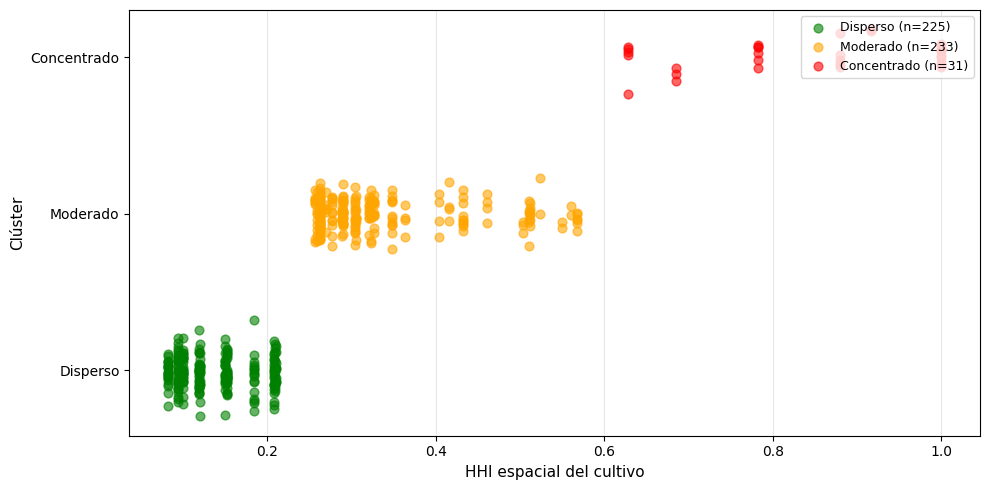

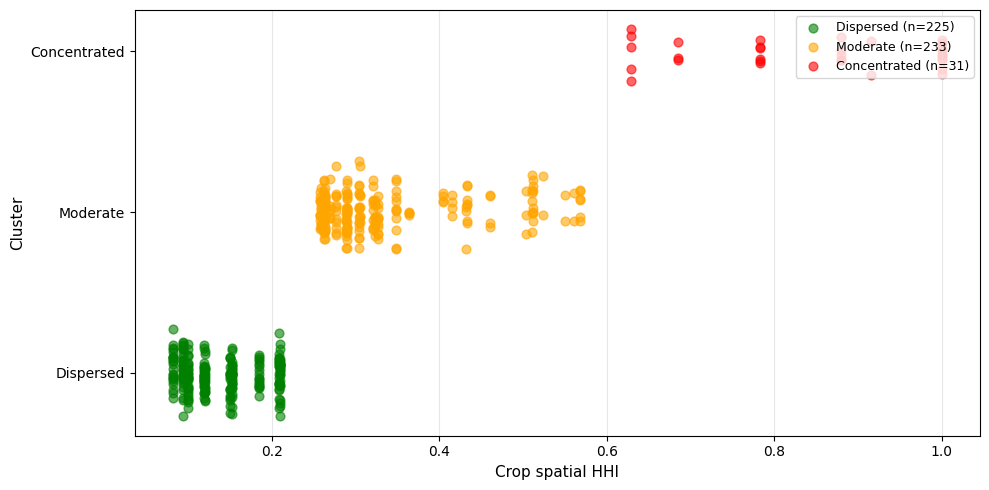

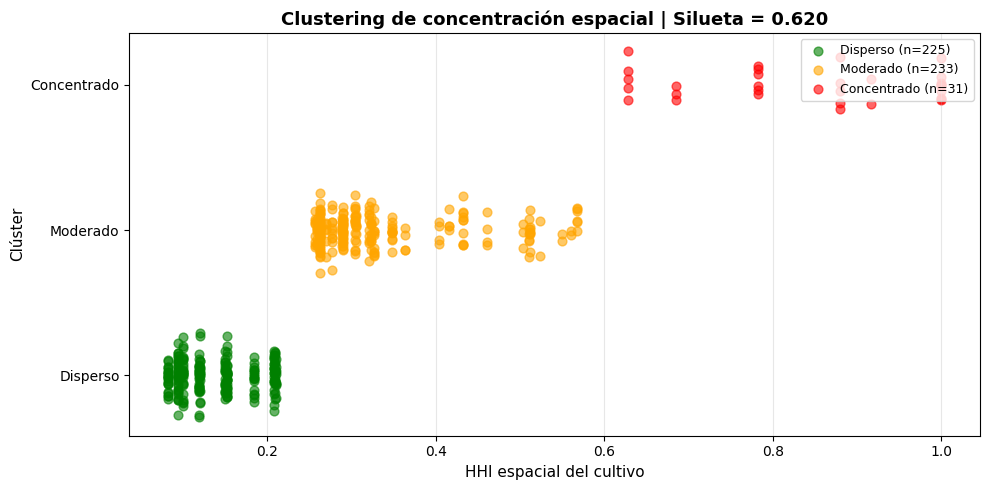

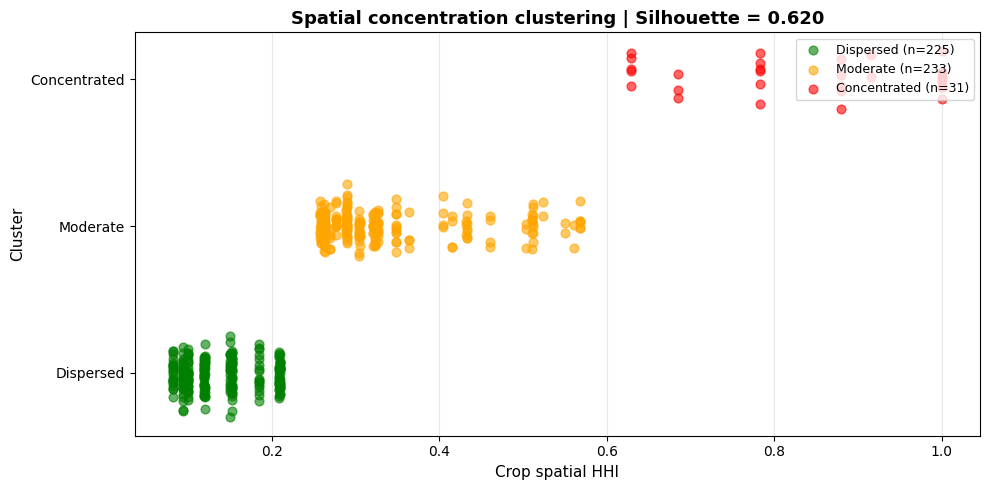

✓ 4 versiones guardadas en 'figures_clustering/':
   concentracion_clustering_distribucion_es.pdf
   concentracion_clustering_distribucion_en.pdf
   concentracion_clustering_distribucion_title_es.pdf
   concentracion_clustering_distribucion_title_en.pdf


In [50]:
# ==============================================================================
# APLICAR CLUSTERING - CONCENTRACIÓN
# ==============================================================================

k_concentracion = 3  # Disperso / Moderado / Concentrado

labels_conc, sil_conc, kmeans_conc = aplicar_clustering_dimension(
    df_analisis, res_concentracion, k_concentracion
)

etiquetas_conc = dimensiones['Concentración']['etiquetas_k3']
df_analisis['cluster_concentracion'] = labels_conc
df_analisis['concentracion']         = df_analisis['cluster_concentracion'].map(etiquetas_conc)

# Etiquetas en inglés
etiquetas_conc_en = {
    i: {'Disperso': 'Dispersed', 'Moderado': 'Moderate',
        'Concentrado': 'Concentrated'}[etiquetas_conc[i]]
    for i in range(k_concentracion)
}

# ── Resumen en consola ────────────────────────────────────────────────────────
print("CLUSTERING DE CONCENTRACIÓN ESPACIAL")
print("=" * 80)
print(f"k = {k_concentracion}, Silhouette = {sil_conc:.4f}\n")
print("Distribución:")
print(df_analisis['concentracion'].value_counts().sort_index())
print("\n\nEstadísticas por grupo:")
print("-" * 60)
for label in sorted(df_analisis['cluster_concentracion'].unique()):
    grupo = df_analisis[df_analisis['cluster_concentracion'] == label]
    hhi   = grupo['hhi_espacial_cultivo']
    print(f"\n{etiquetas_conc[label]} (n={len(grupo)}):")
    print(f"  HHI mín: {hhi.min():.3f}  máx: {hhi.max():.3f}  media: {hhi.mean():.3f}")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS = {
    'es': {
        'xlabel': 'HHI espacial del cultivo',
        'ylabel': 'Clúster',
        'title':  f'Clustering de concentración espacial | Silueta = {sil_conc:.3f}',
    },
    'en': {
        'xlabel': 'Crop spatial HHI',
        'ylabel': 'Cluster',
        'title':  f'Spatial concentration clustering | Silhouette = {sil_conc:.3f}',
    },
}
BASE   = "concentracion_clustering_distribucion"
colors = ['green', 'orange', 'red']

# ── Función de figura ─────────────────────────────────────────────────────────
def plot_concentracion(xlabel, ylabel, lang, title=None):
    etiq = etiquetas_conc if lang == 'es' else etiquetas_conc_en
    fig, ax = plt.subplots(figsize=(10, 5))
    for i in range(k_concentracion):
        mask  = df_analisis['cluster_concentracion'] == i
        datos = df_analisis.loc[mask, 'hhi_espacial_cultivo']
        ax.scatter(datos, np.random.normal(i, 0.1, size=len(datos)),
                   c=colors[i], alpha=0.6,
                   label=f"{etiq[i]} (n={len(datos)})", s=40)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_yticks(range(k_concentracion))
    ax.set_yticklabels([etiq[i] for i in range(k_concentracion)])
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3, axis='x')
    if title:
        ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()

# ── 1. Sin título — español ───────────────────────────────────────────────────
plot_concentracion(**{k: v for k, v in LABELS['es'].items() if k != 'title'}, lang='es')
save_fig(f"{BASE}_es")
plt.show()

# ── 2. Sin título — inglés ────────────────────────────────────────────────────
plot_concentracion(**{k: v for k, v in LABELS['en'].items() if k != 'title'}, lang='en')
save_fig(f"{BASE}_en")
plt.show()

# ── 3. Con título — español ───────────────────────────────────────────────────
plot_concentracion(**LABELS['es'], lang='es')
save_fig(f"{BASE}_title_es")
plt.show()

# ── 4. Con título — inglés ────────────────────────────────────────────────────
plot_concentracion(**LABELS['en'], lang='en')
save_fig(f"{BASE}_title_en")
plt.show()

print(f"✓ 4 versiones guardadas en '{OUT_DIR}/':")
for suffix in ['es', 'en', 'title_es', 'title_en']:
    print(f"   {BASE}_{suffix}.pdf")

In [51]:
# ==============================================================================
# DETALLE DE PARES POR CLUSTER - CONCENTRACIÓN
# ==============================================================================

print("DETALLE DE PARES - CONCENTRACIÓN ESPACIAL")
print("=" * 80)

for etiqueta in ['Disperso', 'Moderado', 'Concentrado']:
    grupo = df_analisis[df_analisis['concentracion'] == etiqueta].copy()
    grupo = grupo.sort_values('hhi_espacial_cultivo', ascending=False)
    
    print(f"\n\n{'='*80}")
    print(f"{etiqueta.upper()} (n={len(grupo)})")
    print(f"HHI rango: {grupo['hhi_espacial_cultivo'].min():.3f} - {grupo['hhi_espacial_cultivo'].max():.3f}")
    print(f"HHI media: {grupo['hhi_espacial_cultivo'].mean():.3f}")
    print("="*80)
    
    # Mostrar todos o los primeros/últimos según tamaño
    cols_mostrar = ['departamento', 'cultivo', 'hhi_espacial_cultivo', 'escala_productiva']
    
    if len(grupo) <= 30:
        print(f"\nTodos los pares:")
        print(grupo[cols_mostrar].to_string(index=False))
    else:
        print(f"\nPrimeros 15 pares (mayor HHI en el grupo):")
        print(grupo[cols_mostrar].head(15).to_string(index=False))
        print(f"\n... ({len(grupo) - 30} pares intermedios omitidos) ...")
        print(f"\nÚltimos 15 pares (menor HHI en el grupo):")
        print(grupo[cols_mostrar].tail(15).to_string(index=False))

# Cruce con escala productiva
print("\n\n" + "=" * 80)
print("TABLA CRUZADA: CONCENTRACIÓN × ESCALA PRODUCTIVA")
print("=" * 80)
tabla_conc = pd.crosstab(df_analisis['concentracion'], df_analisis['escala_productiva'], margins=True)
print(tabla_conc)

# Porcentajes por escala
print("\n\nPorcentaje por escala productiva:")
tabla_conc_pct = pd.crosstab(df_analisis['concentracion'], df_analisis['escala_productiva'], normalize='columns') * 100
print(tabla_conc_pct.round(1))

# Interpretación del HHI
print("\n\n" + "=" * 80)
print("INTERPRETACIÓN DEL HHI ESPACIAL")
print("=" * 80)
print("""
El HHI espacial del cultivo mide qué tan concentrada está la producción nacional
de cada cultivo entre los departamentos productores:

  - HHI ≈ 0.0: Producción distribuida uniformemente entre muchos departamentos
  - HHI = 1.0: Producción concentrada en un solo departamento (monopolio geográfico)

Umbrales de referencia (adaptados de literatura de concentración industrial):
  - HHI < 0.15: Mercado no concentrado (disperso)
  - 0.15 ≤ HHI < 0.25: Concentración moderada
  - HHI ≥ 0.25: Alta concentración

Nota: El HHI se calcula a nivel de CULTIVO, no de par. Por tanto, todos los pares
del mismo cultivo comparten el mismo valor de HHI espacial.
""")

# Mostrar cultivos únicos por categoría
print("\n\n" + "=" * 80)
print("CULTIVOS POR CATEGORÍA DE CONCENTRACIÓN")
print("=" * 80)

for etiqueta in ['Disperso', 'Moderado', 'Concentrado']:
    grupo = df_analisis[df_analisis['concentracion'] == etiqueta]
    cultivos_unicos = grupo.groupby('cultivo')['hhi_espacial_cultivo'].first().sort_values(ascending=False)
    
    print(f"\n{etiqueta.upper()} ({len(cultivos_unicos)} cultivos únicos):")
    print("-" * 50)
    
    if len(cultivos_unicos) <= 20:
        for cultivo, hhi in cultivos_unicos.items():
            print(f"  {cultivo:<25} HHI = {hhi:.3f}")
    else:
        print("Primeros 10:")
        for cultivo, hhi in cultivos_unicos.head(10).items():
            print(f"  {cultivo:<25} HHI = {hhi:.3f}")
        print(f"  ... ({len(cultivos_unicos) - 20} cultivos omitidos) ...")
        print("Últimos 10:")
        for cultivo, hhi in cultivos_unicos.tail(10).items():
            print(f"  {cultivo:<25} HHI = {hhi:.3f}")

DETALLE DE PARES - CONCENTRACIÓN ESPACIAL


DISPERSO (n=225)
HHI rango: 0.082 - 0.210
HHI media: 0.138

Primeros 15 pares (mayor HHI en el grupo):
      departamento  cultivo  hhi_espacial_cultivo escala_productiva
           bolivar    sorgo              0.209915           Pequeña
      cundinamarca    sorgo              0.209915           Pequeña
             huila    sorgo              0.209915           Pequeña
         atlantico    sorgo              0.209915           Pequeña
            tolima    sorgo              0.209915           Pequeña
             cauca    sorgo              0.209915           Pequeña
   valle del cauca    sorgo              0.209915           Pequeña
         santander    sorgo              0.209915           Pequeña
         risaralda pimenton              0.209142           Pequeña
         antioquia pimenton              0.209142           Pequeña
norte de santander pimenton              0.209142           Pequeña
             huila pimenton          

### Resumen

In [52]:
# ==============================================================================
# RESUMEN DE TODAS LAS DIMENSIONES Y CRUCE CON ESCALA
# ==============================================================================

print("RESUMEN DE CLUSTERING POR DIMENSIÓN")
print("=" * 80)

resumen_dimensiones = pd.DataFrame({
    'Dimensión': ['Volatilidad', 'Tendencia', 'Estacionalidad', 'Continuidad', 'Concentración'],
    'k': [k_volatilidad, k_tendencia, k_estacionalidad, k_continuidad, k_concentracion],
    'Silhouette': [sil_vol, sil_tend, sil_est, sil_cont, sil_conc],
    'Variables': [
        'cv_produccion',
        'pendiente + r2 + tau',
        'ratio_AB + %A>B',
        'completitud_pct',
        'hhi_espacial'
    ]
})

print(resumen_dimensiones.to_string(index=False))

# ------------------------------------------------------------------------------
# Tablas cruzadas con escala productiva
# ------------------------------------------------------------------------------

print("\n\n" + "=" * 80)
print("TABLAS CRUZADAS: DIMENSIONES × ESCALA PRODUCTIVA")
print("=" * 80)

dimensiones_cols = ['volatilidad', 'tendencia', 'estacionalidad', 'continuidad', 'concentracion']

for dim in dimensiones_cols:
    print(f"\n{dim.upper()} × ESCALA:")
    print("-" * 50)
    tabla = pd.crosstab(df_analisis[dim], df_analisis['escala_productiva'], margins=True)
    print(tabla)

# ------------------------------------------------------------------------------
# Guardar dataset con todas las segmentaciones
# ------------------------------------------------------------------------------

output_file = os.path.join("data", "transitorios_deptos_15_final_segmentacion_completa.csv")
df_analisis.to_csv(output_file, index=False, encoding="utf-8-sig")

print("\n\n" + "=" * 80)
print("DATASET GUARDADO")
print("=" * 80)
print(f"Archivo: {output_file}")
print(f"Columnas de segmentación agregadas:")
print(f"  - escala_productiva (del clustering anterior)")
print(f"  - volatilidad")
print(f"  - tendencia")
print(f"  - estacionalidad")
print(f"  - continuidad")
print(f"  - concentracion")

RESUMEN DE CLUSTERING POR DIMENSIÓN
     Dimensión  k  Silhouette            Variables
   Volatilidad  3    0.572448        cv_produccion
     Tendencia  3    0.502749 pendiente + r2 + tau
Estacionalidad  3    0.499199      ratio_AB + %A>B
   Continuidad  3    0.793380      completitud_pct
 Concentración  3    0.619790         hhi_espacial


TABLAS CRUZADAS: DIMENSIONES × ESCALA PRODUCTIVA

VOLATILIDAD × ESCALA:
--------------------------------------------------
escala_productiva  Grande  Mediana  Pequeña  All
volatilidad                                     
Estable                 4       26      294  324
Moderada                1        0      161  162
Volátil                 0        0        3    3
All                     5       26      458  489

TENDENCIA × ESCALA:
--------------------------------------------------
escala_productiva  Grande  Mediana  Pequeña  All
tendencia                                       
Creciente               4       12      101  117
Decreciente         

HEATMAP INTEGRADORA - PERFILES POR ESCALA PRODUCTIVA

Tabla de categorías de referencia:
Escala                      Grande  Mediana  Pequeña
Dimensión                                           
Volatilidad\n(Estable)        80.0    100.0     64.2
Tendencia\n(Creciente)        80.0     46.2     22.1
Tendencia\n(Decreciente)       0.0      3.8     20.3
Estacionalidad\n(Moderada)    80.0     69.2     58.7
Continuidad\n(Continua)      100.0     96.2     67.9
Concentración\n(Disperso)     40.0     65.4     45.0


Distribución por escala productiva:
escala_productiva
Grande       5
Mediana     26
Pequeña    458
Name: count, dtype: int64


Características predominantes por escala:
--------------------------------------------------------------------------------

GRANDE (n=5):
  Volatilidad: Estable (80.0%)
  Tendencia: Creciente (80.0%)
  Estacionalidad: Moderada (80.0%)
  Continuidad: Continua (100.0%)
  Concentración: Moderado (60.0%)

MEDIANA (n=26):
  Volatilidad: Estable (100.0%)
  Tende

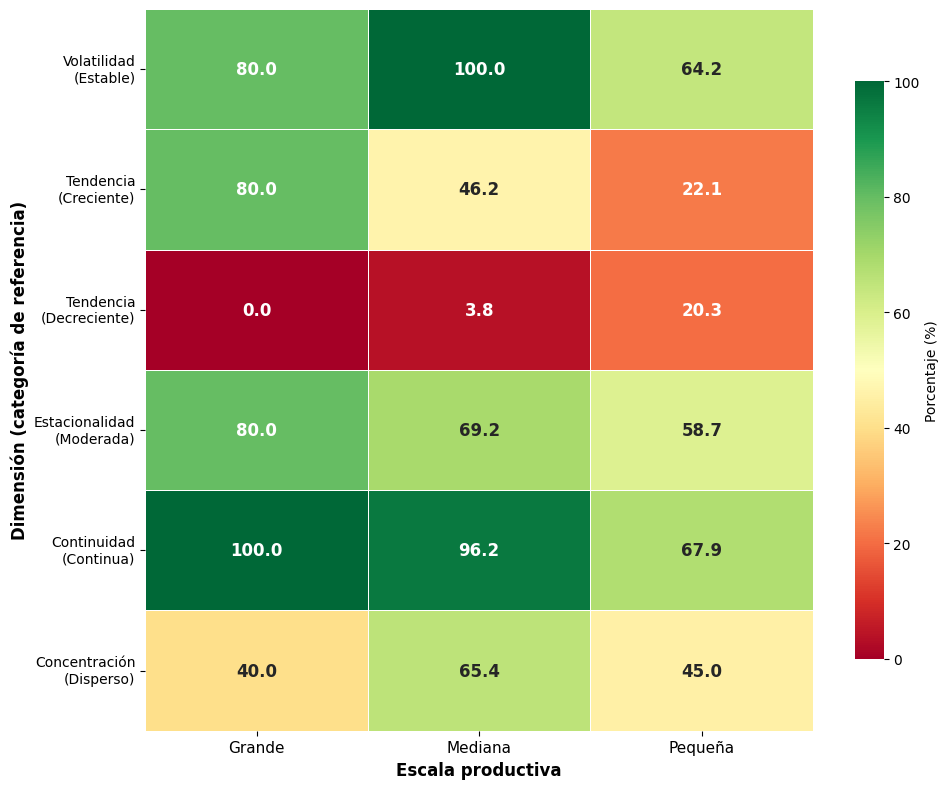

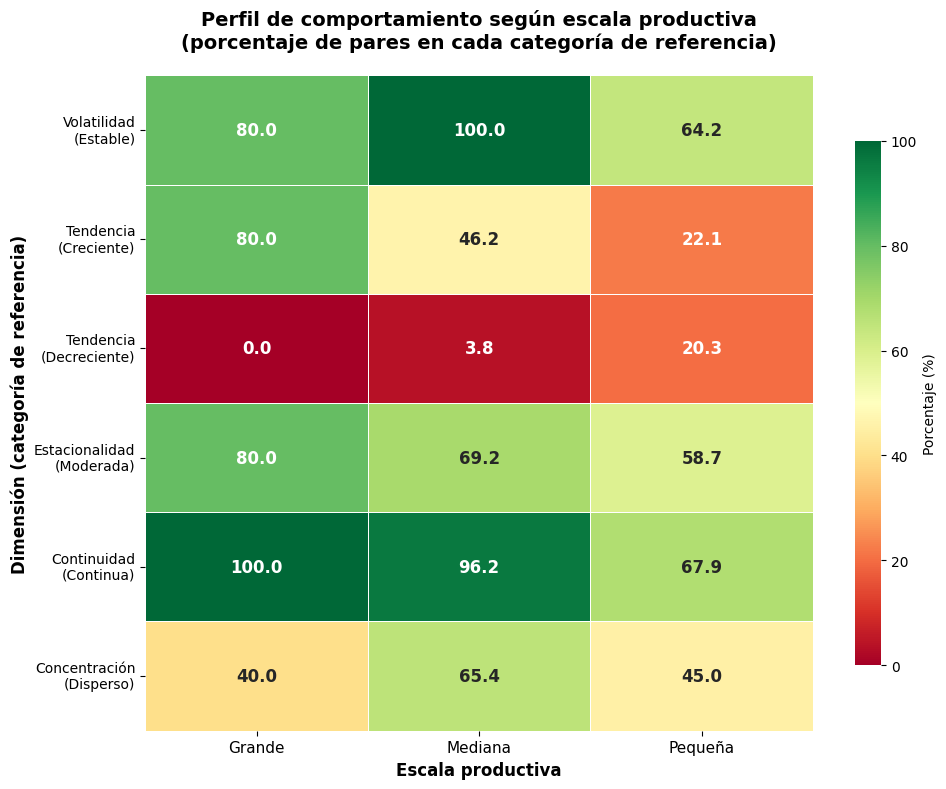

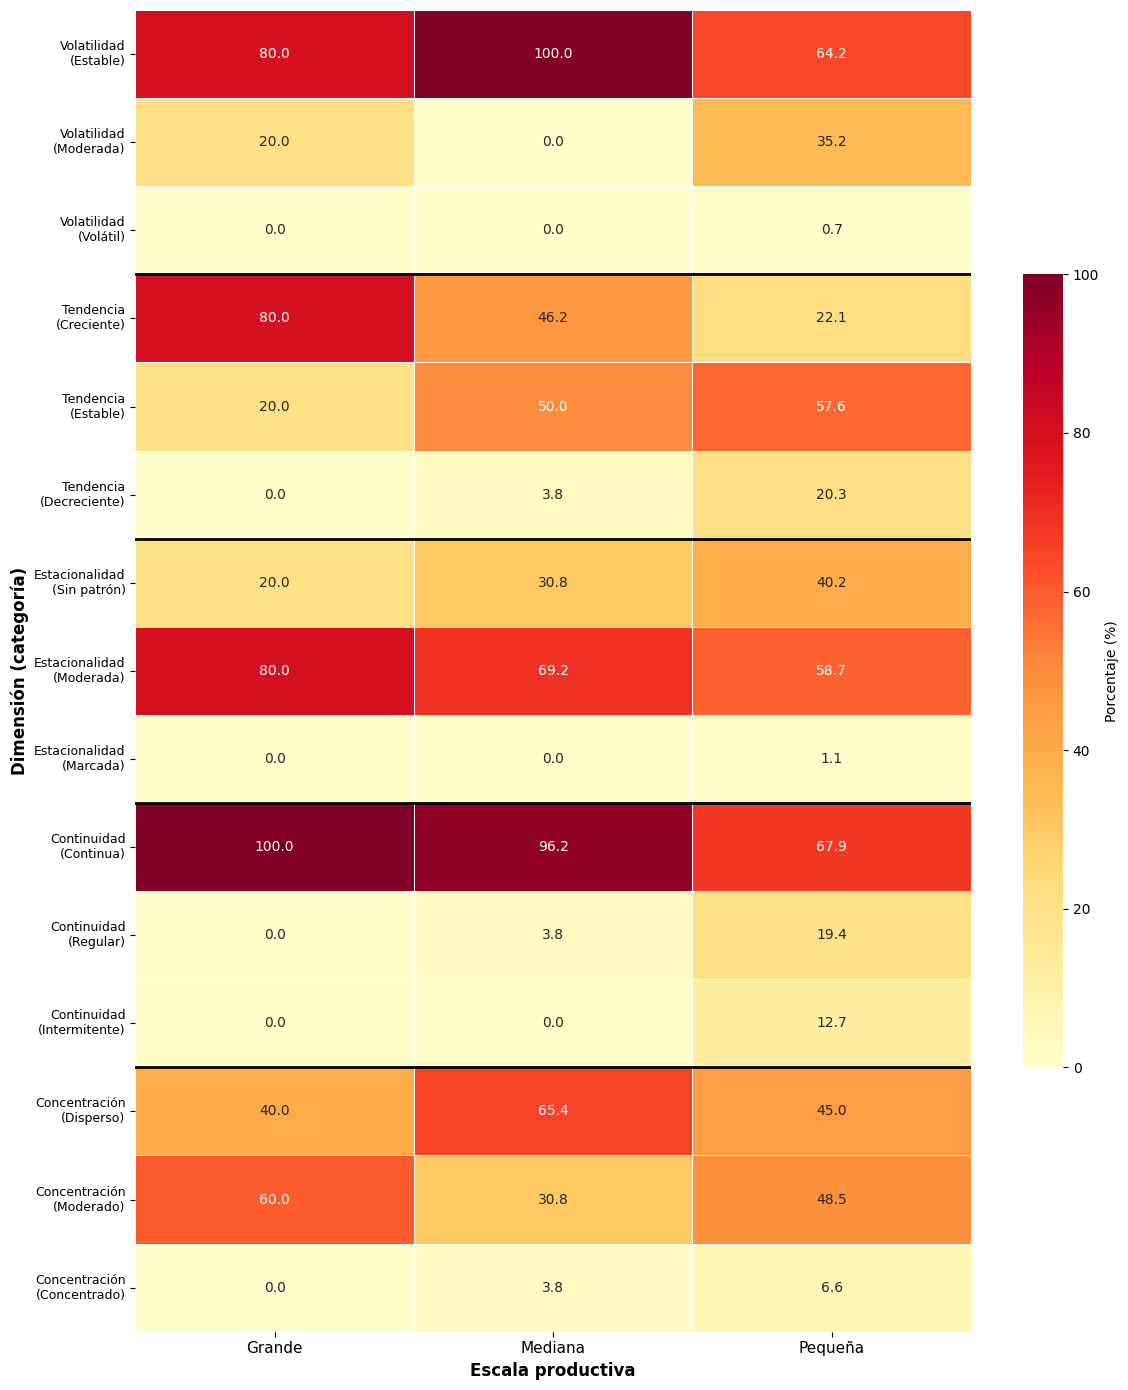

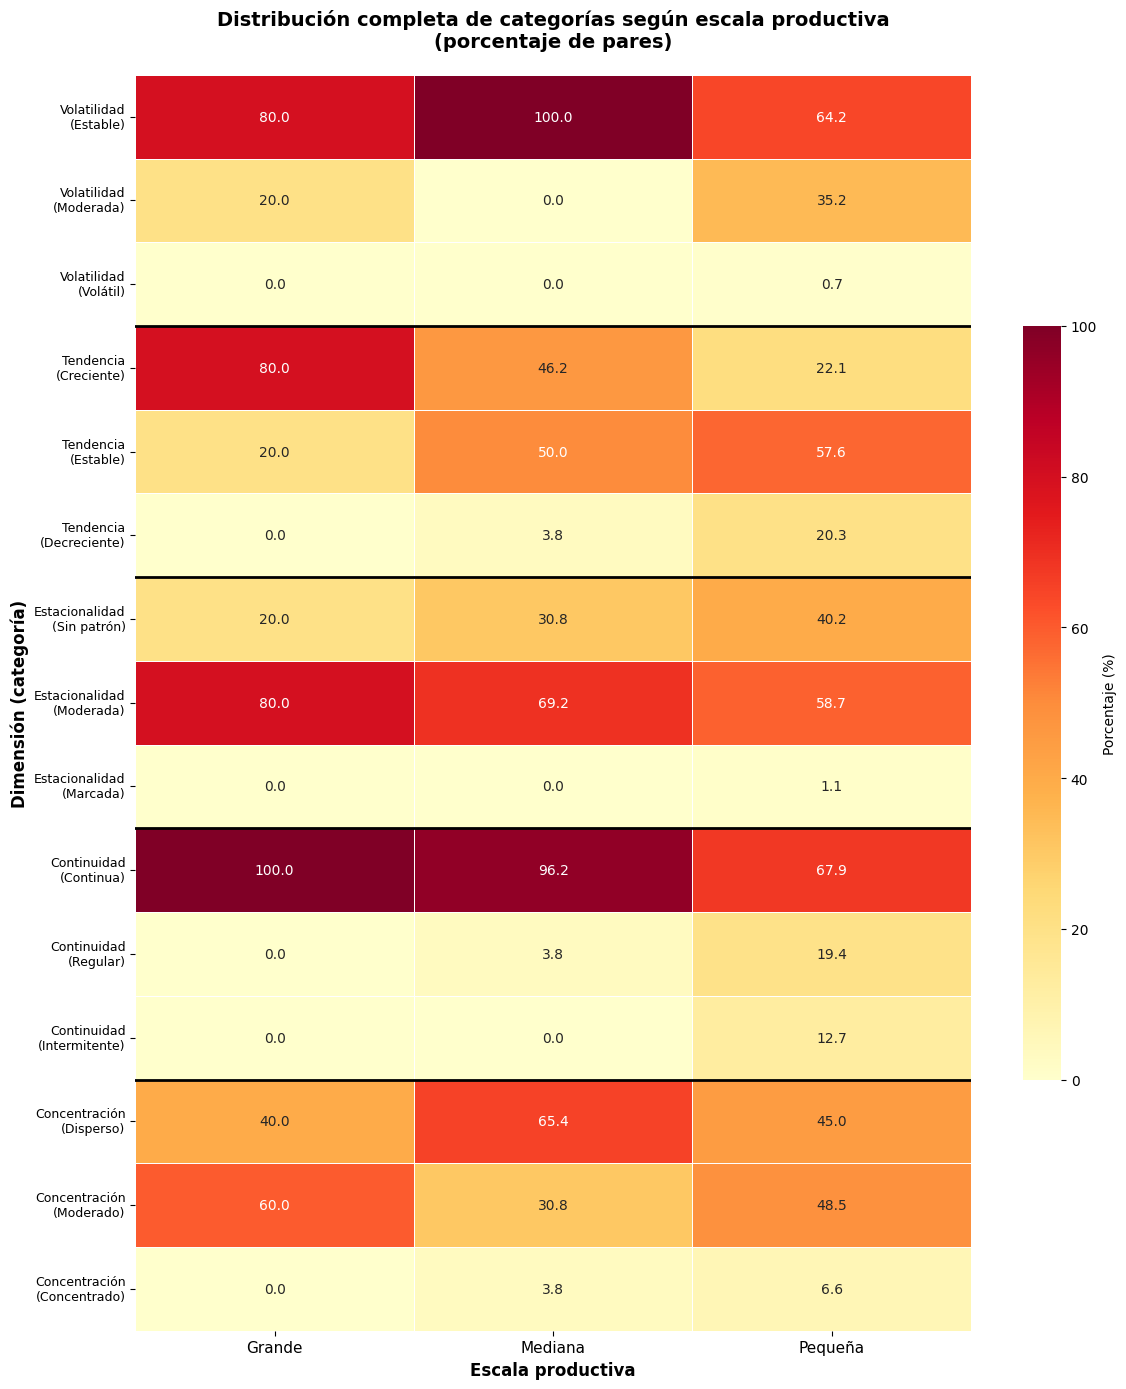

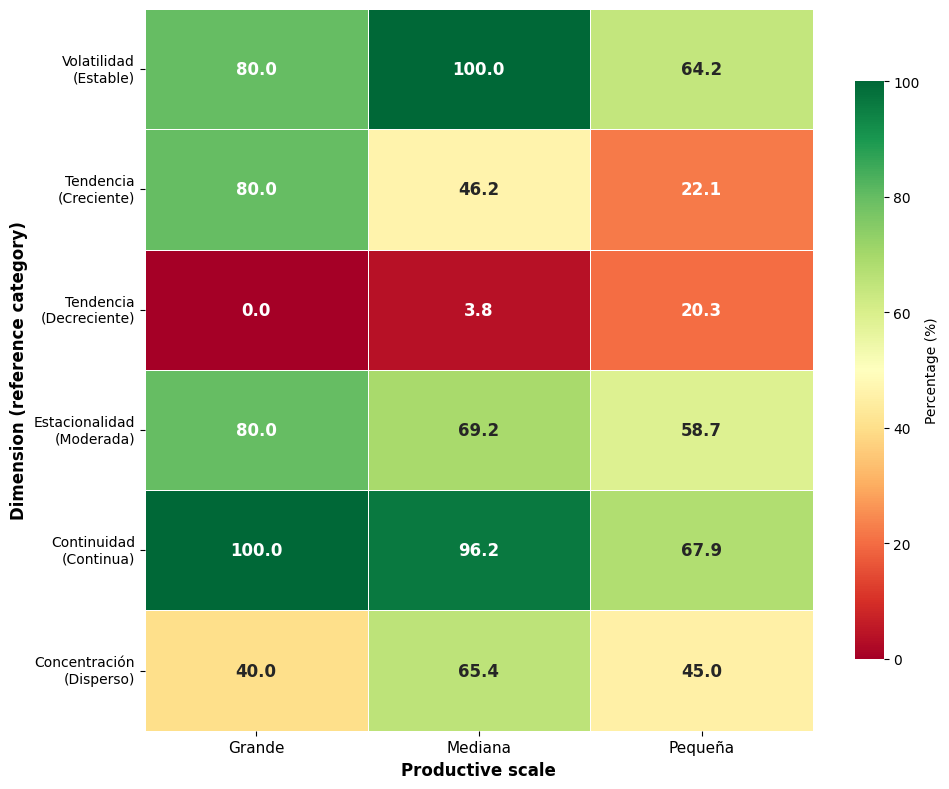

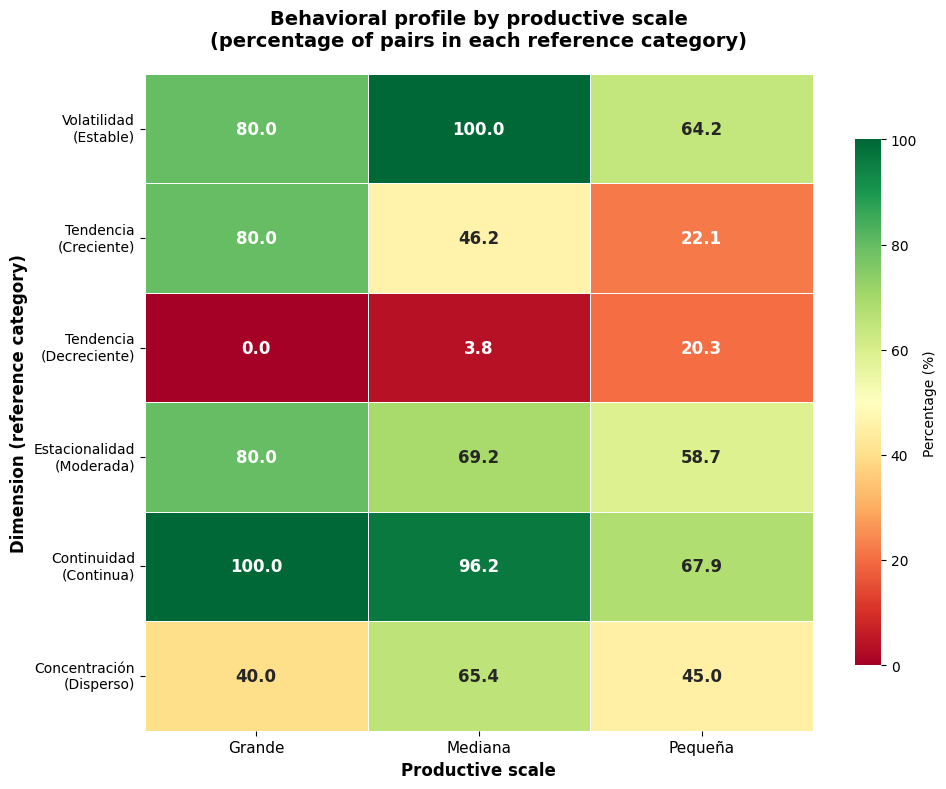

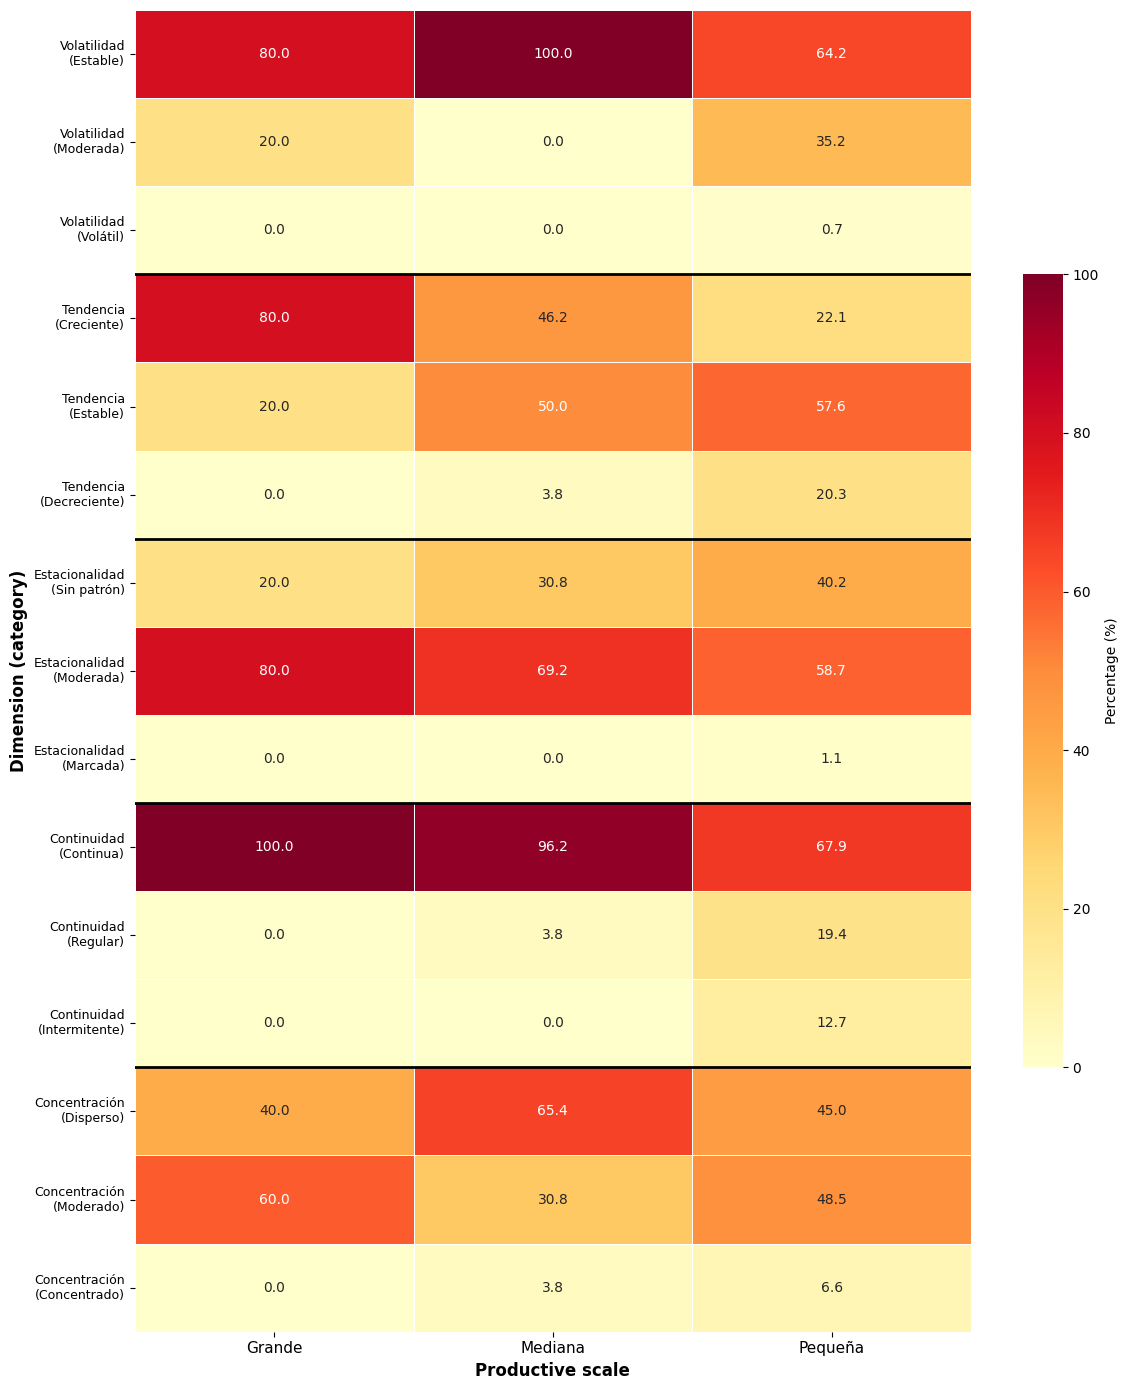

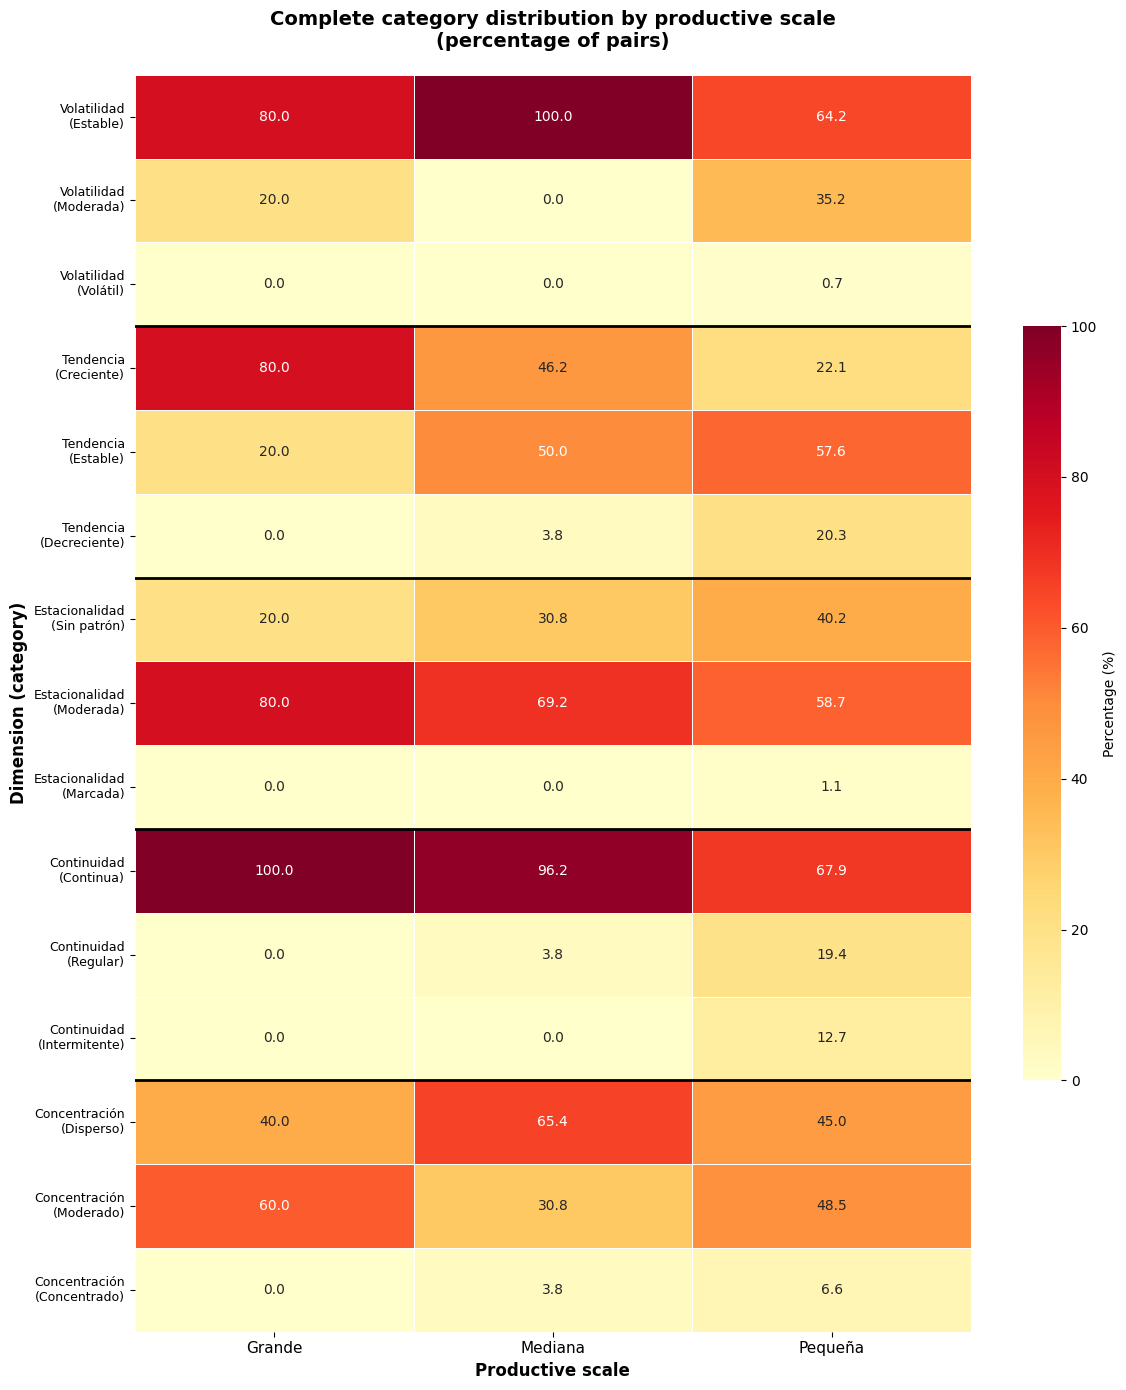

✓ 8 figuras guardadas en 'figures_clustering/'
  perfil_escala_heatmap_referencia_es.pdf / perfil_escala_heatmap_referencia_title_es.pdf
  perfil_escala_heatmap_completo_en.pdf / perfil_escala_heatmap_completo_title_en.pdf  ...


In [53]:
# ==============================================================================
# HEATMAP INTEGRADORA - PERFILES POR ESCALA PRODUCTIVA
# ==============================================================================

import pandas as pd
import numpy as np
import seaborn as sns

# ── Datos ─────────────────────────────────────────────────────────────────────
col_mapping = {
    'Volatilidad':    'volatilidad',
    'Tendencia':      'tendencia',
    'Estacionalidad': 'estacionalidad',
    'Continuidad':    'continuidad',
    'Concentración':  'concentracion',
}

dimensiones_cats = {
    'Volatilidad':    ['Estable', 'Moderada', 'Volátil'],
    'Tendencia':      ['Creciente', 'Estable', 'Decreciente'],
    'Estacionalidad': ['Sin patrón', 'Moderada', 'Marcada'],
    'Continuidad':    ['Continua', 'Regular', 'Intermitente'],
    'Concentración':  ['Disperso', 'Moderado', 'Concentrado'],
}

escalas = ['Grande', 'Mediana', 'Pequeña']

# ── Heatmap 1: categorías de referencia ──────────────────────────────────────
cats_ref = {
    'Volatilidad':    'Estable',
    'Tendencia_C':    ('Tendencia',    'Creciente'),
    'Tendencia_D':    ('Tendencia',    'Decreciente'),
    'Estacionalidad': 'Moderada',
    'Continuidad':    'Continua',
    'Concentración':  'Disperso',
}

perfiles_data = []
for escala in escalas:
    grupo = df_analisis[df_analisis['escala_productiva'] == escala]
    for dim, cat in [
        ('Volatilidad',          'Estable'),
        ('Tendencia',            'Creciente'),
        ('Tendencia',            'Decreciente'),
        ('Estacionalidad',       'Moderada'),
        ('Continuidad',          'Continua'),
        ('Concentración',        'Disperso'),
    ]:
        col = col_mapping[dim]
        pct = (grupo[col] == cat).sum() / len(grupo) * 100
        perfiles_data.append({
            'Escala': escala,
            'Dimensión': f"{dim}\n({cat})",
            'Porcentaje': pct,
        })

df_perfiles = pd.DataFrame(perfiles_data)
heatmap_ref = df_perfiles.pivot(
    index='Dimensión', columns='Escala', values='Porcentaje')[escalas]

orden_ref = [
    'Volatilidad\n(Estable)', 'Tendencia\n(Creciente)',
    'Tendencia\n(Decreciente)', 'Estacionalidad\n(Moderada)',
    'Continuidad\n(Continua)', 'Concentración\n(Disperso)',
]
heatmap_ref = heatmap_ref.reindex(orden_ref)

# ── Heatmap 2: todas las categorías ──────────────────────────────────────────
perfiles_completo = []
for dim, cats in dimensiones_cats.items():
    col = col_mapping[dim]
    for cat in cats:
        for escala in escalas:
            grupo = df_analisis[df_analisis['escala_productiva'] == escala]
            pct   = (grupo[col] == cat).sum() / len(grupo) * 100
            perfiles_completo.append({
                'Dimensión': f"{dim}\n({cat})",
                'Escala':    escala,
                'Porcentaje': pct,
            })

df_completo    = pd.DataFrame(perfiles_completo)
heatmap_compl  = df_completo.pivot(
    index='Dimensión', columns='Escala', values='Porcentaje')[escalas]
orden_compl    = [f"{dim}\n({cat})"
                  for dim, cats in dimensiones_cats.items() for cat in cats]
heatmap_compl  = heatmap_compl.reindex(orden_compl)

# ── Resumen en consola ────────────────────────────────────────────────────────
print("HEATMAP INTEGRADORA - PERFILES POR ESCALA PRODUCTIVA")
print("=" * 80)
print("\nTabla de categorías de referencia:")
print(heatmap_ref.round(1))
print("\n\nDistribución por escala productiva:")
print(df_analisis['escala_productiva'].value_counts().sort_index())
print("\n\nCaracterísticas predominantes por escala:")
print("-" * 80)
for escala in escalas:
    grupo = df_analisis[df_analisis['escala_productiva'] == escala]
    print(f"\n{escala.upper()} (n={len(grupo)}):")
    for dim, col in col_mapping.items():
        moda     = grupo[col].mode()[0]
        pct_moda = (grupo[col] == moda).sum() / len(grupo) * 100
        print(f"  {dim}: {moda} ({pct_moda:.1f}%)")

# ── Variantes de texto ────────────────────────────────────────────────────────
LABELS_REF = {
    'es': {
        'xlabel':   'Escala productiva',
        'ylabel':   'Dimensión (categoría de referencia)',
        'cbar':     'Porcentaje (%)',
        'title':    'Perfil de comportamiento según escala productiva\n'
                    '(porcentaje de pares en cada categoría de referencia)',
    },
    'en': {
        'xlabel':   'Productive scale',
        'ylabel':   'Dimension (reference category)',
        'cbar':     'Percentage (%)',
        'title':    'Behavioral profile by productive scale\n'
                    '(percentage of pairs in each reference category)',
    },
}

LABELS_COMPL = {
    'es': {
        'xlabel':   'Escala productiva',
        'ylabel':   'Dimensión (categoría)',
        'cbar':     'Porcentaje (%)',
        'title':    'Distribución completa de categorías según escala productiva\n'
                    '(porcentaje de pares)',
    },
    'en': {
        'xlabel':   'Productive scale',
        'ylabel':   'Dimension (category)',
        'cbar':     'Percentage (%)',
        'title':    'Complete category distribution by productive scale\n'
                    '(percentage of pairs)',
    },
}

BASE_REF   = "perfil_escala_heatmap_referencia"
BASE_COMPL = "perfil_escala_heatmap_completo"

# ── Función heatmap de referencia ─────────────────────────────────────────────
def plot_heatmap_ref(xlabel, ylabel, cbar, title=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(heatmap_ref, annot=True, fmt='.1f', cmap='RdYlGn',
                center=50, vmin=0, vmax=100,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': cbar, 'shrink': 0.8},
                annot_kws={'size': 12, 'weight': 'bold'}, ax=ax)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()

# ── Función heatmap completo ──────────────────────────────────────────────────
def plot_heatmap_compl(xlabel, ylabel, cbar, title=None):
    fig, ax = plt.subplots(figsize=(12, 14))
    sns.heatmap(heatmap_compl, annot=True, fmt='.1f', cmap='YlOrRd',
                vmin=0, vmax=100,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': cbar, 'shrink': 0.6},
                annot_kws={'size': 10}, ax=ax)
    for i in range(1, 5):
        ax.axhline(y=i*3, color='black', linewidth=2)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=11)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9, rotation=0)
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()

# ── Generar las 8 figuras (2 heatmaps × 2 idiomas × 2 variantes) ─────────────
total = 0
for lang in ['es', 'en']:
    lr = LABELS_REF[lang]
    lc = LABELS_COMPL[lang]

    plot_heatmap_ref(lr['xlabel'], lr['ylabel'], lr['cbar'])
    save_fig(f"{BASE_REF}_{lang}")
    plt.show()

    plot_heatmap_ref(lr['xlabel'], lr['ylabel'], lr['cbar'], title=lr['title'])
    save_fig(f"{BASE_REF}_title_{lang}")
    plt.show()

    plot_heatmap_compl(lc['xlabel'], lc['ylabel'], lc['cbar'])
    save_fig(f"{BASE_COMPL}_{lang}")
    plt.show()

    plot_heatmap_compl(lc['xlabel'], lc['ylabel'], lc['cbar'], title=lc['title'])
    save_fig(f"{BASE_COMPL}_title_{lang}")
    plt.show()

    total += 4

print(f"✓ {total} figuras guardadas en '{OUT_DIR}/'")
print(f"  {BASE_REF}_es.pdf / {BASE_REF}_title_es.pdf")
print(f"  {BASE_COMPL}_en.pdf / {BASE_COMPL}_title_en.pdf  ...")